In [3]:
# !pip install requests pandas beautifulsoup4 lxml html5lib matplotlib seaborn plotly numpy python-dotenv ydata-profiling scipy statsmodels

# Аналитика ДТП


## Описание


**Заказчик:** Проект «Карта ДТП» (https://dtp-stat.ru/)

**Цель проекта:** Проведение глубокого анализа данных о дорожно-транспортных происшествиях

**Описание проекта**

**Задачи проекта:**
* Исследовательский анализ данных о ДТП за 2025 год
* Формулировка и проверка не менее трех гипотез
* Анализ всех доступных датасетов
* Разработка дашборда для публикации результатов

**Возможные гипотезы для проверки**

* Влияние нетрезвых водителей на аварийность
* Тенденции роста безопасности дорожного движения
* Сравнение безопасности личного транспорта и общественного
* Влияние нарушений пешеходов на травматизм
* Связь скорости движения с тяжестью последствий ДТП

**Данные для анализа**

- **Формат данных:** GeoJSON 
- **Источник:** https://dtp-stat.ru/opendata 
- **Особенности:** Отдельный файл для каждого субъекта РФ

**Этапы выполнения**

**Подготовка данных**
* Загрузка данных с помощью geopandas/json
* Выбор регионов для анализа
* Первичная обработка

**Исследовательский анализ**
* Предобработка данных
* Визуализация
* Корреляционный анализ
* Проверка гипотез

**Визуализация и выводы**
* Создание информативных графиков
* Формулировка выводов
* Подготовка материалов для публикации

**Требования к визуализации**

* Лаконичность и информативность
* Возможность использования в социальных сетях
* Стиль: минимализм
* Четкие подписи
* Отсутствие визуального шума

**Результаты проекта**

**Обязательные deliverables:**
* Jupyter Notebook (или ссылка на Colab)
* Рабочий дашборд с публичным доступом

**Технологический стек**

**Основные инструменты:**
* Geopandas
* Pandas
* Json
* Seaborn
* Plotly
* Matplotlib

**Дополнительные:**
* Библиотеки для работы с большими данными
* BI-инструменты для дашбордов

**Рекомендации**

* Использовать оптимизацию памяти при работе с большими наборами данных
* Применять векторизованные операции вместо циклов
* Оптимизировать запросы к данным
* Документировать все этапы обработки

**Полезные материалы**

* Handling Large Datasets in Pandas(https://www.vantage-ai.com/en/blog/4-strategies-how-to-deal-with-large-datasets-in-pandas)
* Оптимизация памяти в Pandas(https://habr.com/ru/articles/708468/)

**Выполнил:** Дмитрий Федотов.\
[Телеграм](https:t.me/nick4chat)

### Импорт модулей

In [4]:
import os
import requests
import hashlib
import zipfile
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import gc
import numpy as np
import dotenv
import json
from ydata_profiling import ProfileReport
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint
import textwrap
import io

### Глобальные настройки

In [5]:
# устанавливаем, что все столбцы должны отображаться - None - без ограничений
pd.set_option('display.max_columns', None)
# Ограничение количества знаков после запятой
pd.set_option('display.float_format', '{:.2f}'.format)
# устанавливаем ширину отображения
pd.set_option('display.width', None)
# Установите максимальную ширину отображения столбцов
pd.set_option('display.max_colwidth', None)
# Устанавливаем глобальный стиль для графиков
sns.set_theme(style='whitegrid', palette='muted')
# Ограничение предупреждений о FutureWarning
# warnings.filterwarnings("ignore", category=FutureWarning)
# Отключаем предупреждения DeprecationWarning, чтобы не засоряли вывод.
# Это временно скрывает уведомления о возможных изменениях поведения функций в будущих версиях Pandas.
# Важно: такие предупреждения лучше не игнорировать в финальном коде, а устранять причины их появления.
# warnings.filterwarnings('ignore', category=DeprecationWarning)

### Функции

In [6]:
def pass_value_barh(dfg, figsize=(15, 6)):
    """
    Создаёт горизонтальную столбчатую диаграмму, отображающую процент пропущенных значений в столбцах DataFrame.

    Параметры:
    -----------
    dfg : pandas.DataFrame
        Входной DataFrame для анализа пропущенных значений.
    figsize : tuple, optional (default=(15, 6))
        Размер фигуры для диаграммы (ширина, высота) в дюймах.

    Возвращает:
    -----------
    None
        Отображает горизонтальную столбчатую диаграмму, если есть столбцы с пропусками, иначе выводит сообщение.

    Примеры:
    ---------
    >>> import pandas as pd
    >>> df = pd.DataFrame({'A': [1, None, 3], 'B': [None, 5, None], 'C': [7, 8, 9]})
    >>> pass_value_barh(df)
    [Отображает диаграмму с процентами пропусков для столбцов 'A' и 'B']

    >>> df_no_missing = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 5, 6]})
    >>> pass_value_barh(df_no_missing)
    пропусков не осталось :)

    Примечания:
    -----------
    - Вычисляет процент пропущенных значений по столбцам с помощью `isna().mean() * 100`.
    - Фильтрует столбцы с ненулевыми пропусками для построения диаграммы.
    - Сортирует значения по возрастанию для лучшей визуализации.
    - Использует matplotlib для создания горизонтальной столбчатой диаграммы с сеткой и настроенными подписями.
    - Если пропуски отсутствуют, выводит сообщение вместо диаграммы.
    - Обрабатывает исключения и выводит сообщение об ошибке при сбое функции.
    """
    try:
        result = (dfg.isna().mean() * 100).to_frame().rename(columns={0: 'space'}).query('space > 0')
        if not result.empty:
            result.sort_values(by='space', ascending=True).plot(
                kind='barh',
                figsize=figsize,
                legend=False,
                fontsize=14,
                grid=True,
                xlim=(0, 100)
            )
            plt.title('Пропущенные значения, %\n', fontsize=16)
            plt.xlabel('Процент пропусков', fontsize=16)
            plt.ylabel('Столбцы с пропусками', fontsize=16)
            plt.show()
        else:
            print('пропусков не осталось :)')
    except Exception as e:
        print(f'Произошла ошибка в первой части функции: {e}')

In [7]:
def file_hash(path):
    """Вычисляем SHA256 хэш файла"""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

In [8]:
def load_dtp_data(download_dir = "download",
                  url = "https://dtp-stat.ru/opendata",
                  download_data = True,
                  regions = None):
    """
    Загружает данные о ДТП из geojson.zip файлов с сайта или локальной папки.
    Поддерживает проверку SHA256-хэшей: если локальный файл совпадает с удалённым,
    скачивание пропускается; если хэши различаются — файл перекачивается.

    Параметры:
        download_dir (str): Папка для сохранения файлов (по умолчанию "download").
        url (str): URL сайта с данными (по умолчанию "https://dtp-stat.ru/opendata").
        download_data (bool): Скачивать файлы из интернета или использовать локальные (по умолчанию True).
        regions (list[str] or None): Список регионов для фильтрации (часть имени файла, например, ['moscow']) (по умолчанию None).

    Возвращает:
        pd.DataFrame: DataFrame с данными о ДТП (столбцы: 'id', 'region', 'geometry', 'tags', etc.).
                      При ошибке возвращается пустой DataFrame.

    Raises:
        requests.RequestException: Если не удалось загрузить данные с сайта.
        zipfile.BadZipFile: Если архив повреждён.
        json.JSONDecodeError: Если geojson невалиден.

    Примеры:
        >>> # Загрузить все данные
        >>> df = load_dtp_data()
        >>> # Загрузить данные для Москвы
        >>> df = load_dtp_data(regions=['moscow'])
        >>> # Использовать только локальные файлы
        >>> df = load_dtp_data(download_data=False)
    """
    os.makedirs(download_dir, exist_ok=True)

    # Получаем список файлов
    if download_data:
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            soup = BeautifulSoup(resp.text, "html.parser")
            links = [a["href"] for a in soup.find_all("a", href=True) if a["href"].endswith(".geojson.zip")]
        except Exception as e:
            print(f"Ошибка загрузки страницы {url}: {e}")
            return pd.DataFrame()
    else:
        links = [os.path.join(download_dir, f) for f in os.listdir(download_dir) if f.endswith(".geojson.zip")]

    all_records = []
    downloaded, skipped = 0, 0

    # Скачиваем и обрабатываем
    for link in links:
        filename = os.path.basename(link)
        if regions and not any(region in filename for region in regions):
            continue
        filepath = os.path.join(download_dir, filename)

        if download_data:
            need_download = True
            if os.path.exists(filepath):
                try:
                    local_hash = file_hash(filepath)
                    resp_head = requests.get(link, timeout=30)
                    remote_hash = hashlib.sha256(resp_head.content).hexdigest()
                    if local_hash == remote_hash:
                        print(f"Файл {filename} уже актуален, пропускаем.")
                        need_download = False
                        skipped += 1
                except Exception as e:
                    print(f"Ошибка проверки хэша {filename}: {e}")

            if need_download:
                print(f"Скачиваем {filename}...")
                try:
                    r = requests.get(link, timeout=60)
                    r.raise_for_status()
                    with open(filepath, "wb") as f:
                        f.write(r.content)
                    print(f"Скачан {filename} ({len(r.content)/1024/1024:.2f} MB)")
                    downloaded += 1
                except Exception as e:
                    print(f"Ошибка скачивания {filename}: {e}")
                    continue

        # Читаем из локального архива
        try:
            with zipfile.ZipFile(filepath, "r") as z:
                geojson_file = [f for f in z.namelist() if f.endswith(".geojson")][0]
                with z.open(geojson_file) as f:
                    data = json.load(f)

            for feature in data["features"]:
                props = feature["properties"].copy()
                props["geometry"] = feature["geometry"]
                all_records.append(props)

            print(f"{filename}: {len(data['features'])} строк")
        except Exception as e:
            print(f"Ошибка обработки {filename}: {e}")

    df = pd.DataFrame(all_records)
    print(f"\nФайлов скачано: {downloaded}, пропущено (актуальные): {skipped}")
    print(f"Итого строк: {len(df)}")
    return df

In [9]:
def normalize_health_status(x):
    """
    Нормализует статус здоровья участника ДТП в категории 'F' (погиб), 'S' (тяжёлые ранения), 'M' (лёгкие ранения), 'N' (не пострадал) или 'U' (неизвестно).

    Параметры:
    -----------
    x : str or float
        Значение столбца health_status (строка или NaN).

    Возвращает:
    --------
    str
        Категория: 'F' (погиб), 'S' (стационар), 'M' (амбулаторный), 'N' (не пострадал), 'U' (неизвестно) или исходное значение, если не классифицировано.

    Примеры:
    ---------
    >>> normalize_health_status("Скончался на месте ДТП")
    'F'
    >>> normalize_health_status("Раненый, находящийся на стационарном лечении")
    'S'
    >>> normalize_health_status("Раненый, находящийся на амбулаторном лечении")
    'M'
    >>> normalize_health_status("Получил травмы с оказанием разовой медицинской помощи, к категории раненый не относится")
    'N'
    >>> normalize_health_status(None)
    'U'

    Notes:
    ------
    - NaN обрабатывается как 'U' (неизвестно).
    - Случаи с 'к категории раненый не относится' классифицируются как 'N' (не пострадал).
    - 'Раненый' делится на 'S' (стационар) и 'M' (амбулаторный) по ключевым словам.
    - Неклассифицированные случаи возвращают исходное значение для доработки.
    """
    if pd.isna(x):
        return "U"

    x = str(x)

    # Не пострадал
    if "Не пострадал" in x:
        return "N"

    # Исключения: явно сказано "к категории раненый не относится"
    if "к категории раненый не относится" in x:
        return "N"

    # Погиб
    if "Скончался" in x:
        return "F"

    # Стационар (НО только если нет слова "дневн")
    if "стационар" in x and "дневн" not in x:
        return "S"

    # Амбулатор или дневной стационар
    if "амбулатор" in x or "дневн" in x:
        return "M"

    # Травмы / повреждения → M
    if "травм" in x or "повреждения" in x:
        return "M"

    # Неклассифицированные случаи возвращают исходное значение
    return x

In [10]:
def normalize_category(val):
    """
    Нормализует категории транспортных средств (ТС) в укрупнённые классы.

    Параметры:
        val (str): Входная строка с категорией ТС.

    Возвращает:
        str: Укрупнённая категория ТС (B, A, M, V, C, D, Tm, S, X, R, Z, U).

    Категории:
    - B  = легковые автомобили
    - A  = мотоциклы, мопеды, квадроциклы
    - M  = мопеды до 50 куб.см
    - V  = велосипеды, персональные электрические средства
    - C  = грузовые автомобили
    - D  = автобусы, троллейбусы
    - Tm = трамваи
    - S  = спецтехника, трактора
    - X  = спецслужбы - 101-104
    - R  = ж/д
    - Z = военная техника
    - U  = неизвестно
    """
    # Проверка на пустое значение, возвращает "U" для неизвестной категории
    if pd.isna(val):
        return "U"
    
    # Приведение строки к нижнему регистру и удаление пробелов
    x = str(val).lower().strip()
    
    # Легковые автомобили (класс B)
    if any(k in x for k in ["класс", "универсал", "минивэн", "спортив", "прочие легк"]):
        return "B"
    
    # Мотоциклы, квадроциклы, снегоходы (класс A)
    if any(k in x for k in ["мото", "квадро", "трицикл", "снегоход", "более 50 с", "квадри"]):
        return "A"
    
    # Мопеды до 50 куб.см или с электродвигателем до 4 кВт (класс M)
    if ("мопед" in x and "менее 50" in x) or 'с электродвигателем менее 4 квт' in x:
        return "M"
    
    # Велосипеды и персональные электрические средства (класс V)
    if "велосипед" in x or "электрическое средство" in x:
        return "V"
    
    # Грузовые автомобили (класс C)
    if any(k in x for k in ["груз", "тягач", "фургон", "самосвал", "рефриж", "цистерн", "автобетоно", "автоцемент", "лесовоз", "для перевозки"]):
        return "C"
    
    # Автобусы, троллейбусы (класс D)
    if any(k in x for k in ["автобус", "троллейбус", "электробус", "этажн", "ярусн"]):
        return "D"
    
    # Трамваи (класс Tm)
    if "трамва" in x:
        return "Tm"
    
    # Спецтехника (класс S)
    if any(k in x for k in ["трактор", "экскаватор", "погруз", "кран", "бульдозер", "грейдер", "спецтех", "дорожн", "коммуналь", "сельскохоз", "самоходные машины", "снегоубор", "шасси", "подъемниками с", "для обслуживания нефт"]):
        return "S"
    
    # Спецслужбы (класс X)
    if any(k in x for k in ["пожарн", "скорой", "эвакуатор", "полици", "мвд", "спасатель", "медицинский комплекс", "оперативно-служебн", "медиц"]):
        return "X"
    
    # Железнодорожный транспорт (класс R)
    if "ж/д" in x or "подвижной состав" in x:
        return "R"
    
    # Военная техника (класс Z)
    if any(k in x for k in ["воен", "боев"]):
        return "Z"
    
    # Неизвестные ТС (класс U)
    if x == "иные тс":
        return "U"
    
    # Возврат исходного значения, если не соответствует ни одной категории
    return val

In [11]:
def autolabel(rects):
    """
    Добавляет подписи с процентами к столбцам горизонтальной гистограммы (`barh`).

    Параметры:
    rects (matplotlib.container.BarContainer): Набор прямоугольников (столбцов) гистограммы,
                                              возвращаемый методом ax.barh().

    Поведение:
    - Для каждого столбца отображает значение ширины (в процентах) с одним знаком после запятой.
    - Подписи размещаются справа от столбца с небольшим отступом (3 пункта).
    - Шрифт подписей: размер 8, выравнивание по левому краю и центру по вертикали.
    """
    for rect in rects:
        width = rect.get_width()
        ax.annotate(f'{width:.1f}%',
                    xy=(width, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0),  # смещение вправо
                    textcoords="offset points",
                    ha='left', va='center', fontsize=8)

In [12]:
def shorten_violations(viol_list):
    """
    Сокращает список нарушений, заменяя полные описания на сокращенные из violations_map.
    Если сокращение отсутствует, оставляет оригинальное описание.

    Параметры:
        viol_list (list): Список строк с описаниями нарушений.

    Возвращает:
        list: Список сокращенных описаний нарушений.
    """
    return [violations_map.get(v, v) for v in viol_list]

## Загрузка и предобработка данных

### Скачивание открытых данных

Через geopandas мы теряем важную информацию по погоде, окружению, условиям дороги. Поэтому будем использовать json.

In [13]:
# Папка для скачивания
DOWNLOAD_DIR = "download"

In [14]:
try:
    df = load_dtp_data(download_dir=DOWNLOAD_DIR,
                  url="https://dtp-stat.ru/opendata",
                  download_data=False,
                  regions=None)
except Exception as e:
    print(f'Использовать функцию не получилось из-за ошибки:\n{e}\nЗагружаем с сайта напрямую в проект:')
    # URL сайта
    url = "https://dtp-stat.ru/opendata"

    # Получаем ссылки на *.geojson.zip
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
    except Exception as e:
        print(f"Ошибка при загрузке страницы: {e}")
        exit(1)

    soup = BeautifulSoup(response.text, "html.parser")
    links = [a["href"] for a in soup.find_all("a", href=True) if a["href"].endswith(".geojson.zip")]
    print(f"Найдено файлов: {len(links)}")

    all_records = []
    downloaded = 0

    # Скачиваем и обрабатываем архивы
    for link in links:
        filename = os.path.basename(link)
        try:
            # Скачиваем архив в память
            file_resp = requests.get(link, timeout=60)
            file_resp.raise_for_status()
            
            # Читаем архив без сохранения на диск
            with zipfile.ZipFile(io.BytesIO(file_resp.content)) as z:
                # Предполагаем, что в архиве один *.geojson файл
                geojson_file = [f for f in z.namelist() if f.endswith(".geojson")][0]
                with z.open(geojson_file) as f:
                    data = json.load(f)
            
            # Обрабатываем данные
            accidents = data["features"]
            records = []
            for feature in accidents:
                props = feature["properties"].copy()
                props["geometry"] = feature["geometry"]
                records.append(props)
            
            all_records.extend(records)
            print(f"Загружено {len(records)} строк из {filename}")
            downloaded += 1
        except Exception as e:
            print(f"Ошибка при обработке {filename}: {e}")

    # Объединяем в DataFrame
    df = pd.DataFrame(all_records)
    print(f"Итого строк во всех файлах: {len(df)}")

amurskaia-oblast.geojson.zip: 12404 строк
arkhangelskaia-oblast.geojson.zip: 12534 строк
astrakhanskaia-oblast.geojson.zip: 11961 строк
belgorodskaia-oblast.geojson.zip: 12751 строк
brianskaia-oblast.geojson.zip: 9899 строк
chechenskaia-respublika.geojson.zip: 2589 строк
cheliabinskaia-oblast.geojson.zip: 41694 строк
chukotskii-avtonomnyi-okrug.geojson.zip: 226 строк
chuvashskaia-respublika-chuvashiia.geojson.zip: 12186 строк
evreiskaia-avtonomnaia-oblast.geojson.zip: 2282 строк
iamalo-nenetskii-avtonomnyi-okrug.geojson.zip: 4274 строк
iaroslavskaia-oblast.geojson.zip: 17675 строк
irkutskaia-oblast.geojson.zip: 29982 строк
ivanovskaia-oblast.geojson.zip: 12613 строк
kabardino-balkarskaia-respublika.geojson.zip: 6748 строк
kaliningradskaia-oblast.geojson.zip: 11534 строк
kaluzhskaia-oblast.geojson.zip: 14745 строк
kamchatskii-krai.geojson.zip: 4827 строк
karachaevo-cherkesskaia-respublika.geojson.zip: 4997 строк
kemerovskaia-oblast-kuzbass.geojson.zip: 28245 строк
khabarovskii-krai.geoj

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465882 entries, 0 to 1465881
Data columns (total 21 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   id                      1465882 non-null  int64 
 1   tags                    1465882 non-null  object
 2   light                   1465882 non-null  object
 3   point                   1465882 non-null  object
 4   nearby                  1465882 non-null  object
 5   region                  1465882 non-null  object
 6   scheme                  1386812 non-null  object
 7   address                 1389322 non-null  object
 8   weather                 1465882 non-null  object
 9   category                1465882 non-null  object
 10  datetime                1465882 non-null  object
 11  severity                1465882 non-null  object
 12  vehicles                1465882 non-null  object
 13  dead_count              1465882 non-null  int64 
 14  participants      

Так как у нас получился огромный файл, а в целях нашего исследования нам нужен только 2025 год, отфильтруем данные.

In [16]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

In [17]:
before = df.shape[0]
analysis_year = 2025
df = df.loc[df['datetime'].dt.year == analysis_year].reset_index(drop=True)
after = df.shape[0]
print(f'Было {before} строк. \nСтало {after}. Мы сохранили {(after/before):.2%} данных\n')
df.info()

Было 1465882 строк. 
Стало 51734. Мы сохранили 3.53% данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51734 entries, 0 to 51733
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      51734 non-null  int64         
 1   tags                    51734 non-null  object        
 2   light                   51734 non-null  object        
 3   point                   51734 non-null  object        
 4   nearby                  51734 non-null  object        
 5   region                  51734 non-null  object        
 6   scheme                  49357 non-null  object        
 7   address                 47520 non-null  object        
 8   weather                 51734 non-null  object        
 9   category                51734 non-null  object        
 10  datetime                51734 non-null  datetime64[ns]
 11  severity                51734 non-null  objec

In [18]:
# df['tags'].value_counts()

Тэг всегда один, можем удалить столбец

Для работы с комбинациями сохраним столбец в строковом типе

In [19]:
df['weather_str'] = df['weather'].apply(lambda x: ', '.join(x))
df['participant_categories_str'] = df['participant_categories'].apply(lambda x: ', '.join(x))

### Point

Для Datalens координаты точки нужны в формате [широта, долгота] - исправим.

In [20]:
# Сначала превращаем строку в dict
df['point'] = df['point'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
# Потом превращаем dict в список [lat, lon]
df['point'] = df['point'].apply(lambda x: [x['lat'], x['long']] if isinstance(x, dict) else x)

### Участиники ДТП

In [21]:
# посмотрим, что за данные в столбце vehicles
df['vehicles'][2]

[{'year': 2021,
  'brand': 'VOLVO',
  'color': 'Серый',
  'model': 'FH',
  'category': 'Седельные тягачи',
  'participants': [{'role': 'Водитель',
    'gender': 'Мужской',
    'violations': ['Нарушение правил расположения ТС на проезжей части'],
    'health_status': 'Не пострадал',
    'years_of_driving_experience': 17}]}]

In [22]:
df['participants'][2]

[{'role': 'Работник дорожной организации, осуществляющий работы на проезжей части (обочине и т.д.)',
  'gender': 'Мужской',
  'violations': [],
  'health_status': 'Получил телесные повреждения с показанием к лечению в медицинских организациях (кроме разовой медицинской помощи)'}]

Мы видим, что в столбцах находятся словари. Разделим инциденты, машины, участников, что рядом и дорожные условия на 4 отдельных датасетов.
Погоду и категории участников можем удалить, у нас они есть в строковом виде.

In [23]:
# -------------------------------
df = df.rename(columns={'id': 'accident_id'})

# Основная таблица (accidents)
accidents_cols = [col for col in df.columns if col not in ['tags', 'participants', 'vehicles', 'weather', 'nearby', 'road_conditions', 'participant_categories']]
accidents = df[accidents_cols].copy()

# -------------------------------
# Таблица vehicles
df_veh = df.explode('vehicles').reset_index(drop=True)
df_veh['vehicle_id'] = range(len(df_veh))

vehicles = pd.json_normalize(df_veh['vehicles'])
vehicles['accident_id'] = df_veh['accident_id']
vehicles['vehicle_id'] = df_veh['vehicle_id']
vehicles['datetime'] = df_veh['datetime']

# убираем вложенных участников — они пойдут в participants
if 'participants' in vehicles.columns:
    vehicles = vehicles.drop(columns=['participants'])

# -------------------------------
# Таблица participants (все участники: в транспорте + без транспорта)
# участники внутри машин
df_veh['vehicle_participants'] = df_veh['vehicles'].apply(
    lambda x: x.get('participants', []) if isinstance(x, dict) else []
)
vehicle_participants = df_veh.explode('vehicle_participants').reset_index(drop=True)
vehicle_participants_df = pd.json_normalize(vehicle_participants['vehicle_participants'])
vehicle_participants_df['accident_id'] = vehicle_participants['accident_id']
vehicle_participants_df['vehicle_id'] = vehicle_participants['vehicle_id']

# участники без транспорта
df['participants'] = df['participants'].apply(lambda x: x if isinstance(x, list) else [])
accident_participants = df.explode('participants').reset_index(drop=True)
accident_participants_df = pd.json_normalize(accident_participants['participants'])
accident_participants_df['accident_id'] = accident_participants['accident_id']
accident_participants_df['vehicle_id'] = None

# объединяем
participants = pd.concat([vehicle_participants_df, accident_participants_df], ignore_index=True)

# чистим пустые строки (если все значения по участнику NaN)
participants = participants.dropna(
    subset=['role', 'gender', 'violations', 'health_status', 'years_of_driving_experience'],
    how='all'
).copy()

# -------------------------------
# Таблица weather
# weather = df[['accident_id', 'weather']].explode('weather').dropna().copy()

# -------------------------------
# Таблица nearby
nearby = df[['accident_id', 'nearby']].explode('nearby').dropna().copy()

# -------------------------------
# Таблица road_conditions
road_conditions = df[['accident_id', 'road_conditions']].explode('road_conditions').dropna().copy()

# -------------------------------
# Таблица participant_categories
# participant_categories = df[['accident_id', 'participant_categories']].explode('participant_categories').dropna().copy()

# Результаты
print("Accidents:", accidents.shape)
print("Vehicles:", vehicles.shape)
print("Participants:", participants.shape)
# print("Weather:", weather.shape)
print("Nearby:", nearby.shape)
print("Road conditions:", road_conditions.shape)
# print("Participant categories:", participant_categories.shape)

Accidents: (51734, 16)
Vehicles: (82896, 8)
Participants: (126610, 7)
Nearby: (101256, 2)
Road conditions: (74683, 2)


In [24]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51734 entries, 0 to 51733
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   accident_id                 51734 non-null  int64         
 1   light                       51734 non-null  object        
 2   point                       51734 non-null  object        
 3   region                      51734 non-null  object        
 4   scheme                      49357 non-null  object        
 5   address                     47520 non-null  object        
 6   category                    51734 non-null  object        
 7   datetime                    51734 non-null  datetime64[ns]
 8   severity                    51734 non-null  object        
 9   dead_count                  51734 non-null  int64         
 10  injured_count               51734 non-null  int64         
 11  parent_region               51734 non-null  object    

Происшествия:
- **id** — идентификатор аварии, `int32`;
- **light** — условия освещения, `object`;
- **point** — координаты точки, `object`;
- **region** — регион, `object`;
- **scheme** — схема ДТП, `object` (есть пропуски);
- **address** — адрес, `object` (есть пропуски);
- **category** — категория аварии, `object`;
- **datetime** — дата и время, `datetime64[ms]`;
- **severity** — степень тяжести, `object`;
- **dead_count** — число погибших, `int32`;
- **injured_count** — число пострадавших, `int32`;
- **parent_region** — укрупнённый регион, `object`;
- **participants_count** — количество участников, `int32`;
- **geometry** — геометрия (точки), `geometry` (есть несколько пропусков, однако у нас есть `point`);
- **weather_str** - погода в виде строки, а не списка;
- **participant_categories_str** - категории участников ДТП в виде строки.

In [25]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82896 entries, 0 to 82895
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   year         79912 non-null  float64       
 1   brand        79761 non-null  object        
 2   color        80632 non-null  object        
 3   model        79761 non-null  object        
 4   category     82864 non-null  object        
 5   accident_id  82896 non-null  int64         
 6   vehicle_id   82896 non-null  int64         
 7   datetime     82896 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 5.1+ MB


Транспорт:
- **year** — год выпуска, `float64` (ошибка: должен быть `int`);
- **brand** — марка автомобиля, `object`;
- **color** — цвет, `object`;
- **model** — модель автомобиля, `object`;
- **category** — категория ТС, `object`;
- **accident_id** — идентификатор аварии, `int32`;
- **datetime** — дата и время, `datetime64[ms]`;
- **vehicle_id** — идентификатор ТС, `int64`.

In [26]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126610 entries, 0 to 164882
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   role                         126610 non-null  object 
 1   gender                       125053 non-null  object 
 2   violations                   126610 non-null  object 
 3   health_status                126610 non-null  object 
 4   years_of_driving_experience  68998 non-null   float64
 5   accident_id                  126610 non-null  int64  
 6   vehicle_id                   112379 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 7.7+ MB


Участники:
- **role** — роль участника (водитель, пассажир и т.д.), `object`;
- **gender** — пол, `object` (есть пропуски);
- **violations** — нарушения, `object`;
- **health_status** — состояние здоровья, `object`;
- **years_of_driving_experience** — стаж вождения, `float64` (ошибка: должен быть `int`);
- **accident_id** — идентификатор аварии, `int32`;
- **vehicle_id** — идентификатор ТС, `object` (есть пропуски в случае, когда участник не находился в транспортном средстве).

In [27]:
# # weather.info()
# Погодные условия:
# - **accident_id** – связь с ДТП, **int64**;
# - **weather** – погодные условия, **object**

In [28]:
nearby.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101256 entries, 1 to 51733
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   accident_id  101256 non-null  int64 
 1   nearby       101256 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


Окружение:
- **accident_id** – связь с ДТП, **int64**;
- **nearby** – объекты рядом, **object** (список строк).

In [29]:
road_conditions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74683 entries, 0 to 51733
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   accident_id      74683 non-null  int64 
 1   road_conditions  74683 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.7+ MB


Дорожные условия:
- **accident_id** – связь с ДТП, **int64**;
- **road_conditions** – состояние дороги, **object**.

In [30]:
# # participant_categories.info()
# Категории участников:
# - **accident_id** – связь с ДТП, **int64**;
# - **participant_categories** – категории участников, **object**.

удалим df, чтобы немного очистить память.

In [31]:
del df
del accident_participants_df
del vehicle_participants_df
del df_veh
gc.collect()

0

### Типы данных

Укажем для года выпуска транспорта и стажа вождения `Int64`, как целочисловой тип, поддерживающий `NaN` (пропуски).

In [32]:
vehicles['year'] = pd.to_numeric(vehicles['year'], errors='coerce').astype('Int64')
participants['years_of_driving_experience'] = pd.to_numeric(participants['years_of_driving_experience'], errors='coerce').astype('Int64')

### Пропуски

Посмотрим наличие пропусков по всем датасетам

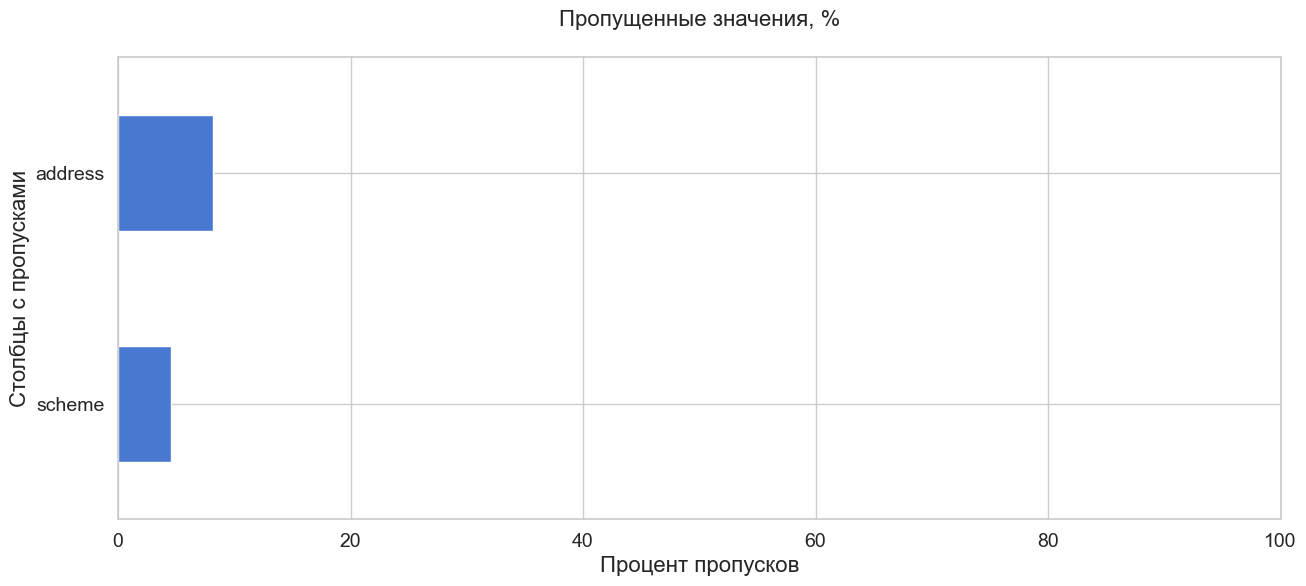

In [33]:
pass_value_barh(accidents, figsize=(15, 6))


Адрес не указан, но у нас есть геоточки, пропуски некритичны.

In [34]:
set(accidents['scheme'].unique())

{'010',
 '020',
 '030',
 '040',
 '050',
 '060',
 '070',
 '090',
 '100',
 '110',
 '120',
 '130',
 '140',
 '190',
 '200',
 '210',
 '220',
 '230',
 '300',
 '310',
 '320',
 '330',
 '340',
 '400',
 '410',
 '420',
 '430',
 '440',
 '500',
 '600',
 '610',
 '620',
 '630',
 '700',
 '710',
 '720',
 '730',
 '740',
 '750',
 '760',
 '770',
 '780',
 '800',
 '810',
 '820',
 '830',
 '840',
 '850',
 '860',
 '870',
 '880',
 '900',
 '910',
 '920',
 '930',
 '940',
 '950',
 '960',
 '970',
 '980',
 None}

Мы не можем восстановить точные расшифровки схем ДТП, так как в открытом доступе нет полного списка. Одни и те же коды могу означать разные вещи в разных регионах. Удалим этот столбец.

In [35]:
accidents.drop(columns=['scheme'], inplace=True)

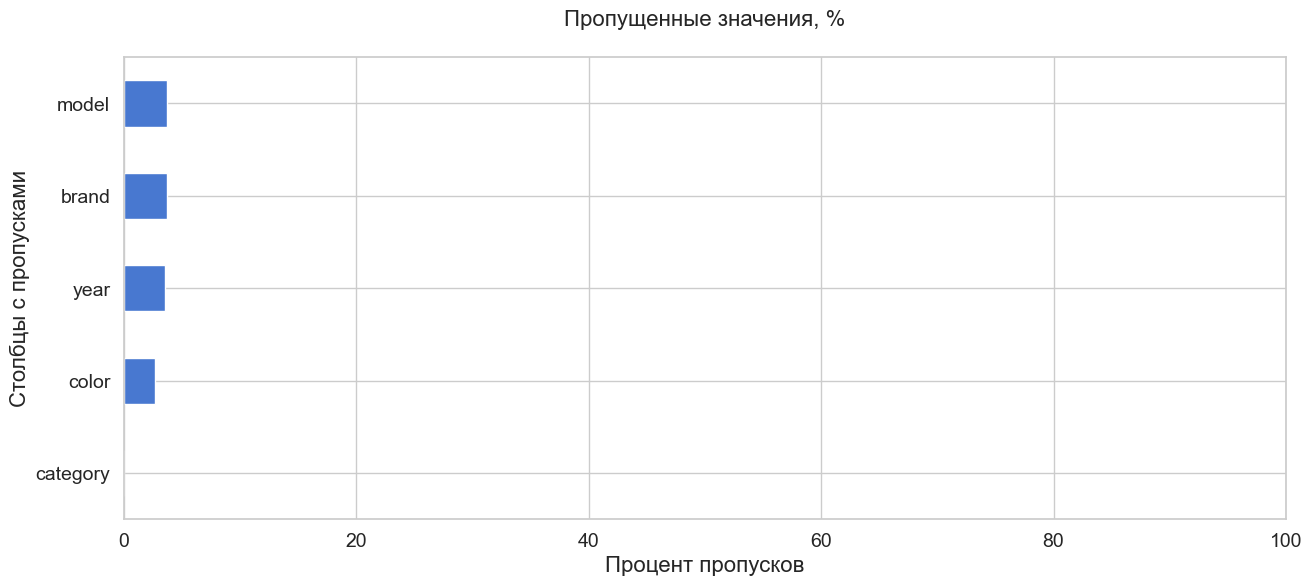

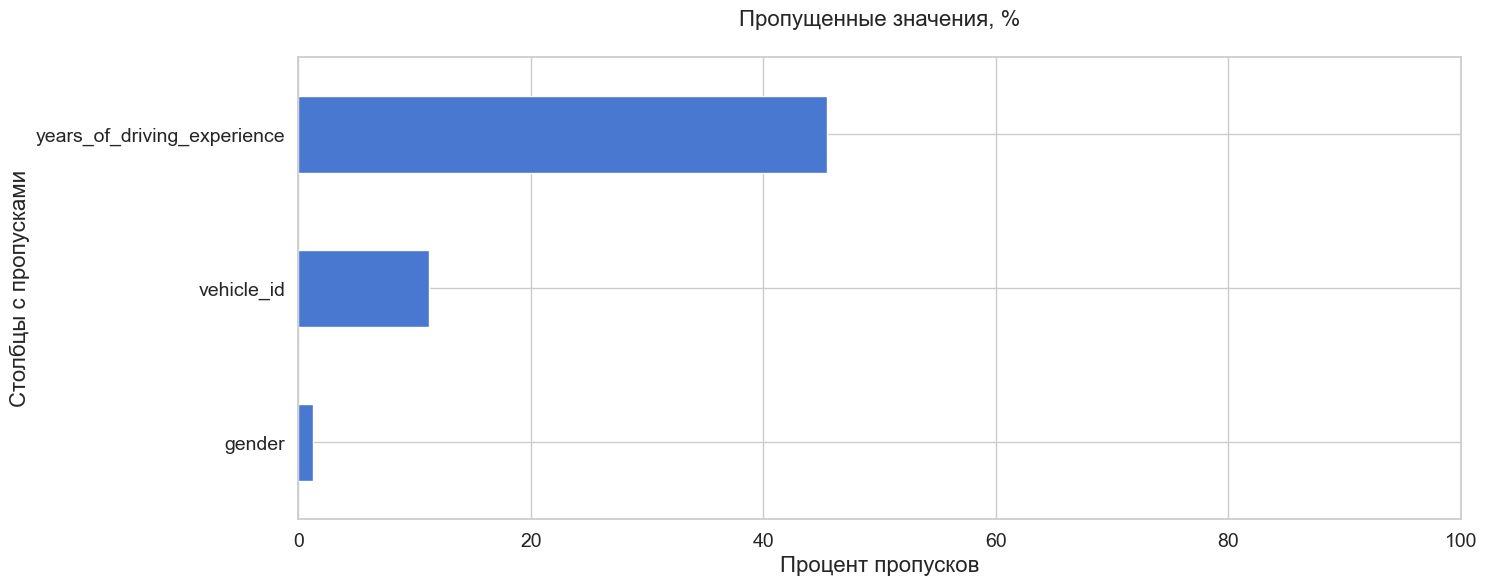

пропусков не осталось :)
пропусков не осталось :)


In [36]:
pass_value_barh(vehicles, figsize=(15, 6))
pass_value_barh(participants, figsize=(15, 6))
pass_value_barh(road_conditions, figsize=(15, 6))
pass_value_barh(nearby, figsize=(15, 6))

Пропуски некритичны, заполнять не будем. Стаж вождения не указан у не-водителей.

### Нормализация столбцов

#### Тяжесть ДТП

Мы можем перекодировать данные столбца в буквенный формат, чтобы облегчить датасет.

In [37]:
# посмотрим, какие есть значения
accidents['severity'].value_counts()

severity
Легкий         31107
Тяжёлый        16035
С погибшими     4592
Name: count, dtype: int64

In [38]:
# создадим словарь для замены
severity_map = {
    'С погибшими': 'F',     # Fatal
    'Тяжёлый': 'S',         # Serious
    'Легкий': 'M'           # Minor
}

# применяем словарь
accidents['severity'] = accidents['severity'].map(severity_map).fillna(accidents['severity'])

In [39]:
# смотрим, что получилось
accidents['severity'].value_counts()

severity
M    31107
S    16035
F     4592
Name: count, dtype: int64

#### Статус здоровья участников

Значения занимают много места, для нас не так важно, через сколько дней после ДТП скончался человек, если он скончался.\
Нормализуем столбец.

In [40]:
participants['health_status'].value_counts()

health_status
Не пострадал                                                                                                                                        52466
Раненый, находящийся (находившийся) на амбулаторном лечении, либо в условиях дневного стационара                                                    34551
Раненый, находящийся (находившийся) на стационарном лечении                                                                                         20814
Получил телесные повреждения с показанием к лечению в медицинских организациях (кроме разовой медицинской помощи)                                    8959
Получил травмы с оказанием разовой медицинской помощи, к категории раненый не относится                                                              3839
Скончался на месте ДТП до приезда скорой медицинской помощи                                                                                          3464
Скончался в течение 1 суток                                   

Нормализуем данные на категории: 'F' (погиб), 'S' (стационар), 'M' (амбулаторный), 'N' (не пострадал), 'U' (неизвестно) или исходное значение, если не классифицировано.

In [41]:
# Применяем функцию к столбцу health_status
participants['health_status'] = participants['health_status'].apply(normalize_health_status)

In [42]:
# проверяем
participants['health_status'].value_counts()

health_status
N    56915
M    43510
S    20814
F     5371
Name: count, dtype: int64

Все значения распределены.

#### Категория ТС

In [43]:
# посмотрим, какие есть значения
vehicles.category.value_counts()

category
В-класс (малый) до 3,9 м                                                                     31357
С-класс (малый средний, компактный) до 4,3 м                                                 11562
Прочие легковые автомобили                                                                    8048
D-класс (средний) до 4,6 м                                                                    4977
Мотоциклы                                                                                     3680
                                                                                             ...  
Транспортные средства для перевозки сжиженных углеводородных газов на давление до 1,8 Мпа        1
Автоцементовозы                                                                                  1
Боевая техника                                                                                   1
Двухярусные                                                                                      1
С

77  различных наименований. Это хорошо для подробного рассмотрения, но для графиков лучше нормализовать в несколько категорий.\
Примем во внимание стандартные категории водительских прав и добавим:
- B  = легковые автомобили
- A  = мотоциклы, мопеды, квадроциклы
- M  = мопеды до 50 куб.см
- V  = велосипеды, персональные электрические средства
- C  = грузовые автомобили
- D  = автобусы, троллейбусы
- Tm = трамваи
- S  = спецтехника, трактора
- X  = спецслужбы - 101-104
- R  = ж/д
- Z = военная техника
- U  = неизвестно

In [44]:
# проведем нормализацию с использованием функции
vehicles['category'] = vehicles['category'].apply(normalize_category)
vehicles['category'].value_counts()

category
B     60438
C      7298
A      4639
D      3408
V      2261
M      1645
U      1627
S      1219
Tm      165
X       152
R        37
Z         7
Name: count, dtype: int64

#### Роли участников

Посмотрим на имеющиеся значения.

In [45]:
# посмотрим, какие есть значения
participants['role'].value_counts().reset_index()

,role,count
0,Водитель,80841
1,Пассажир,29556
2,Пешеход,13832
3,Велосипедист,1883
4,"Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира",266
5,Иной участник,143
6,"Работник дорожной организации, осуществляющий работы на проезжей части (обочине и т.д.)",33
7,"Сотрудник ДПС (ГИБДД), выполняющий служебные обязанности на проезжей части (обочине и т.д.)",27
8,"Работник иных организаций (коммунальных служб, электросетей, водоканала и т.д.), осуществляющий работы на проезжей части (обочине и т.д.)",8
9,"Сотрудник полиции (кроме ГИБДД), сотрудник (военнослужащий) Росгвардии, Минобороны, ФСБ, ФСО, МЧС и т.д., выполняющий служебные обязанности на проезжей части (обочине и т.д.)",8


Длинные строки, которые можно укоротить без потери смысла.

In [46]:
# сделаем словарь для замен
role_mapping = {
    "Водитель": "Водитель",
    "Пассажир": "Пассажир",
    "Пешеход": "Пешеход",
    "Велосипедист": "Велосипедист",
    "Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира": "Пешеход c (из) ТС",
    "Иной участник": "Иной участник",
    "Работник дорожной организации, осуществляющий работы на проезжей части (обочине и т.д.)": "Работник дорожных служб",
    "Сотрудник ДПС (ГИБДД), выполняющий служебные обязанности на проезжей части (обочине и т.д.)": "Сотрудник ДПС",
    "Работник иных организаций (коммунальных служб, электросетей, водоканала и т.д.), осуществляющий работы на проезжей части (обочине и т.д.)": "Работник коммунальных служб",
    "Сотрудник полиции (кроме ГИБДД), сотрудник (военнослужащий) Росгвардии, Минобороны, ФСБ, ФСО, МЧС и т.д., выполняющий служебные обязанности на проезжей части (обочине и т.д.)": "Сотрудник силовых структур",
    "Погонщик скота": "Погонщик скота",
    "Лицо, осуществляющее торговлю (иную деятельность) на проезжей части (обочине и т.д.)": "Торговец на дороге",
    "Всадник": "Всадник"
}

In [47]:
# применяем маппинг
participants['role'] = participants['role'].map(role_mapping).fillna(participants['role'])

In [48]:
# посмотрим, что получилось
participants['role'].value_counts()

role
Водитель                       80841
Пассажир                       29556
Пешеход                        13832
Велосипедист                    1883
Пешеход c (из) ТС                266
Иной участник                    143
Работник дорожных служб           33
Сотрудник ДПС                     27
Работник коммунальных служб        8
Сотрудник силовых структур         8
Погонщик скота                     6
Торговец на дороге                 4
Всадник                            3
Name: count, dtype: int64

Короткие и понятные значения.

#### Пол участников

Посмотрим, какие есть значения.

In [49]:
participants['gender'].unique()

array(['Мужской', 'Женский', None], dtype=object)

Заменим на М и Ж, для пропусков "-" прочерк.

In [50]:
# используем маппинг
gender_map = {
    "Мужской": "М",
    "Женский": "Ж"
}

# применяем, если у нас нет значения в словаре, оставляем оригинал
participants['gender'] = participants['gender'].map(gender_map).fillna(participants['gender'])

# заменяем пропуски
participants['gender'] = participants['gender'].fillna('-')

In [51]:
# проверим
participants['gender'].value_counts()

gender
М    86386
Ж    38667
-     1557
Name: count, dtype: int64

В основном данные есть. Для 1557 участников пол не указан.

#### Категория ДТП

Рассмотрим наименования категорий ДТП.

In [52]:
accidents['category'].value_counts()

category
Столкновение                                                                                                             22878
Наезд на пешехода                                                                                                        12929
Съезд с дороги                                                                                                            5603
Наезд на препятствие                                                                                                      2599
Наезд на велосипедиста                                                                                                    1924
Опрокидывание                                                                                                             1814
Падение пассажира                                                                                                         1778
Наезд на стоящее ТС                                                                                   

Есть длинные наименоваия, которые будут мешать на графиках.

In [53]:
# создаем словарь
category_short_names = {
    'Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ': 'Наезд на рабочего',
    'Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы': 'Наезд на служащего',
    'Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность': 'Наезд на прохожего',
    'Наезд на внезапно возникшее препятствие': 'Наезд на внезапное препятствие',
    'Возгорание вследствие технической неисправности движущегося или остановившегося ТС, участвующего в дорожном движении.': 'Возгорание ТС'
}

# заменяем
accidents['category'] = accidents['category'].map(category_short_names).fillna(accidents['category'])

In [54]:
# посмотрим, что получилось
accidents['category'].value_counts()

category
Столкновение                      22878
Наезд на пешехода                 12929
Съезд с дороги                     5603
Наезд на препятствие               2599
Наезд на велосипедиста             1924
Опрокидывание                      1814
Падение пассажира                  1778
Наезд на стоящее ТС                1535
Наезд на животное                   283
Иной вид ДТП                        252
Отбрасывание предмета                45
Наезд на рабочего                    28
Наезд на служащего                   23
Наезд на прохожего                   17
Наезд на внезапное препятствие       12
Возгорание ТС                         9
Падение груза                         5
Name: count, dtype: int64

#### Нарушения участников

У нас длинные наименования, посмотрим и сократим их.

In [55]:
# Получаем множество уникальных нарушений
all_violations = set(v for sublist in participants['violations'] for v in sublist)

# выводим
display(all_violations)
print("Уникальных нарушений:", len(all_violations))

{'Выезд на полосу встречного движения',
 'Выезд на полосу встречного движения в местах, где это запрещено',
 'Выезд на полосу встречного движения с разворотом, поворотом налево или объездом препятствия',
 'Выезд на трамвайные пути встречного направления',
 'Движение вдоль проезжей части попутного направления вне населенного пункта при удовлетворительном состоянии обочины',
 'Движение вдоль проезжей части при наличии и удовлетворительном состоянии тротуара',
 'Движение во встречном направлении по дороге с односторонним движением',
 'Другие нарушения ПДД водителем',
 'Игра на проезжей части',
 'Иные нарушения',
 'Нарушение водителем правил применения ремней безопасности (ставится в случае, когда не пристегнут водитель)',
 'Нарушение водителем правил применения ремней безопасности (ставится в случае, когда не пристегнут пассажир)',
 'Нарушение правил буксировки',
 'Нарушение правил движения в жилых зонах',
 'Нарушение правил движения тяжеловесного и(или) крупногабаритного ТС(превышение до

Уникальных нарушений: 95


In [56]:
# словарь замен
violations_map = {
    "Выезд на полосу встречного движения": "Выезд на встречку",
    "Выезд на полосу встречного движения в местах, где это запрещено": "Выезд на встречку (запрещено)",
    "Выезд на полосу встречного движения с разворотом, поворотом налево или объездом препятствия": "Выезд на встречку (манёвр)",
    "Выезд на трамвайные пути встречного направления": "Выезд на встречные трамвайные пути",
    "Другие нарушения ПДД водителем": "Другие нарушения",
    "Другие нарушения ПДД водителями (не применяется с 12.2020)": "Другие нарушения",
    "Нарушение водителем правил применения ремней безопасности (ставится в случае, когда не пристегнут водитель)": "Без ремня (водитель)",
    "Нарушение водителем правил применения ремней безопасности (ставится в случае, когда не пристегнут пассажир)": "Без ремня (пассажир)",
    "Нарушение правил перевозки детей (не использование детских сидений либо удерживающих устройств)": "Нарушение перевозки детей",
    "Несоблюдение очередности проезда": "Очередность проезда",
    "Несоблюдение требований ОСАГО": "Нарушение ОСАГО",
    "Неправильный выбор дистанции": "Выбор дистанции",
    "Несоответствие скорости конкретным условиям движения": "Несоответствие скорости",
    "Превышение установленной скорости движения": "Превышение скорости",
    "Управление ТС в состоянии алкогольного опьянения": "Водитель пьян",
    "Управление ТС в состоянии наркотического опьянения": "Наркотическое опьянение",
    "Оставление места ДТП": "Скрытие с места ДТП",
    "Опасное вождение": "Опасное вождение",
    "Управление ТС лицом, не имеющим права на управление ТС": "Нет прав",
    "Управление ТС лицом, лишенным права управления": "Лишён прав",
    "Пешеход в состоянии алкогольного опьянения": "Пешеход пьян",
    "Пешеход в состоянии наркотического опьянения": "Пешеход под наркотиками",
    "Иные нарушения": "Иные",
    "Движение вдоль проезжей части попутного направления вне населенного пункта при удовлетворительном состоянии обочины": "Движение вдоль проезжей части (вне НП)",
    "Движение вдоль проезжей части при наличии и удовлетворительном состоянии тротуара": "Движение вдоль проезжей части (при наличии тротуара)",
    "Движение во встречном направлении по дороге с односторонним движением": "Движение против потока на односторонке",
    "Нарушение правил движения тяжеловесного и(или) крупногабаритного ТС(превышение допустимых габаритов ТС, превышением допустимой массы ТС или допустимой нагрузки на ось ТС)": "Нарушение правил движения тяжеловесного ТС",
    "Нарушение правил движения тяжеловесного и(или) крупногабаритного ТС(превышение допустимых габаритов ТС, превышением допустимой массы ТС или допустимой нагрузки на ось ТС)": "Нарушение правил движения тяжеловесного ТС",
    "Нахождение на проезжей части без цели её перехода": "На проезжей части без цели перехода",
    "Невыполнение требований обеспечения безопасности при начале движения": "Невыполнение требований при начале движения",
    "Незаконное нанесение специальных цветографических схем автомобилей оперативных служб": "Незаконные спецсхемы на авто",
    "Неповиновение или сопротивление находящемуся при исполнении служебных обязанностей сотруднику правоохранительных органов или военнослужащему при остановке или задержании ТС": "Сопротивление сотруднику при остановке",
    "Неподача или неправильная подача сигналов поворота": "Неправильная подача сигналов поворота",
    "Неподчинение сигналам регулирования": "Неподчинение сигналам регулировщика",
    "Непредоставление преимущества в движении ТС, имеющему нанесенные на наружные поверхности специальные цветографические схемы, надписи и обозначения, с одновременно включённым проблесковым маячком синего цвета и специальным звуковым сигналом": "Непредоставление преимущества спецтранспорту",
    "Несоблюдение бокового интервала": "Несоблюдение бокового интервала",
    "Несоблюдение условий, разрешающих движение транспорта задним ходом": "Нарушение условий движения задним ходом",
    "Ожидание маршрутного ТС на проезжей части, вне посадочных площадок, тротуаров и обочин (при их наличии)": "Ожидание транспорта на проезжей части",
    "Ослепление светом фар": "Ослепление встречных светом фар",
    "Оставление движущегося транспортного средства (выход или выпрыгивание на ходу и т.д.)": "Выход из движущегося ТС",
    "Отказ водителя от прохождения медицинского освидетельствования на состояние опьянения": "Отказ от медосвидетельствования",
    "Отказ водителя, не имеющего права управления ТС либо лишенного права управления ТС от прохождении медицинского освидетельствования на состояние опьянения": "Отказ от медосвидетельствования",
    "Отказ водителя, не имеющего права управления ТС либо лишенного права управления ТС, от прохождения медицинского освидетельствования на состояние опьянения (не применяется с 12.2020)": "Отказ от медосвидетельствования",
    "Отсутствие световозвращающих элементов": "Нет световозвращающих элементов",
    "Отсутствие у водителя документов, предусмотренных законодательными и иными НПА": "Отсутствие необходимых документов",
    "Передача управления ТС лицу, находящемуся в состоянии опьянения": "Передача управления пьяному",
    "Передвижение по проезжей части на скейтборде (роликовых коньках и т.д.)": "Передвижение на скейтборде по проезжей части",
    "Пересечение велосипедистом проезжей части по пешеходному переходу": "Пересечение ПП на велосипеде",
    "Переход проезжей части в запрещённом месте (оборудованном пешеходными  ограждениями)": "Переход в запрещённом месте",
    "Переход проезжей части перед приближающимся ТС с включёнными проблесковым маячком синего (сине-красного) цвета и звуковым сигналом": "Переход перед спецтранспортом",
    "Переход через проезжую часть в неустановленном месте (при наличии в зоне видимости перекрёстка)": "Переход в неустановленном месте (виден перекрёсток)",
    "Переход через проезжую часть вне пешеходного перехода в зоне его видимости либо при наличии в непосредственной близости подземного (надземного) пешеходного перехода": "Переход вне ПП при его наличии",
    "Пешеход в возрасте до 7 лет без взрослого": "Пешеход до 7 лет без взрослого",
    "Пользование мобильной связью во время управления автомобилем": "Телефон за рулём",
    "Разворот в местах, где разворот запрещён": "Разворот в запрещённом месте",
    "Светопропускание стекол менее нормативного": "Нарушение светопропускания стекол",
    "Создание помех для водителя в управлении транспортным средством": "Создание помех при управлении",
    "Стоянка на проезжей части или обочине без освещения": "Стоянка без освещения",
    "Употребление водителем алкогольных напитков, наркотических, психотропных или иных одурманивающих веществ после дорожно-транспортного происшествия, к которому он причастен, до проведения освидетельствования с целью установления состояния опьянения или до принятия решения об освобождении от проведения такого освидетельствования": "Употребление алко/веществ после ДТП",
    "Управление ТС без очков (контактных линз) в случае, когда их использование водителем обязательно": "Управление без очков (обязательно)",
    "Управление ТС в состоянии нетрудоспособности (болезни)": "Управление в состоянии болезни",
    "Управление ТС лицом, не имеющим соответствующей категории на управление ТС данного вида": "Нет нужной категории",
    "Управление в состоянии переутомления, сон за рулём": "Переутомление / сон за рулём",
    "Управление велосипедом с неисправной тормозной системой": "Велосипед с неисправными тормозами",
    "Управление велосипедом, не оснащённым светоотражающими элементами": "Велосипед без светоотражателей",
    "Управление мопедом лицом моложе 16 лет": "Мопед — водитель младше 16",
    "Управление при движении по автодороге велосипедом, гужевой повозкой лицом моложе 14 лет": "Велосипед/повозка — водитель младше 14",
    "Управление транспортным средством при наличии неисправностей или условий, при которых эксплуатация транспортного средства запрещена": "Эксплуатация неисправного ТС",
    "Эксплуатация ТС с техническими неисправностями, при которых запрещается их эксплуатация": "Эксплуатация неисправного ТС",
    "Эксплуатация технически неисправного ТС (проставляется в случае ДТП по причине технеисправности)": "Эксплуатация неисправного ТС",
    "Эксплуатация незарегистрированного ТС": "Незарегистрированное ТС",
    "Игра на проезжей части": "Игра на проезжей части",
    "Нарушение правил буксировки": "Нарушение правил буксировки",
    "Нарушение правил движения в жилых зонах": "Нарушение правил в жилых зонах",
    "Нарушение правил обгона": "Нарушение правил обгона",
    "Нарушение правил остановки и стоянки": "Нарушение правил остановки/стоянки",
    "Нарушение правил перевозки крупногабаритных и тяжеловесных грузов": "Нарушение перевозки крупногабаритных грузов",
    "Нарушение правил перевозки людей": "Нарушение перевозки людей",
    "Нарушение правил перевозки опасных грузов": "Нарушение перевозки опасных грузов",
    "Нарушение правил перестроения": "Нарушение правил перестроения",
    "Нарушение правил погрузки, выгрузки и крепления грузов": "Нарушение погрузки/выгрузки грузов",
    "Нарушение правил пользования внешними световыми приборами": "Нарушение использования световых приборов",
    "Нарушение правил пользования общественным транспортом": "Нарушение правил пользования общественным транспортом",
    "Нарушение правил при круговом движении": "Нарушение правил на круговом движении",
    "Нарушение правил применения мотошлема": "Без мотошлема (водитель)",
    "Нарушение правил применения мотошлема пассажиром": "Без мотошлема (пассажир)",
    "Нарушение правил применения ремней безопасности пассажиром": "Без ремня (пассажир)",
    "Нарушение правил проезда ж/д переездов": "Нарушение проезда ж/д переездов",
    "Нарушение правил проезда остановок трамвая": "Нарушение проезда остановок трамвая",
    "Нарушение правил проезда пешеходного перехода": "Нарушение проезда пешеходного перехода",
    "Нарушение правил расположения ТС на проезжей части": "Нарушение расположения ТС",
    "Нарушение правил учебной езды": "Нарушение правил учебной езды",
    "Нарушение режима труда и отдыха водителя": "Нарушение режима труда/отдыха",
    "Нарушение требований дорожных знаков": "Нарушение требований дорожных знаков",
    "Нарушение требований линий разметки": "Нарушение требований разметки",
    "Нарушение требований сигналов регулировщика": "Неподчинение сигналам регулировщика",
    "Нарушение требований сигналов светофора": "Нарушение сигналов светофора",
    "Неподача или неправильная подача сигналов": "Неправильная подача сигналов",
    "Непредоставление преимущества в движении пешеходу": "Непредоставление преимущества пешеходу",
    "Несоблюдение очередности проезда перекрестков": "Очередность проезда",
    "Неожиданный выход из-за ТС": "Неожиданный выход из-за ТС",
    "Неожиданный выход из-за сооружений (деревьев)": "Неожиданный выход из-за сооружений",
    "Неожиданный выход из-за стоящего ТС": "Неожиданный выход из-за стоящего ТС",
    "Отсутствие световозвращающих жилетов (снаряжения) у лиц, осуществляющих работу на проезжей части": "Нет световозвращающих жилетов",
    "Пользование во время движения незаконно установленными устройствами для подачи специальных световых и звуковых сигналов": "Незаконные спецсигналы",
    "Управление ТС лицом, находящимся в состоянии алкогольного опьянения и не имеющим права управления ТС либо лишенным права управления ТС": "Водитель пьян, нет прав/лишён прав",
    "Управление ТС лицом, находящимся в состоянии алкогольного опьянения и не имеющим права управления ТС либо лишенным права управления ТС (не применяется с 12.2020)": "Водитель пьян, нет прав/лишён прав",
    "Управление ТС лицом, находящимся в состоянии наркотического опьянения и не имеющим права управления ТС либо лишенным права управления ТС": "Наркотическое опьянение, нет прав/лишён прав",
    "Управление ТС лицом, находящимся в состоянии наркотического опьянения и не имеющим права управления ТС либо лишенным права управления ТС (не применяется с 12.2020)": "Наркотическое опьянение, нет прав/лишён прав",
    "Ходьба вдоль проезжей части попутного направления вне населенного пункта при удовлетворительном состоянии обочины": "Движение вдоль проезжей части (вне НП)",
    "Ходьба вдоль проезжей части при наличии и удовлетворительном состоянии тротуара": "Движение вдоль проезжей части (при наличии тротуара)",
    'Нарушение\xa0правил\xa0движения тяжеловесного и(или) крупногабаритного ТС(превышение допустимых габаритов ТС, превышением допустимой массы ТС или допустимой нагрузки на ось ТС)':"Нарушение правил движения тяжеловесного ТС",
    'Употребление водителем алкогольных напитков, наркотических, психотропных или иных одурманивающих веществ после дорожно-транспортного происшествия, к которому он причастен, до проведения освидетельствования с целью установления состояния опьянения или до принятия решения об освобождении от проведения такого освидетельствовани':"Употребление алко/веществ после ДТП",
    
}

In [57]:
# применяем функцию
participants['violations'] = participants['violations'].apply(shorten_violations)

In [58]:
# Получаем множество уникальных нарушений
all_violations = set(v for sublist in participants['violations'] for v in sublist)

# посмотрим, что получилось
display(all_violations)
print("Уникальных нарушений:", len(all_violations))

{'Без мотошлема (водитель)',
 'Без мотошлема (пассажир)',
 'Без ремня (водитель)',
 'Без ремня (пассажир)',
 'Велосипед без светоотражателей',
 'Велосипед с неисправными тормозами',
 'Велосипед/повозка — водитель младше 14',
 'Водитель пьян',
 'Выбор дистанции',
 'Выезд на встречку',
 'Выезд на встречку (запрещено)',
 'Выезд на встречку (манёвр)',
 'Выезд на встречные трамвайные пути',
 'Выход из движущегося ТС',
 'Движение вдоль проезжей части (вне НП)',
 'Движение вдоль проезжей части (при наличии тротуара)',
 'Движение против потока на односторонке',
 'Другие нарушения',
 'Игра на проезжей части',
 'Иные',
 'Лишён прав',
 'Мопед — водитель младше 16',
 'На проезжей части без цели перехода',
 'Наркотическое опьянение',
 'Нарушение ОСАГО',
 'Нарушение использования световых приборов',
 'Нарушение перевозки детей',
 'Нарушение перевозки людей',
 'Нарушение перевозки опасных грузов',
 'Нарушение погрузки/выгрузки грузов',
 'Нарушение правил буксировки',
 'Нарушение правил в жилых зонах'

Уникальных нарушений: 91


#### Окружение

Посмотрим, какие значения присутствуют

In [59]:
nearby['nearby'].unique()

array(['Многоквартирные жилые дома', 'Внутридворовая территория',
       'Жилые дома индивидуальной застройки',
       'Нерегулируемый перекрёсток неравнозначных улиц (дорог)',
       'Медицинские (лечебные) организации', 'Эстакада, путепровод',
       'Мост', 'Нерегулируемый пешеходный переход',
       'Административные здания', 'АЗС',
       'Остановка общественного транспорта',
       'Регулируемый пешеходный переход',
       'Выезд с прилегающей территории',
       'Подход к мосту, эстакаде, путепроводу',
       'Регулируемый перекресток', 'Объект строительства',
       'Нерегулируемый перекрёсток', 'Кладбище',
       'Регулируемый перекрёсток',
       'Регулируемый ж/д переезд без дежурного',
       'Крупный торговый объект (являющийся объектом массового тяготения пешеходов и (или) транспорта)',
       'Школа либо иная детская (в т.ч. дошкольная) организация',
       'Нерегулируемый перекрёсток равнозначных улиц (дорог)',
       'Иной объект', 'Нерегулируемый ж/д переезд',
       

Присутствуют длинные наименования. Сократим.
Есть перекрёсток и перекресток.

In [60]:
# маппинг для сокращений
nearby_map = {
    "Нерегулируемый перекрёсток неравнозначных улиц (дорог)": "Нерег. перекресток (неравн.)",
    "Нерегулируемый перекрёсток равнозначных улиц (дорог)": "Нерег. перекресток (равн.)",
    "Нерегулируемое пересечение с круговым движением": "Нерег. круговое",
    "Нерегулируемый пешеходный переход, расположенный на участке улицы или дороги, проходящей вдоль территории школы или иной детской организации": "Нерег. п/п у школы",
    "Регулируемый пешеходный переход, расположенный на участке улицы или дороги, проходящей вдоль территории школы или иной детской организации": "Рег. п/п у школы",
    "Крупный торговый объект (являющийся объектом массового тяготения пешеходов и (или) транспорта)": "Крупный ТЦ",
    "Одиночный торговый объект, являющийся местом притяжения транспорта и (или) пешеходов": "Магазин",
    "Объект торговли, общественного питания на автодороге вне НП": "Торговля/кафе вне НП",
    "Аэропорт, ж/д вокзал (ж/д станция), речной или морской порт (пристань)": "Аэропорт/вокзал/порт",
    "Автостоянка (отделенная от проезжей части)": "Стоянка (отдел.)",
    "Автостоянка (не отделённая от проезжей части)": "Стоянка (не отдел.)",
    "Жилые дома индивидуальной застройки": "Частные дома",
    "Многоквартирные жилые дома": "Многоквартирные дома",
    "Административные здания": "Адм. здания",
    "Медицинские (лечебные) организации": "Больница",
    "Школа либо иная детская (в т.ч. дошкольная) организация": "Школа/детсад",
    "Иная образовательная организация": "Учебное заведение",
    "Спортивные и развлекательные объекты": "Спорт/развлечение",
    "Зоны отдыха": "Зона отдыха",
    "Территориальное подразделение МВД России (либо его структурное подразделение)": "МВД",
    "Объект (здание, сооружение) религиозного культа": "Церковь/мечеть",
    "Внутридворовая территория": "Двор",
    "Производственное предприятие": "Завод",
    "Ледовая переправа(официально открытая и оборудованная)": "Офиц. ледовая переправа",
    "Стихийно возникшая (не предусмотренная) ледовая переправа": "Стихийн. ледовая переправа",
    "Тротуар, пешеходная дорожка": "Тротуар",
    "Подход к мосту, эстакаде, путепроводу": "Подход к мосту/эстакаде",
    "Объект строительства": "Стройка",
    "Регулируемый перекрёсток": "Регулируемый перекресток",
    # "Иной объект": "Другое"
}


# применяем
nearby['nearby'] = nearby['nearby'].map(nearby_map).fillna(nearby['nearby'])

In [61]:
# смотрим, что получилось
nearby['nearby'].value_counts().reset_index()

,nearby,count
0,Многоквартирные дома,16677
1,Нерег. перекресток (неравн.),9326
2,Остановка общественного транспорта,8990
3,Частные дома,8501
4,Нерегулируемый пешеходный переход,8168
5,Регулируемый перекресток,7635
6,Адм. здания,6865
7,Регулируемый пешеходный переход,6734
8,Крупный ТЦ,4002
9,Выезд с прилегающей территории,3006


Наименования будут корректно смотреться на графиках и диаграммах.

#### Состояние дороги

In [62]:
road_conditions['road_conditions'].unique()

array(['Сухое', 'Отсутствие временных ТСОД в местах проведения работ',
       'Недостатки зимнего содержания', 'Со снежным накатом',
       'Отсутствие дорожных знаков в необходимых местах', 'Гололедица',
       'Отсутствие, плохая различимость горизонтальной разметки проезжей части',
       'Мокрое', 'Заснеженное',
       'Обработанное противогололедными материалами',
       'Неправильное применение, плохая видимость дорожных знаков',
       'Отсутствие тротуаров (пешеходных дорожек)',
       'Отсутствие освещения', 'Неисправное освещение',
       'Дефекты покрытия', 'Недостаточное освещение',
       'Отсутствие направляющих устройств и световозвращающих элементов на них',
       'Неудовлетворительное состояние обочин', 'Иные недостатки',
       'Залитое (покрытое) водой',
       'Свежеуложенная поверхностная обработка',
       'Отсутствие, плохая различимость вертикальной разметки',
       'Отсутствие элементов обустройства остановочного пункта общественного пассажирского транспорта'

Наименования длинные, сокращаем

In [63]:
# словарь
road_conditions_map = {
    "Отсутствие, плохая различимость горизонтальной разметки проезжей части": "Плохая горизонтальная разметка",
    "Отсутствие, плохая различимость вертикальной разметки": "Плохая вертикальная разметка",
    "Обработанное противогололедными материалами": "Обработано антигололедом",
    "Отсутствие дорожных знаков в необходимых местах": "Нет дорожных знаков",
    "Недостатки зимнего содержания": "Плохое зимнее содержание",
    "Неправильное применение, плохая видимость дорожных знаков": "Плохая видимость знаков",
    "Отсутствие тротуаров (пешеходных дорожек)": "Нет тротуаров",
    "Со снежным накатом": "Снежный накат",
    "Отсутствие освещения": "Нет освещения",
    "Неудовлетворительное состояние обочин": "Плохие обочины",
    "Отсутствие пешеходных ограждений в необходимых местах": "Нет пешеходных ограждений",
    "Отсутствие элементов обустройства остановочного пункта общественного пассажирского транспорта": "Нет обустройства остановок",
    "Отсутствие дорожных ограждений в необходимых местах": "Нет дорожных ограждений",
    "Несоответствие дорожных ограждений предъявляемым требованиям": "Несоответствие ограждений",
    "Свежеуложенная поверхностная обработка": "Свежая поверхностная обработка",
    "Отсутствие временных ТСОД в местах проведения работ": "Нет временных ТСОД",
    "Отсутствие направляющих устройств и световозвращающих элементов на них": "Нет направляющих устройств",
    "Несоответствие люков смотровых колодцев и ливневой канализации предъявляемым требованиям": "Несоответствие люков",
    "Сужение проезжей части, наличие препятствий, затрудняющих движение транспортных средств": "Сужение проезжей части",
    "Плохая видимость световозвращателей, размещенных на дорожных ограждениях": "Плохая видимость световозвращателей",
    "Отклонение верха головки рельса трамвайных (железнодорожных) путей, расположенных в пределах проезжей части, относительно покрытия, более чем на 2,0 см": "Несоответствие рельсов",
    "Несоответствие железнодорожного переезда предъявляемым требованиям": "Несоответствие ж/д переезда",
    "Неудовлетворительное состояние разделительной полосы": "Плохая разделительная полоса"
}

# Применение маппинга
road_conditions['road_conditions'] = road_conditions['road_conditions'].map(road_conditions_map).fillna(road_conditions['road_conditions'])

In [64]:
# смотрим, что получилось
road_conditions['road_conditions'].value_counts()

road_conditions
Сухое                                  34558
Плохая горизонтальная разметка         11146
Мокрое                                  9320
Обработано антигололедом                4060
Нет дорожных знаков                     2235
Заснеженное                             2085
Плохое зимнее содержание                1901
Плохая видимость знаков                 1279
Иные недостатки                         1208
Нет тротуаров                            978
Снежный накат                            953
Нет освещения                            728
Дефекты покрытия                         609
Плохие обочины                           512
Нет пешеходных ограждений                481
Гололедица                               437
Неровное покрытие                        387
Неисправное освещение                    298
Плохая вертикальная разметка             252
Недостаточное освещение                  159
Загрязненное                             141
Нет обустройства остановок             

#### Категории участников ДТП

In [65]:
accidents.participant_categories_str.value_counts()

participant_categories_str
Все участники                                            30644
Все участники, Пешеходы                                  12765
Все участники, Мотоциклисты                               5254
Все участники, Велосипедисты                              2003
Все участники, Пешеходы, Мотоциклисты                      411
Все участники, Общ. транспорт                              352
Все участники, Пешеходы, Велосипедисты                     139
Все участники, Велосипедисты, Мотоциклисты                  87
Все участники, Пешеходы, Общ. транспорт                     71
Все участники, Мотоциклисты, Общ. транспорт                  4
Все участники, Велосипедисты, Общ. транспорт                 3
Все участники, Пешеходы, Мотоциклисты, Общ. транспорт        1
Name: count, dtype: int64

Наименования длинные, занимают много места.
Предлагаю простую схему:
- B – базовое ДТП («Все участники»);
- P – пешеход;
- M – мотоциклист;
- V – велосипедист;
- O – общ. транспорт.

In [66]:
participant_map = {
    "Все участники": "B",
    "Все участники, Пешеходы": "BP",
    "Все участники, Мотоциклисты": "BM",
    "Все участники, Велосипедисты": "BV",
    "Все участники, Общ. транспорт": "BO",
    "Все участники, Пешеходы, Мотоциклисты": "BPM",
    "Все участники, Пешеходы, Велосипедисты": "BPV",
    "Все участники, Велосипедисты, Мотоциклисты": "BVM",
    "Все участники, Пешеходы, Общ. транспорт": "BPO",
    "Все участники, Мотоциклисты, Общ. транспорт": "BMO",
    "Все участники, Велосипедисты, Общ. транспорт": "BVO",
    "Все участники, Пешеходы, Мотоциклисты, Общ. транспорт": "BPMO",
}

In [67]:
accidents['participant_categories_str'] = (
    accidents['participant_categories_str']
    .map(participant_map)
    .fillna(accidents['participant_categories_str'])
)

In [68]:
accidents.participant_categories_str.value_counts()

participant_categories_str
B       30644
BP      12765
BM       5254
BV       2003
BPM       411
BO        352
BPV       139
BVM        87
BPO        71
BMO         4
BVO         3
BPMO        1
Name: count, dtype: int64

Сократили наименования.\
Сохраним расшифровку, если понадобится.

In [69]:
# создаём датасет
participant_df = pd.DataFrame([
    {"code": v, "description": k}
    for k, v in participant_map.items()
])

participant_df

,code,description
0,B,Все участники
1,BP,"Все участники, Пешеходы"
2,BM,"Все участники, Мотоциклисты"
3,BV,"Все участники, Велосипедисты"
4,BO,"Все участники, Общ. транспорт"
5,BPM,"Все участники, Пешеходы, Мотоциклисты"
6,BPV,"Все участники, Пешеходы, Велосипедисты"
7,BVM,"Все участники, Велосипедисты, Мотоциклисты"
8,BPO,"Все участники, Пешеходы, Общ. транспорт"
9,BMO,"Все участники, Мотоциклисты, Общ. транспорт"


Провели кодировку.

### Аномалии

Проверим, есть ли выбивающиеся данные.

#### ДТП

Рассмотрим общую информацию по числовым столбцам

In [70]:
accidents.describe()

,accident_id,datetime,dead_count,injured_count,participants_count
count,51734.00,51734,51734.00,51734.00,51734.00
mean,1109643.61,2025-04-08 12:21:15.509723136,0.10,1.24,2.45
min,40.00,2025-01-01 00:10:00,0.00,0.00,1.00
25%,833370.25,2025-02-21 10:26:15,0.00,1.00,2.00
50%,1278195.50,2025-04-13 21:34:30,0.00,1.00,2.00
75%,1510221.75,2025-05-25 15:25:45,0.00,1.00,3.00
max,1523161.00,2025-06-30 23:10:00,7.00,37.00,45.00
std,465000.88,NaN,0.37,0.86,1.20


In [71]:
# accidents.apply(lambda x: x.map(lambda y: str(y) if isinstance(y, (list, dict)) else y)).apply(pd.unique).to_frame(name='Unique Values')

В списке ДТП среди числовых столбцов аномалий не обнаружено.

Проверим, есть ли у нас в данных аномалии - аварии, где количество умерших меньше одного и тяжесть аварии - С погибшими.

In [72]:
# проверим на аномалии
accidents.loc[(accidents['dead_count']<1)&(accidents['severity']=='F')]

,accident_id,light,point,region,address,category,datetime,severity,dead_count,injured_count,parent_region,participants_count,geometry,weather_str,participant_categories_str


Аномалии в количестве умерших отсутствуют.

#### Транспортные средства

In [73]:
vehicles.describe()

,year,accident_id,vehicle_id,datetime
count,79912.00,82896.00,82896.00,82896
mean,2012.61,1109262.79,41447.50,2025-04-08 08:40:06.917342208
min,1900.00,40.00,0.00,2025-01-01 00:10:00
25%,2007.00,833328.00,20723.75,2025-02-20 18:23:45
50%,2013.00,1278205.50,41447.50,2025-04-13 15:52:30
75%,2020.00,1510373.25,62171.25,2025-05-25 18:10:00
max,2025.00,1523161.00,82895.00,2025-06-30 23:10:00
std,8.54,465377.12,23930.16,NaN


Посмотрим, что из себя представляют старые авто - 1900 год выглядит нереалистично.

In [74]:
# возьмем первые 0,0005 по столбцу с датой выпуска
vehicles.loc[vehicles['year']<vehicles['year'].quantile(.0005)].sort_values(by='year').head(50)

,year,brand,color,model,category,accident_id,vehicle_id,datetime
13927,1900,KAWASAKI,Синий,ZX,A,1507160,13927,2025-06-25 19:05:00
58040,1900,YAMAHA,Черный,Прочие модели Yamaha,A,1518985,58040,2025-05-28 20:40:00
76449,1900,ИЖ,Иные цвета,Юпитер,A,1511490,76449,2025-06-28 20:30:00
74194,1900,Прочие марки ТС,Оранжевый,Прочие марки и модели ТС,A,1518344,74194,2025-06-01 04:00:00
58320,1900,Прочие марки мотоциклов,Красный,Прочие марки мотоциклов,A,1278183,58320,2025-04-24 18:23:00
58132,1900,Прочие марки мотоциклов,Зеленый,Прочие марки мотоциклов,A,1278174,58132,2025-04-20 18:40:00
58292,1900,Прочие марки ТС,Красный,Прочие марки и модели ТС,M,1518948,58292,2025-06-02 07:50:00
76475,1900,None,Не заполнено,None,U,1511511,76475,2025-06-12 22:10:00
5358,1910,VOLKSWAGEN,Коричневый,Passat,B,1026425,5358,2025-04-26 11:16:00
4151,1910,VOLKSWAGEN,Черный,Passat,B,372530,4151,2025-01-26 16:04:00


Мы видим 12 ТС с годом выпуска старше 1950 года. В случаях, когда указаны марки (Yamaha, Kawasaki), можно предположить, что даты указаны неверно: вместо 1910 теоретически можно было бы указать 2010.

Посмотрим на аварии, авто и участников, чтобы проверить, есть ли какие-то общие сведения, качества, которые их объединяют.

In [75]:
query_year = 1945
query_list_acc = list(vehicles.loc[vehicles['year']<query_year, 'accident_id'].unique())
display(query_list_acc)

query_list_veh = list(vehicles.loc[vehicles['year']<query_year, 'vehicle_id'].unique())
display(query_list_veh)

display(accidents[accidents['accident_id'].isin(query_list_acc[0:4])])
participants.loc[participants['accident_id'].isin(query_list_acc[0:4])&participants['vehicle_id'].isin(query_list_veh[0:4])]

[np.int64(372530),
 np.int64(1510120),
 np.int64(1026425),
 np.int64(1507160),
 np.int64(1518985),
 np.int64(1278174),
 np.int64(1518948),
 np.int64(1278183),
 np.int64(1518344),
 np.int64(1082184),
 np.int64(1511490),
 np.int64(1511511)]

[np.int64(4151),
 np.int64(4845),
 np.int64(5358),
 np.int64(13927),
 np.int64(58040),
 np.int64(58132),
 np.int64(58292),
 np.int64(58320),
 np.int64(74194),
 np.int64(76372),
 np.int64(76449),
 np.int64(76475)]

,accident_id,light,point,region,address,category,datetime,severity,dead_count,injured_count,parent_region,participants_count,geometry,weather_str,participant_categories_str
2606,372530,Светлое время суток,"[55.174512, 61.339127]",Челябинск,"г Челябинск, ул Университетская Набережная, 40А",Столкновение,2025-01-26 16:04:00,M,0,2,Челябинская область,3,"{'type': 'Point', 'coordinates': [61.339127, 55.174512]}",Пасмурно,B
3028,1510120,Светлое время суток,"[55.249411, 61.428573]",Челябинск,"г Челябинск, ул Монтажников, 4",Столкновение,2025-05-30 19:20:00,M,0,2,Челябинская область,4,"{'type': 'Point', 'coordinates': [61.428573, 55.249411]}",Ясно,B
3344,1026425,Светлое время суток,"[54.43356, 61.289699]",Южноуральск,"г Южноуральск, Увельский ХПП - а/д М-36 Челябинск - Троицк - до гр. с Р. Казахстан, 0 км",Столкновение,2025-04-26 11:16:00,M,0,1,Челябинская область,2,"{'type': 'Point', 'coordinates': [61.289699, 54.43356]}",Ясно,B
8757,1507160,Светлое время суток,"[48.968365, 140.284317]",Советско-Гаванский район,"г Советская Гавань, ул Пионерская, 7",Столкновение,2025-06-25 19:05:00,S,0,1,Хабаровский край,3,"{'type': 'Point', 'coordinates': [140.284317, 48.968365]}",Ясно,BM


,role,gender,violations,health_status,years_of_driving_experience,accident_id,vehicle_id
5680,Водитель,М,[Нарушение правил перестроения],N,31,372530,4151
5681,Пассажир,Ж,[],M,<NA>,372530,4151
6585,Водитель,М,[],N,16,1510120,4845
7248,Водитель,М,[Очередность проезда],M,34,1026425,5358
18964,Водитель,М,"[Нарушение ОСАГО, Незарегистрированное ТС, Нет прав]",S,<NA>,1507160,13927


Это эксплуатация незарегистрированного транспортного средства, каких-то устройств собственной сборки. Посмотрим, большую ли долю заниют наши несколько ТС в общем списке подобных нарушений.

In [76]:
mask = participants['violations'].apply(lambda v: "Незарегистрированное ТС" in v if isinstance(v, list) else False)

print(f'Автомобили 1900 года выпуска среди незарегистрированных ТС занимают долю {(len(query_list_veh)/(participants[mask].shape[0])):.2%}')

Автомобили 1900 года выпуска среди незарегистрированных ТС занимают долю 0.65%


In [77]:
participants[mask].shape[0]

1856

Доля незначительна, мы не потеряем статистически значимую информацию. Уберем из датасетов аномальные данные.

In [78]:

dfs = [accidents, vehicles, participants, road_conditions]

# фильтруем все таблицы
dfs = [df.loc[~df['accident_id'].isin(query_list_acc)] for df in dfs]

accidents, vehicles, participants, road_conditions = dfs

#### Участники

In [79]:
participants.describe()

,years_of_driving_experience,accident_id
count,68981.00,126582.00
mean,18.11,1093862.27
std,12.24,469505.89
min,1.00,40.00
25%,8.00,787691.00
50%,16.00,1270030.00
75%,26.00,1509675.75
max,71.00,1523161.00


In [80]:
participants.loc[participants['years_of_driving_experience']>participants['years_of_driving_experience'].quantile(.99)].sort_values(by='years_of_driving_experience')

,role,gender,violations,health_status,years_of_driving_experience,accident_id,vehicle_id
110232,Водитель,М,"[Очередность проезда, Нарушение требований дорожных знаков]",M,51,1462649,81435
104480,Водитель,М,[],N,51,814833,77164
104322,Водитель,М,[Нарушение правил перестроения],M,51,1522695,77046
109172,Водитель,М,[],N,51,1458685,80642
108906,Водитель,М,[Выезд на встречку],F,51,785831,80433
...,...,...,...,...,...,...,...
53479,Водитель,М,[Выбор дистанции],N,67,417495,40237
14676,Водитель,М,[Нарушение ОСАГО],M,68,1517039,10784
45160,Водитель,М,[Несоответствие скорости],N,68,1405369,33952
46479,Водитель,М,[Выбор дистанции],S,70,1421957,35043


<Axes: >

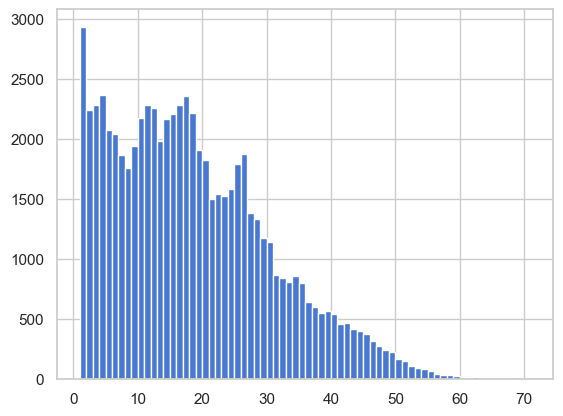

In [81]:
participants['years_of_driving_experience'].hist(bins='auto')

Водители со стажем больше 70 лет выглядят аномально, но их мало, мы не можем утверждать, что это ошибки. Оставляем.

In [82]:
nearby.apply(pd.unique).to_frame(name='Unique Values')

,Unique Values
accident_id,"[883957, 1505843, 1505884, 1505910, 188723, 188811, 188839, 188875, 188944, 188979, 189016, 1505784, 883962, 883997, 1505803, 1505823, 883989, 189057, 204026, 204044, 204064, 204084, 204117, 204188, 204264, 204301, 204341, 204413, 204452, 204485, 204523, 204636, 883963, 883980, 883990, 883998, 884008, 1505797, 1505816, 1505834, 1505850, 1505864, 1505888, 1505897, 1505906, 1505913, 1505919, 1505923, 1505927, 1505930, 1505933, 1505874, 206429, 206496, 206534, 206570, 206611, 206655, 206698, 206741, 206786, 206829, 206871, 206914, 206956, 206995, 207035, 207074, 883964, 883981, 883999, 1505788, 1505807, 1505827, 1505844, 1505873, 1505895, 1505904, 1505911, 1505917, 1505929, 1505932, 208616, 883961, 883988, 883996, 1505791, 1505830, 1505847, 210260, 210290, 210352, 210383, 210416, 210448, 210482, 883959, 1505841, 1505855, 1505869, ...]"
nearby,"[Многоквартирные дома, Двор, Частные дома, Нерег. перекресток (неравн.), Больница, Эстакада, путепровод, Мост, Нерегулируемый пешеходный переход, Адм. здания, АЗС, Остановка общественного транспорта, Регулируемый пешеходный переход, Выезд с прилегающей территории, Подход к мосту/эстакаде, Регулируемый перекресток, Стройка, Нерегулируемый перекрёсток, Кладбище, Регулируемый ж/д переезд без дежурного, Крупный ТЦ, Школа/детсад, Нерег. перекресток (равн.), Иной объект, Нерегулируемый ж/д переезд, Спорт/развлечение, Учебное заведение, Стоянка (отдел.), Зона отдыха, Автовокзал (автостанция), Стоянка (не отдел.), Завод, Аэропорт/вокзал/порт, Магазин, Мост, эстакада, путепровод, Регулируемый ж/д переезд с дежурным, Торговля/кафе вне НП, Церковь/мечеть, МВД, Тротуар, Нерег. круговое, Рег. п/п у школы, Остановка маршрутного такси, Пешеходная зона, Надземный пешеходный переход, Остановка трамвая, Пункт весового контроля, Нерег. п/п у школы, Подземный пешеходный переход, Тоннель, СП ДПС (КПМ), Стихийн. ледовая переправа, Место для перегона скота, Офиц. ледовая переправа]"


Мы выявили аномалии в годе выпуска автомобилей и обработали их.

### Выводы по разделу:
- мы загрузили данные по ДТП;
- отфильтровали за 2025 год;
- разделили данные на несколько датасетов;
- провели кодировку некоторых столбцов;
- обработали аномалии в годе выпуска автомобиля.

## Исследовательский анализ данных

Исследуем столбцы наших датасетов. Начнем с ДТП - `accidents`.

In [83]:
accidents.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51722 entries, 0 to 51733
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   accident_id                 51722 non-null  int64         
 1   light                       51722 non-null  object        
 2   point                       51722 non-null  object        
 3   region                      51722 non-null  object        
 4   address                     47510 non-null  object        
 5   category                    51722 non-null  object        
 6   datetime                    51722 non-null  datetime64[ns]
 7   severity                    51722 non-null  object        
 8   dead_count                  51722 non-null  int64         
 9   injured_count               51722 non-null  int64         
 10  parent_region               51722 non-null  object        
 11  participants_count          51722 non-null  int64         


### Освещение

Посмотрим, как распределены ДТП по времени суток.

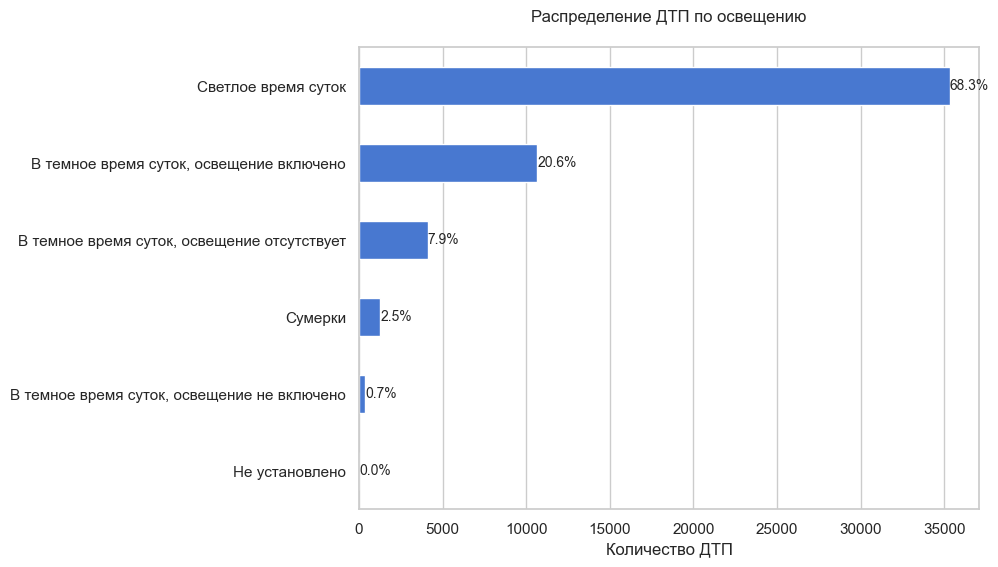

In [84]:
# построим линейчатый график распределения ДТП по освещению
ax = accidents['light'].value_counts().reset_index().assign(
    share=lambda x: x['count'] / x['count'].sum() * 100
).sort_values(by='count', ascending=True).plot(
    x='light',
    y='count',
    kind='barh',
    title='Распределение ДТП по освещению\n',
    xlabel='Количество ДТП',
    ylabel='',
    legend=False,
    figsize=(8, 6)
)

# добавляем подписи с долей
total = accidents['light'].count()
for p in ax.patches:
    width = p.get_width()
    share = width / total * 100
    ax.text(
        width + 1,                  # немного правее столбца
        p.get_y() + p.get_height()/2, # по центру по Y
        f'{share:.1f}%',
        va='center',
        fontsize=10
    )

ax.grid(axis='y')

Большинство аварий происходит в светлое время суток либо ночью при освещении.

Посмотрим, влияет ли освещение на количество смертей.

In [85]:
# Создаем сводную таблицу
df = accidents.pivot_table(
    index='light',
    values=['participants_count', 'dead_count'],
    aggfunc='sum',
    fill_value=0
).reset_index()

# Добавляем столбец proportion с обработкой деления на ноль
df['proportion'] = df.apply(
    lambda x: f'{x["dead_count"]/x["participants_count"]:.2%}' 
    if x["participants_count"] > 0 else '0.00%', 
    axis=1
)

df

,light,dead_count,participants_count,proportion
0,"В темное время суток, освещение включено",976,26135,3.73%
1,"В темное время суток, освещение не включено",104,865,12.02%
2,"В темное время суток, освещение отсутствует",1130,9961,11.34%
3,Не установлено,0,7,0.00%
4,Светлое время суток,3027,86509,3.50%
5,Сумерки,130,3020,4.30%


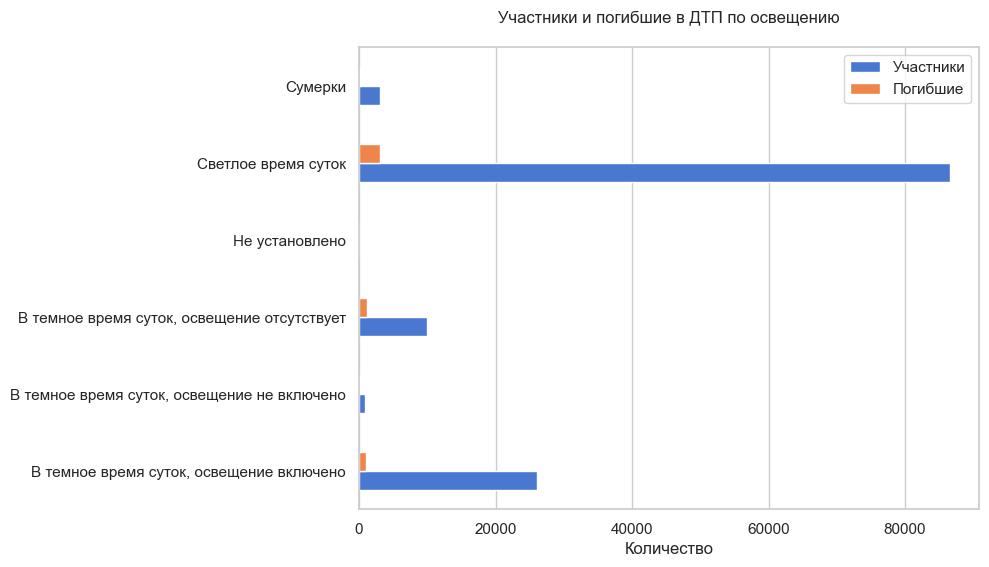

In [86]:
# Построение графика
fig, ax = plt.subplots(figsize=(8, 6))

# Горизонтальная гистограмма для participants_count и dead_count
df.plot(
    x='light',
    y=['participants_count', 'dead_count'],
    kind='barh',
    ax=ax,
    title='Участники и погибшие в ДТП по освещению\n',
    xlabel='Количество',
    ylabel='',
    legend=True
)


plt.grid(axis='y')  # Сетка по оси X
plt.legend(['Участники', 'Погибшие'])
plt.show()

- Судя по таблице и диаграмме, в темное время суток без освещения (или с отключенным) ДТП в 3 раза чаще оказываются смертельными, чем ночью со светом - 11-12% против 3.79%.
- Ночные ДТП с включенным освещением и ДТП в светлое время суток имеют одинаковые доли смертельных случаев.

### Регион и город

Посмотрим, на города, в которых чаще происходят ДТП.

In [87]:
accidents[['parent_region', 'region']].value_counts().reset_index().head(20)

,parent_region,region,count
0,Омская область,Омск,807
1,Новосибирская область,Новосибирск,796
2,Челябинская область,Челябинск,770
3,Тюменская область,Тюмень,742
4,Самарская область,Самара,629
5,Красноярский край,Красноярск,605
6,Воронежская область,Воронеж,555
7,Республика Татарстан (Татарстан),Казань,548
8,Республика Башкортостан,Уфа,502
9,Волгоградская область,Волгоград,446


На случай, если названия городов совпадают, посмотрели в связке с регионами:
- на первом месте Омск, Новосибирск и Челябинск.

In [88]:
accidents['parent_region'].value_counts().reset_index()

,parent_region,count
0,Москва,3679
1,Краснодарский край,2467
2,Челябинская область,1650
3,Московская область,1591
4,Самарская область,1489
...,...,...
77,Еврейская автономная область,91
78,Магаданская область,67
79,Чеченская Республика,65
80,Ненецкий автономный округ,13


- В ТОПе по количеству ДТП Москва (ожидаемо) и Краснодарский край. Потом Челябинская, Московская и Самарская области. Следовало бы выяснить, по каким причинам Краснодарский край на втором месте - количество автомобилей, условия на дороге, культура вождения?
- На последнем месте Чукотский и Ненецкий АО. Мало дорог и автомобилей.

Проверим, возьмем данные с Минтранса и сравним количество аварий и дорог.

In [90]:
url = 'https://mintrans.gov.ru/opendata/7705851331-lengthroads/data-20171102-structure-20171102.csv'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

response = requests.get(url, headers=headers)
response.encoding = 'windows-1251'  # Устанавливаем правильную кодировку

# Загружаем данные с правильной кодировкой
tables = pd.read_csv(
    io.StringIO(response.text),
    encoding='windows-1251',
    sep=';',
    header=0,
    engine='python',
    decimal=','
)

print("Данные успешно загружены!")
tables

Данные успешно загружены!


,Название Федерального округа,Название региона,Категория дороги,"Протяженность автомобильных дорог с твердым покрытием (км), всего",Протяженность автомобильных дорог категория I -А авто-магистрали,Протяженность автомобильных дорог категория I -Б скоростные,Протяженность автомобильных дорог категория I -В,Протяженность автомобильных дорог категория II,Протяженность автомобильных дорог категория III,Протяженность автомобильных дорог категория IV,Протяженность автомобильных дорог категория V
0,Центральный федеральный округ,Белгородская область,федеральные,112.878,-,-,-,561.778,992.400,4771.200,386.100
1,Центральный федеральный округ,Белгородская область,региональные,6598.600,-,-,-,112.878,-,-,-
2,Центральный федеральный округ,Белгородская область,"категории ""Е"" (европейские)",112.878,-,-,-,448.900,992.400,4771.200,386.100
3,Центральный федеральный округ,Белгородская область,"категории ""АН"" (азиатские)",-,-,-,-,112.878,-,-,-
4,Центральный федеральный округ,Брянская область,федеральные,567.215,-,2.427,-,536.759,28.029,-,-
...,...,...,...,...,...,...,...,...,...,...,...
335,Дальневосточный федеральный округ,Еврейская АО,"категории ""АН"" (азиатские)",353.922,-,-,-,7.500,346.422,-,-
336,Дальневосточный федеральный округ,Чукотский АО,федеральные,23.500,-,-,-,-,-,23.500,-
337,Дальневосточный федеральный округ,Чукотский АО,региональные,522.860,-,-,-,-,-,55.422,467.438
338,Дальневосточный федеральный округ,Чукотский АО,"категории ""Е"" (европейские)",-,-,-,-,-,-,-,-


In [91]:
# Посмотрим точные названия колонок
print("Названия колонок:")
for i, col in enumerate(tables.columns):
    print(f"{i}: '{col}'")

Названия колонок:
0: 'Название Федерального округа'
1: 'Название региона'
2: 'Категория дороги'
3: 'Протяженность автомобильных дорог с твердым покрытием (км), всего'
4: 'Протяженность автомобильных дорог категория I -А авто-магистрали'
5: 'Протяженность автомобильных дорог категория I -Б скоростные'
6: 'Протяженность автомобильных дорог категория  I -В'
7: 'Протяженность автомобильных дорог категория  II'
8: 'Протяженность автомобильных дорог категория  III'
9: 'Протяженность автомобильных дорог  категория IV   '
10: 'Протяженность автомобильных дорог категория V'


In [92]:
# Преобразуем все числовые колонки (с 4-й и до конца)
numeric_columns = tables.columns[3:]

for col in numeric_columns:
    tables[col] = (
        tables[col]
        .astype(str)                          # преобразуем в строку
        .str.replace('-', '0', regex=False)   # заменяем '-' на '0'
        .str.replace(',', '.', regex=False)   # заменяем запятые на точки
        .astype(float)                        # преобразуем в float
        .fillna(0)                            # заменяем пропуски на 0
        .astype(int)                          # преобразуем в int
    )

# Создаем новый столбец с общей протяженностью всех дорог в регионе
# Суммируем ВСЕ числовые колонки для каждого региона
tables['total_road_length'] = tables[numeric_columns].sum(axis=1)

# Теперь группируем по регионам и суммируем общую протяженность
result = tables.groupby('Название региона')['total_road_length'].sum().reset_index()

# Переименовываем колонки
result.columns = ['region', 'roads_km']

print("Результат:")
print(result.head())
print(f"\nВсего регионов: {len(result)}")
print(f"Общая протяженность дорог по всем регионам: {result['roads_km'].sum()} км")

Результат:
                   region  roads_km
0          Алтайский край     31158
1        Амурская область     16629
2   Архангельская область     15144
3  Астраханская область        7463
4    Белгородская область     20353

Всего регионов: 85
Общая протяженность дорог по всем регионам: 1128166 км


In [93]:
result.sort_values(by='roads_km', ascending=False)

,region,roads_km
29,Московская область,35741
68,Тверская область,31901
0,Алтайский край,31158
23,Красноярский край,31082
44,Республика Башкортостан,29728
...,...,...
63,Сахалинская область,2260
47,Республика Ингушетия,1869
84,"г,Севастополь",1709
79,Чукотский АО,1090


In [94]:
result['region'].unique()

array(['Алтайский край', 'Амурская область', 'Архангельская область',
       'Астраханская область  ', 'Белгородская область',
       'Брянская область', 'Владимирская область',
       'Волгоградская область', 'Вологодскя область',
       'Воронежская область', 'Еврейская АО', 'Забайкальский край',
       'Ивановская область', 'Иркутская область',
       'Кабардино-Балкарская Республика', 'Калининградская область',
       'Калужская область', 'Камчатский край',
       'Карачаево-Черкесская Республика', 'Кемеровская область',
       'Кировская область', 'Костромская область', 'Краснодарский край',
       'Красноярский край', 'Курганская область', 'Курская область',
       'Ленинградская область', 'Липецкая область', 'Магаданская область',
       'Московская область', 'Мурманская область', 'Ненецкий АО',
       'Нижегородская область', 'Новгородская область',
       'Новосибирская область', 'Омская область', 'Оренбургская область',
       'Орловская область', 'Пензенская область', 'Пермс

In [95]:
accidents['parent_region'].unique()

array(['Амурская область', 'Архангельская область',
       'Астраханская область', 'Белгородская область', 'Брянская область',
       'Чеченская Республика', 'Челябинская область',
       'Чукотский автономный округ', 'Чувашская Республика - Чувашия',
       'Еврейская автономная область', 'Ямало-Ненецкий автономный округ',
       'Ярославская область', 'Иркутская область', 'Ивановская область',
       'Кабардино-Балкарская Республика', 'Калининградская область',
       'Калужская область', 'Камчатский край',
       'Карачаево-Черкесская Республика', 'Кемеровская область - Кузбасс',
       'Хабаровский край', 'Ханты-Мансийский автономный округ - Югра',
       'Кировская область', 'Костромская область', 'Краснодарский край',
       'Красноярский край', 'Курганская область', 'Курская область',
       'Ленинградская область', 'Липецкая область', 'Магаданская область',
       'Московская область', 'Москва', 'Мурманская область',
       'Ненецкий автономный округ', 'Новгородская область',
 

Мы видим, что часть названий не совпадает. Применим маппинг для корректировки

In [96]:
# Сначала убираем лишние пробелы по краям
result['region'] = result['region'].str.strip()

# Потом исправляем опечатки и сокращения
region_mapping = {
    'Еврейская АО': 'Еврейская автономная область',
    'Ненецкий АО': 'Ненецкий автономный округ',
    'Республика Адыгея': 'Республика Адыгея (Адыгея)',
    'Республика Татарстан': 'Республика Татарстан (Татарстан)',
    'Республика Татарстан ': 'Республика Татарстан (Татарстан)',
    'Ханты-Мансийский АО - Югра': 'Ханты-Мансийский автономный округ - Югра',
    'Чукотский АО': 'Чукотский автономный округ',
    'Чувашская Республика': 'Чувашская Республика - Чувашия',
    'Ямало-Ненецкий АО': 'Ямало-Ненецкий автономный округ',
    'г, Москва': 'Москва',
    'г,Санкт-Петербург': 'Санкт-Петербург',
    'г,Севастополь': 'Севастополь',
    'Вологодскя область': 'Вологодская область',
    'Астраханская область  ': 'Астраханская область',
    'Кемеровская область': 'Кемеровская область - Кузбасс',
}

In [97]:
result['region'] = result['region'].replace(region_mapping)

In [98]:
# посмотрим, что получилось
result['region'].nunique()

85

In [99]:
mask = result['roads_km'] == 12837.00
result[mask]

,region,roads_km
19,Кемеровская область - Кузбасс,12837


In [100]:
# объединим информацию
region_roads = accidents['parent_region'].value_counts().reset_index().merge(result, left_on='parent_region', right_on='region', how='outer')

region_roads.shape

(85, 4)

In [101]:
# добавим количество ДТП на 100 км дорог
region_roads['accs_per_100_km'] = region_roads['count']/region_roads['roads_km']*100
region_roads = region_roads.sort_values(by='accs_per_100_km', ascending=False).reset_index(drop=True)
display(region_roads.loc[region_roads['parent_region'].isna()])
display(region_roads.loc[region_roads['accs_per_100_km'].isna()])
region_roads.loc[region_roads['roads_km'].isna()]

,parent_region,count,region,roads_km,accs_per_100_km
82,NaN,NaN,Алтайский край,31158,NaN
83,NaN,NaN,Нижегородская область,27204,NaN
84,NaN,NaN,Ростовская область,18032,NaN


,parent_region,count,region,roads_km,accs_per_100_km
82,NaN,NaN,Алтайский край,31158,NaN
83,NaN,NaN,Нижегородская область,27204,NaN
84,NaN,NaN,Ростовская область,18032,NaN


,parent_region,count,region,roads_km,accs_per_100_km


In [102]:
region_roads = region_roads.reset_index()


In [103]:
region_roads.rename(columns={'index':'id'}, inplace=True)

In [104]:
region_roads['count'] = region_roads['count'].astype('Int64')

In [105]:
region_roads = region_roads[['id', 'region', 'parent_region', 'count', 'roads_km', 'accs_per_100_km']]

In [106]:
region_roads.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               85 non-null     int64  
 1   region           85 non-null     object 
 2   parent_region    82 non-null     object 
 3   count            82 non-null     Int64  
 4   roads_km         85 non-null     int64  
 5   accs_per_100_km  82 non-null     float64
dtypes: Int64(1), float64(1), int64(2), object(2)
memory usage: 4.2+ KB


In [107]:
region_roads.to_csv('region_roads.csv', index=False)

In [108]:
region_roads['parent_region'].nunique()

82

- Самое большое количество ДТП на 100 км дорог в Москве и Санкт-Петербурге - больше 20. Это связано с тем, что это города федерального значения, крупные, с большим количеством автомобилей.
- Краснодарский край был вторым по количеству ДТП, но в пересчете на протяженность дорог - на шестом месте, то есть нет аномалии.

In [109]:


# m = folium.Map(location=[55.751244, 37.618423], zoom_start=5, tiles="Cartodb Positron")
# marker_cluster = MarkerCluster().add_to(m)

# color_map = {
#     "Столкновение": "red",
#     "Наезд на пешехода": "blue",
#     "Опрокидывание": "green"
# }

# def create_clusters(row):
#     point = row['point']
#     # проверяем, что point корректный
#     if not point or len(point) != 2 or None in point:
#         return
    
#     color = color_map.get(row['category'], "gray")
#     folium.CircleMarker(
#         location=point,
#         radius=6,
#         color=color,
#         fill=True,
#         fill_opacity=0.7,
#         popup=(
#             f"<b>Категория:</b> {row['category']}<br>"
#             f"<b>Дата/время:</b> {row['datetime']}<br>"
#             f"<b>Адрес:</b> {row['address']}<br>"
#             f"<b>Освещённость:</b> {row['light']}<br>"
#             f"<b>Участников:</b> {row['participants_count']}<br>"
#             f"<b>Погибших:</b> {row['dead_count']}<br>"
#             f"<b>Раненых:</b> {row['injured_count']}<br>"
#             f"<b>Тяжесть:</b> {row['severity']}"
#         )
#     ).add_to(marker_cluster)

# # применяем только к строкам с нормальными точками
# accidents.apply(create_clusters, axis=1)

# m

### Категория ДТП

Рассмотрим распределение ДТП по категориям.

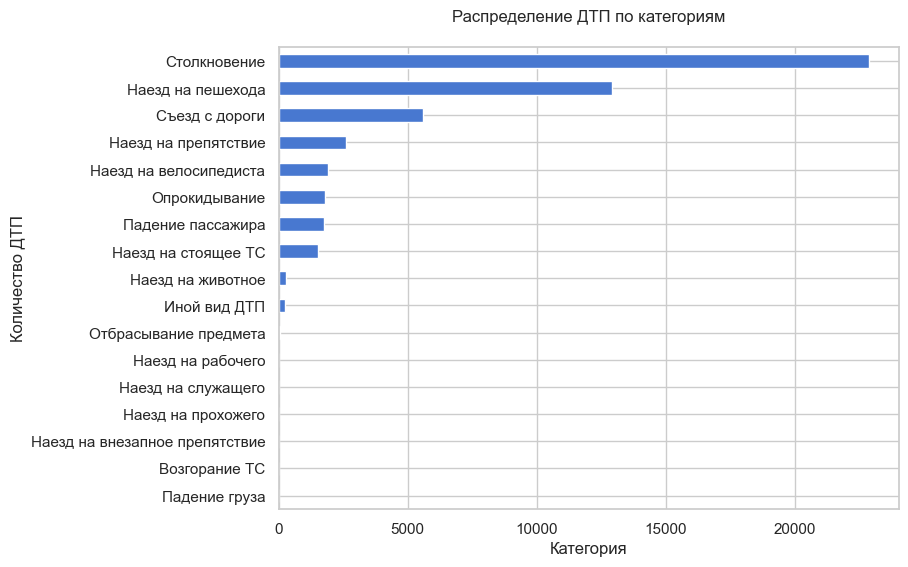

In [110]:
# построим график распределения ДТП по категориям
accidents['category'].value_counts().reset_index().sort_values(by='count', ascending=True).plot(
    y='count',
    x='category',
    kind='barh',
    title='Распределение ДТП по категориям\n',
    xlabel='Категория',
    ylabel='Количество ДТП',
    legend=False,
    figsize=(8, 6)
);

In [111]:
accidents.pivot_table(index='category', values='accident_id', aggfunc='count').sort_values(by='accident_id', ascending=False).reset_index().rename(columns={'accident_id':'count'}).assign(share=lambda x: x['count'] / x['count'].sum())

,category,count,share
0,Столкновение,22868,0.44
1,Наезд на пешехода,12929,0.25
2,Съезд с дороги,5603,0.11
3,Наезд на препятствие,2598,0.05
4,Наезд на велосипедиста,1924,0.04
5,Опрокидывание,1814,0.04
6,Падение пассажира,1777,0.03
7,Наезд на стоящее ТС,1535,0.03
8,Наезд на животное,283,0.01
9,Иной вид ДТП,252,0.00


44% ДТП - столкновения между авто.\
Каждое четвертое происшествие - наезд на пешехода.\
Каждое девятое - транспортное средство вылетело с дороги.

### Дата и время ДТП

Давайте посмотрим на распределение ДТП в зависимости от месяца, дня недели, времени суток.

In [112]:
# посмотрим на распределение ДТП в зависимости от месяца, дня недели, времени суток.
accidents['month'] = accidents['datetime'].dt.month
accidents['day_of_week'] = accidents['datetime'].dt.day_name()
accidents['hour'] = accidents['datetime'].dt.hour
accidents[['month', 'day_of_week', 'hour']].describe()

,month,hour
count,51722.00,51722.00
mean,3.73,13.79
std,1.73,5.61
min,1.00,0.00
25%,2.00,10.00
50%,4.00,14.00
75%,5.00,18.00
max,6.00,23.00


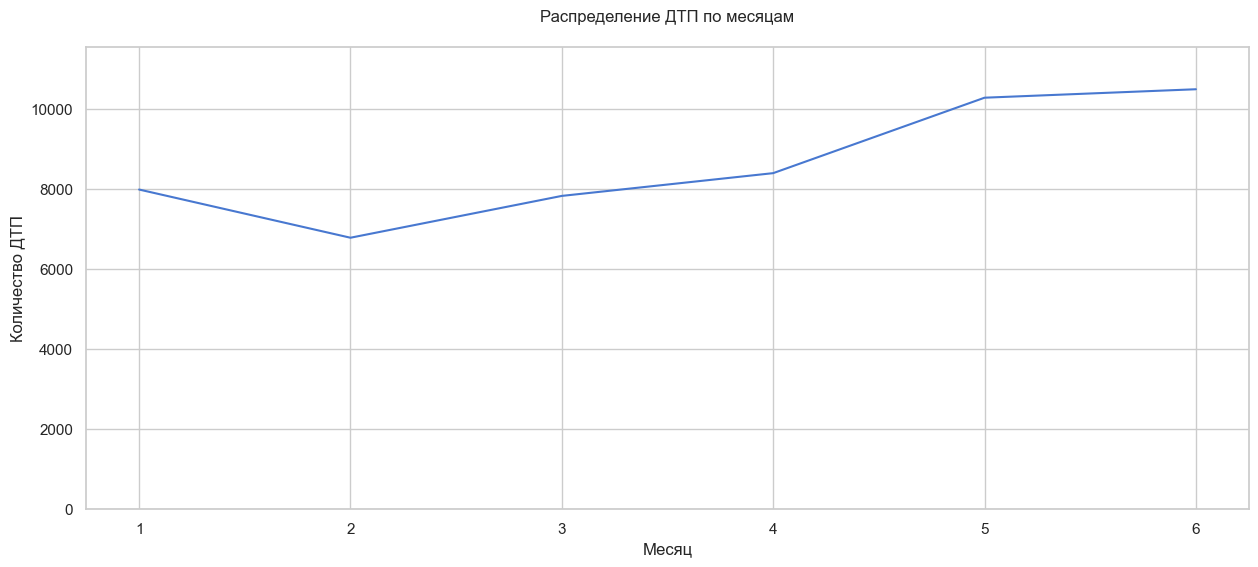

In [113]:
# построим график распределения ДТП по месяцам
accidents['month'].value_counts().sort_index().plot(
    title='Распределение ДТП по месяцам\n',
    xlabel='Месяц',
    ylabel='Количество ДТП',
    legend=False,
    figsize=(15, 6),
    ylim=(0, max(accidents['month'].value_counts()*1.1))
);

В феврале меньше всего ДТП - это может быть из-за того, что месяц короткий.\
В зимние и весенние месяцы меньше аварий.\
Май и июнь - количество аварий вырастает на 25%: с 8000 до 10000.

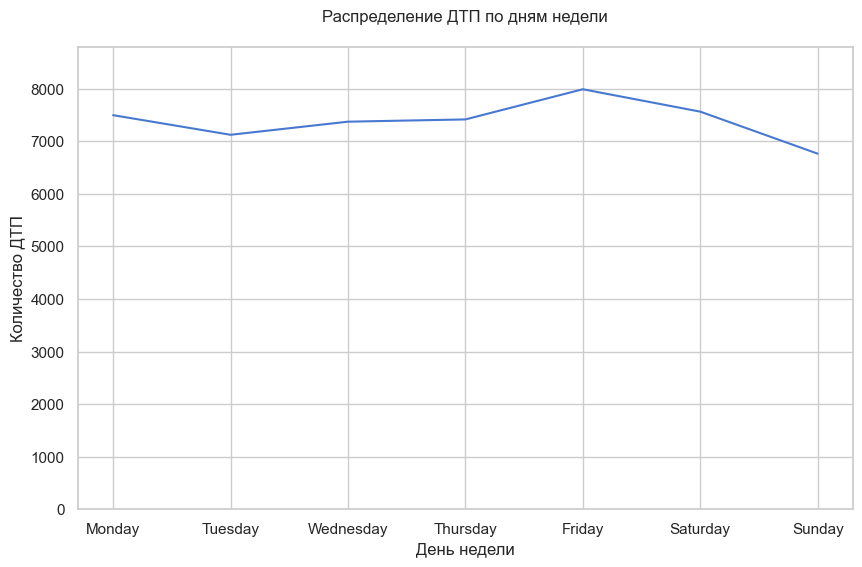

In [114]:
# # построим график распределения ДТП по дням недели
accidents['day_of_week'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(
    title='Распределение ДТП по дням недели\n',
    xlabel='День недели',
    ylabel='Количество ДТП',
    legend=False,
    figsize=(10, 6),
    ylim=(0, max(accidents['day_of_week'].value_counts()*1.1))
);

Понедельник - день тяжелый, как и пятница. Воскресенье - самый спокойный.

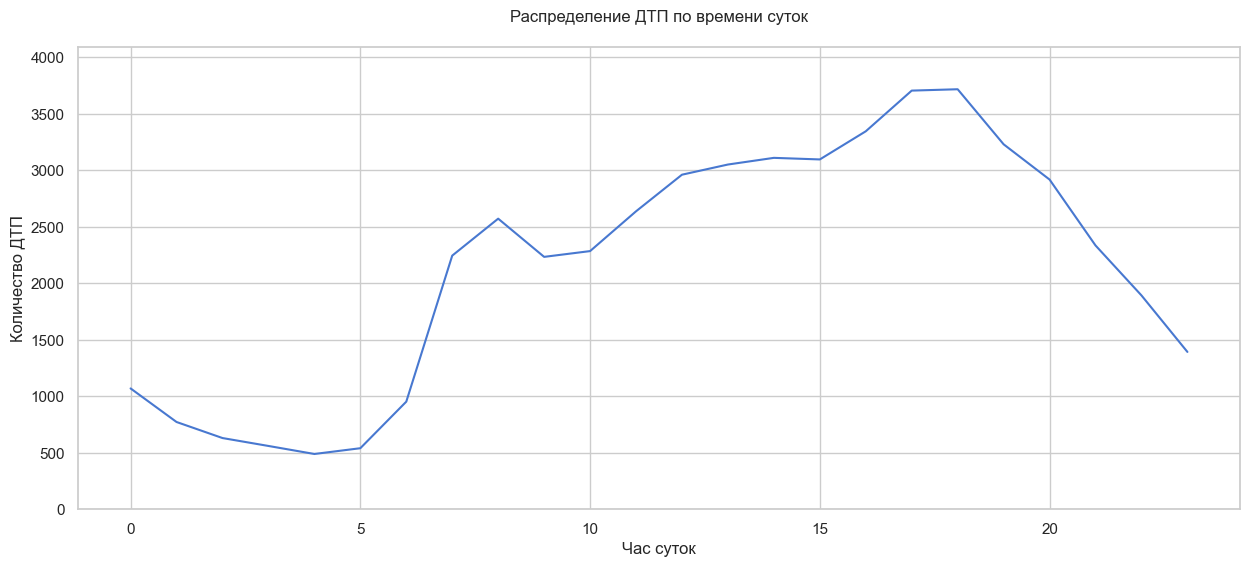

In [115]:
# построим график распределения ДТП по часам суток
accidents['hour'].value_counts().sort_index().plot(
    title='Распределение ДТП по времени суток\n',
    xlabel='Час суток',
    ylabel='Количество ДТП',
    legend=False,
    figsize=(15, 6),
    ylim=(0, max(accidents['hour'].value_counts()*1.1))
);

Наименьшее количество аварий приходится на ночное время - с 23:00 до 06:00.\
В 07-08:00 утра пик, люди едут на работу, больше машин - больше аварий.

In [116]:
# Считаем количество ДТП по часам и категориям
hour_category_counts = accidents.groupby(['hour', 'category']).size().reset_index(name='count')

fig = px.bar(
    hour_category_counts,
    x='hour',
    y='count',
    color='category',
    barmode='stack',
    title='Распределение ДТП по часам суток с разбиением по категориям',
    labels={'hour':'Час суток', 'count':'Количество ДТП', 'category':'Категория ДТП'},
    text_auto=True
)

fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(tickmode='linear', dtick=1, gridcolor='lightgray'),
    yaxis=dict(gridcolor='lightgray')
)

fig.show()

Разделение на категории не дает нам чего-то существенного.

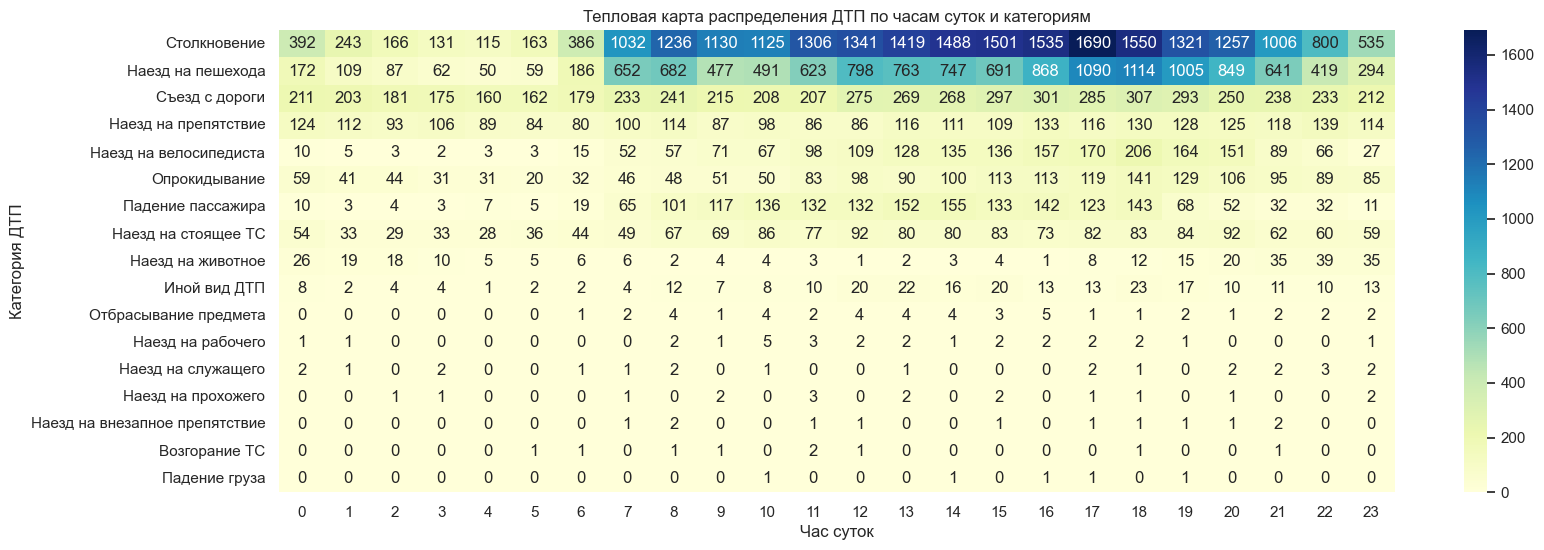

In [117]:
# выделим в каждом столбце hour максимальное значение и построим тепловую карту
heatmap_data = accidents.pivot_table(
    index='category',
    columns='hour',
    values='accident_id',
    aggfunc='count',
).fillna(0)
# построим тепловую карту
ordered_categories = heatmap_data.sum(axis=1).sort_values(ascending=False).index
heatmap_data = heatmap_data.reindex(ordered_categories)
plt.figure(figsize=(18, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Тепловая карта распределения ДТП по часам суток и категориям')
plt.xlabel('Час суток')
plt.ylabel('Категория ДТП')
plt.show()

Из интересного:
- на животных наезжают в основном ночью,  а на стоящие ТС - стабильно все 24 часа.
- велосипедстам и пешеходам нужно быть аккуратнее в светлое время суток - интересно было бы сравнить долю аварий к количеству машин на дороге, чтобы понять, корреляция прямая или на самом деле обратная.
- на количество съездов с дороги также не сильно влияет время суток.

In [118]:
# Таблица сопряжённости с долями
stacked_data = accidents.pivot_table(
    index='hour',
    columns='category',
    values='accident_id',
    aggfunc='count'
).fillna(0)
# Нормализация по строкам (доли)
stacked_data = stacked_data.div(stacked_data.sum(axis=1), axis=0)

# Построение stacked bar chart
fig = go.Figure()

# Добавляем по одной полосе для каждой категории
for category in stacked_data.columns:
    fig.add_trace(go.Bar(
        x=stacked_data.index,
        y=stacked_data[category],
        name=category,
        text=stacked_data[category].round(2),  # Показываем значения с 2 знаками
        textposition='inside'
    ))

# Настраиваем макет
fig.update_layout(
    barmode='stack',  # Режим наложения полос
    title='Доли категорий ДТП по часам суток',
    xaxis_title='Час суток',
    yaxis_title='Доля',
    legend_title='Категория ДТП',
    # legend=dict(x=1.05, y=1, xanchor='left', yanchor='top'),
    template='plotly_white',

)

# Показываем график
fig.show()

На нормированном графике уже лучше видны особенности:
- столкновения и наезды на пешеходов чаще с утра и до вечера, а не ночью. В этой же группе падения пассажира.
- ночью, а особенно с 03 до 05:00, часты съезды с дороги и наезды на препятствие, стоящее ТС.
- доля опрокидываний растет с 22:00 и до 06:00 утра - можно посмотреть, люди какого возраста, сколько человек в машине, что за ТС, есть ли пьяные.

Сравним, есть ли разница в количестве аварий в будни и выходные дни.

Количество аварий по дням и часам:


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
0,136,118,134,123,147,184,227
1,99,72,76,97,96,132,200
2,90,54,74,83,74,107,148
3,54,51,50,73,63,114,155
4,61,41,57,63,61,100,106
5,68,43,78,61,72,101,117
6,150,139,133,136,136,140,118
7,410,385,395,362,341,202,149
8,445,437,432,457,402,230,168


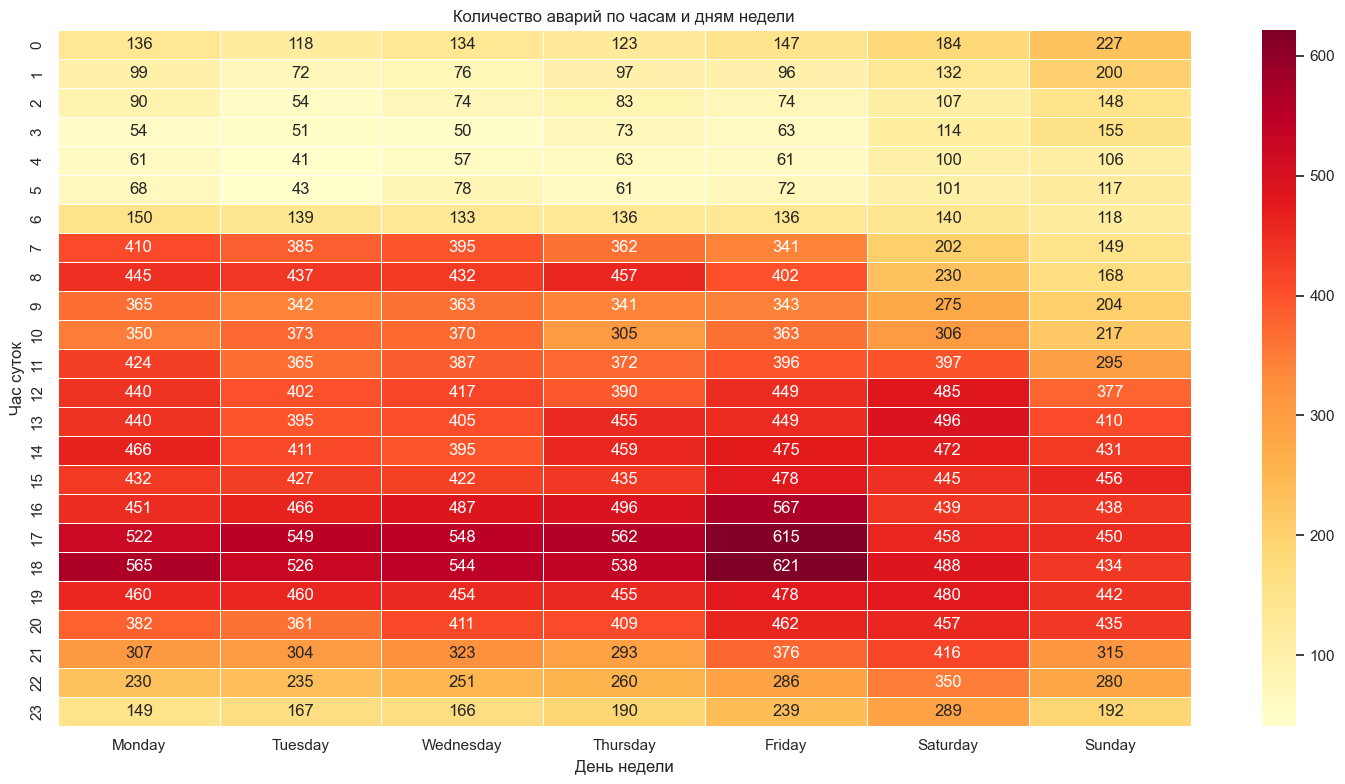

In [119]:
# Группируем по дню недели и часу, считаем количество аварий
hour_day_count = accidents.groupby(['day_of_week', 'hour']).size().reset_index(name='accident_count')

# Сводная таблица: строки — часы, столбцы — дни недели
pivot_table = hour_day_count.pivot(
    index='hour',
    columns='day_of_week',
    values='accident_count'
).fillna(0)

# Порядок дней недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table[day_order]

print('Количество аварий по дням и часам:')
display(pivot_table)

# Тепловая карта, heatmap, для визуализации
plt.figure(figsize=(15,8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)

# Настройки графика
plt.title('Количество аварий по часам и дням недели')
plt.xlabel('День недели')
plt.ylabel('Час суток')
plt.tight_layout()

- В субботу и воскресенье с 0 до 5 часов утра в 2-3 раза больше ДТП, чем в будни.

Количество погибших по дням и часам:


day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
0,22,28,21,24,28,36,33
1,30,14,16,14,20,21,43
2,27,7,15,31,16,25,34
3,11,8,11,17,11,21,27
4,18,6,11,17,13,18,25
5,9,14,20,15,12,20,22
6,16,16,15,20,26,28,20
7,38,38,41,29,38,25,14
8,30,37,28,44,32,30,20


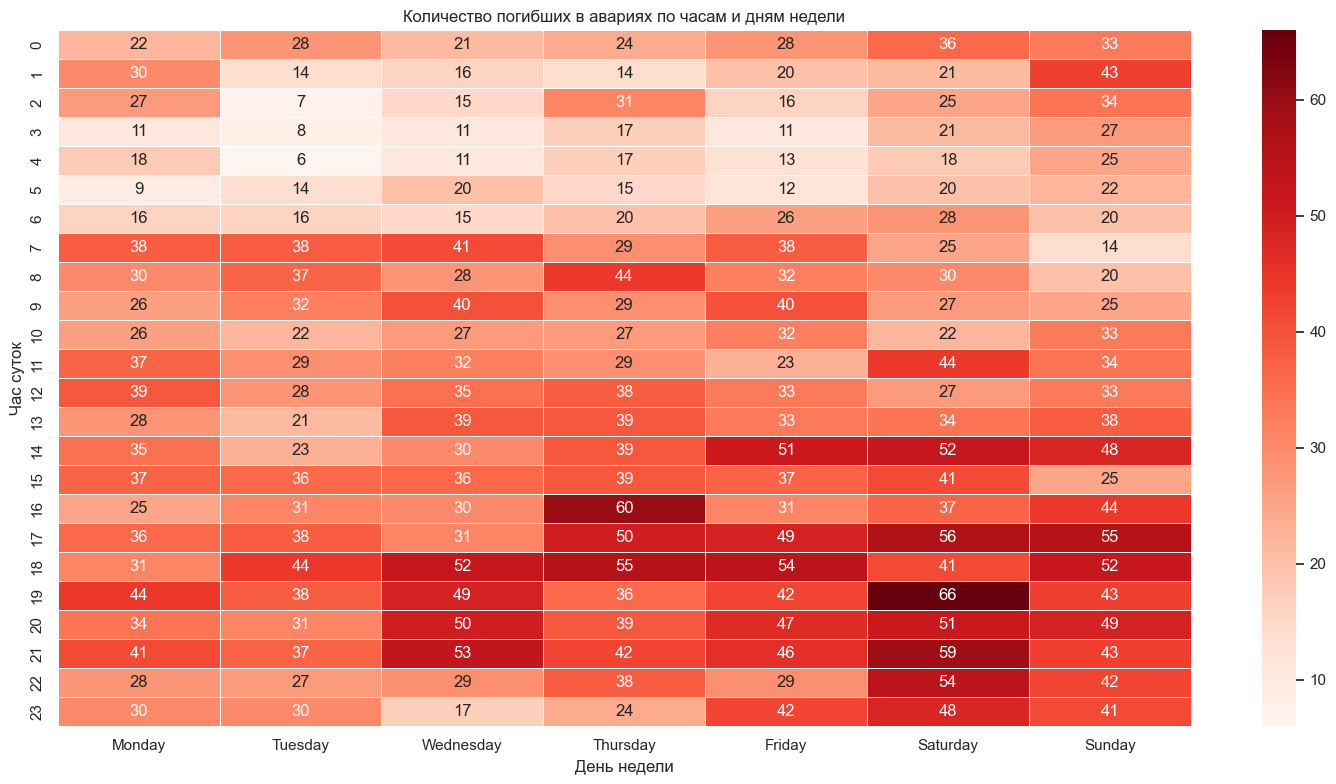

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Группируем по дню недели и часу, считаем сумму dead_count
hour_day_dead = accidents.groupby(['day_of_week', 'hour'])['dead_count'].sum().reset_index(name='total_deaths')

# Сводная таблица: строки — часы, столбцы — дни недели
pivot_table_dead = hour_day_dead.pivot(
    index='hour',
    columns='day_of_week',
    values='total_deaths'
).fillna(0)

# Порядок дней недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table_dead = pivot_table_dead[day_order]

print('Количество погибших по дням и часам:')
display(pivot_table_dead)

# Тепловая карта для погибших
plt.figure(figsize=(15, 8))
sns.heatmap(
    pivot_table_dead,
    annot=True,
    fmt='.0f',
    cmap='Reds',  # Красная схема для акцента на смертях
    linewidths=0.5
)

# Настройки графика
plt.title('Количество погибших в авариях по часам и дням недели')
plt.xlabel('День недели')
plt.ylabel('Час суток')
plt.tight_layout()
plt.show()

### Тяжесть ДТП

Посмотрим, какие у нас данные по тяжести травм

In [121]:
accidents['severity'].value_counts().reset_index().assign(share = lambda x: x['count']/x['count'].sum())

,severity,count,share
0,M,31101,0.60
1,S,16030,0.31
2,F,4591,0.09


- Каждая 11-я авария - с погибшими.
- 60% ДТП - не причинили тяжкого вреда здоровью.

Посмотрим на распределение тяжести в зависимости от категории аварии, от времени суток, от месяца.

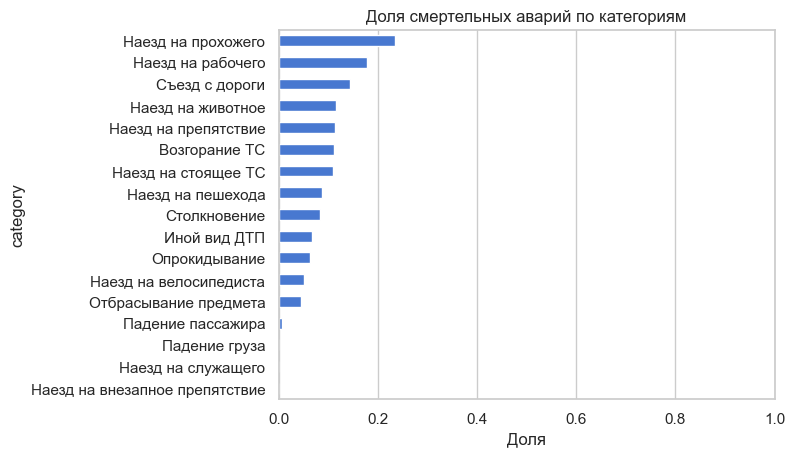

In [122]:
# группируем данные по тяжести и категориям аварий в сводной
accidents.pivot_table(
    index='category',
    columns='severity',
    values='accident_id',
    aggfunc='count',
    fill_value=0
# добавляем столбец с расчетом доли смертельных случаев
).assign(fatal = lambda x: x['F']/x.sum(axis=1)).sort_values(by='fatal', ascending=True).plot(
    y='fatal',
    kind='barh',
    title='Доля смертельных аварий по категориям',
    xlim=(0, 1),
    legend=False,
)

plt.grid(axis='y')
plt.xlabel('Доля');

- Наезд на лица, не являющиеся участниками движения, в 20% случаев приводит к смертельным случаям - кроме случаев, когда лицо несёт службу.
- Съезд с дороги, наезд на животных, препятствия, стоящие ТС в 10% случаев для кого-то фатален.

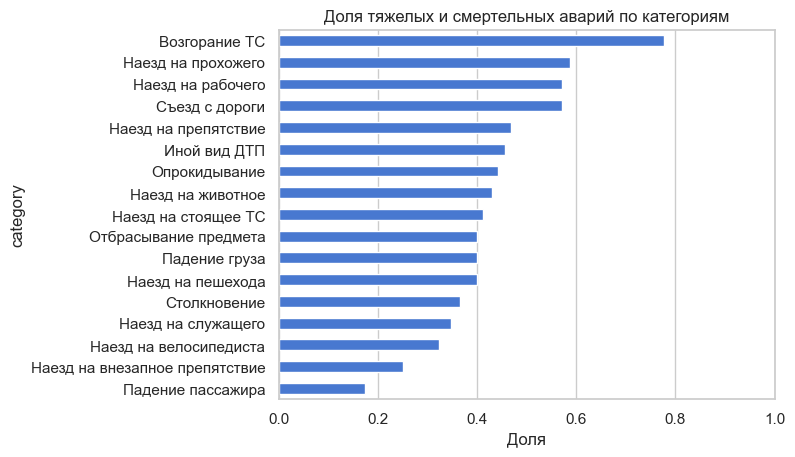

In [123]:
# группируем данные по тяжести и категориям аварий в сводной
accidents.pivot_table(
    index='category',
    columns='severity',
    values='accident_id',
    aggfunc='count',
    fill_value=0
# добавляем столбец с расчетом доли смертельных случаев
).assign(fatal = lambda x: (x['F']+x['S'])/x.sum(axis=1)).sort_values(by='fatal', ascending=True).plot(
    y='fatal',
    kind='barh',
    title='Доля тяжелых и смертельных аварий по категориям',
    xlim=(0, 1),
    legend=False
)

plt.grid(axis='y')
plt.xlabel('Доля');

- Самыми страшными являются возгорания - лишь в одном случае из 5 удается избежать смерти или тяжелых повреждений.
- Съезд с дороги в 60% случаев - с тяжелыми последствиями для здоровья (а не только для машины).
- Рекомендуется не попадать в ДТП, если не являетесь участником дророжного движения - в 2 случаях из 5 это закончится тяжелыми травмами, а в 1 - смертью.

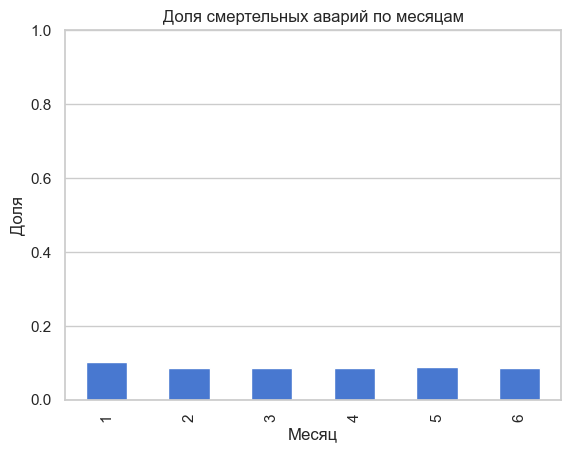

In [124]:
# группируем данные по тяжести и месяцам аварий в сводной
accidents.pivot_table(
    index='month',
    columns='severity',
    values='accident_id',
    aggfunc='count',
    fill_value=0
# добавляем столбец с расчетом доли смертельных случаев
).assign(fatal = lambda x: x['F']/x.sum(axis=1)).sort_values(by='month', ascending=True).plot(
    y='fatal',
    kind='bar',
    title='Доля смертельных аварий по месяцам',
    ylim=(0, 1),
    legend=False,
)

plt.grid(axis='x')
plt.xlabel('Месяц')
plt.ylabel('Доля');

Значимой разницы по доле смертельных случаев в зависимости от месяца обнаружено не было.

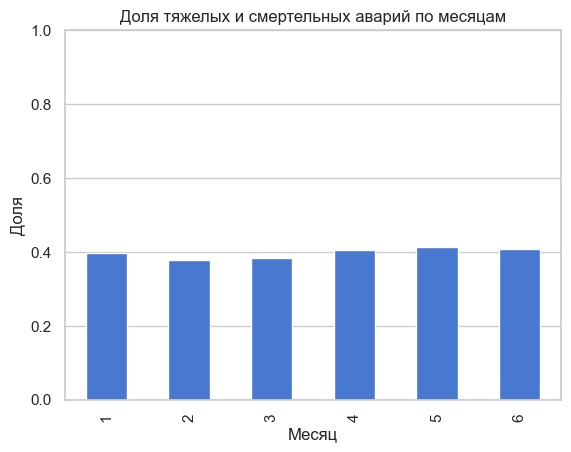

In [125]:
# группируем данные по тяжести и месяцам аварий в сводной
accidents.pivot_table(
    index='month',
    columns='severity',
    values='accident_id',
    aggfunc='count',
    fill_value=0
# добавляем столбец с расчетом доли смертельных случаев
).assign(fatal = lambda x: (x['F']+x['S'])/x.sum(axis=1)).sort_values(by='month', ascending=True).plot(
    y='fatal',
    kind='bar',
    title='Доля тяжелых и смертельных аварий по месяцам',
    ylim=(0, 1),
    legend=False,
)

plt.grid(axis='x')
plt.xlabel('Месяц')
plt.ylabel('Доля');

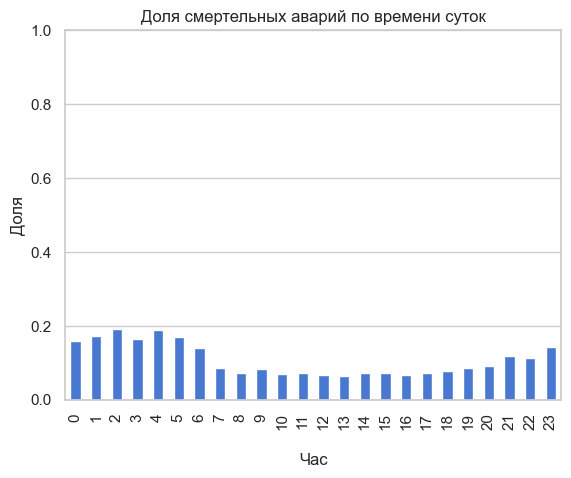

In [126]:
# группируем данные по тяжести и месяцам аварий в сводной
accidents.pivot_table(
    index='hour',
    columns='severity',
    values='accident_id',
    aggfunc='count',
    fill_value=0
# добавляем столбец с расчетом доли смертельных случаев
).assign(fatal = lambda x: x['F']/x.sum(axis=1)).sort_values(by='hour', ascending=True).plot(
    y='fatal',
    kind='bar',
    title='Доля смертельных аварий по времени суток',
    ylim=(0, 1),
    legend=False,
)

plt.grid(axis='x')
plt.xlabel('\nЧас')
plt.ylabel('Доля');

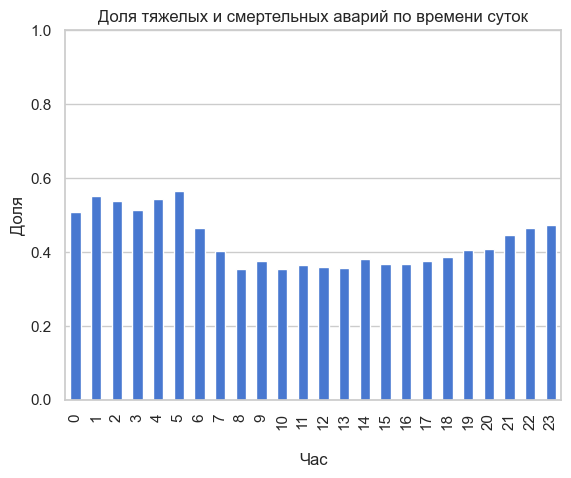

In [127]:
# группируем данные по тяжести и месяцам аварий в сводной
accidents.pivot_table(
    index='hour',
    columns='severity',
    values='accident_id',
    aggfunc='count',
    fill_value=0
# добавляем столбец с расчетом доли смертельных случаев
).assign(fatal = lambda x: (x['F']+x['S'])/x.sum(axis=1)).sort_values(by='hour', ascending=True).plot(
    y='fatal',
    kind='bar',
    title='Доля тяжелых и смертельных аварий по времени суток',
    ylim=(0, 1),
    legend=False,
)

plt.grid(axis='x')
plt.xlabel('\nЧас')
plt.ylabel('Доля');

Мы видим, что ночью ДТП более серьезные по последствиям. Вместо общего значения 35-40% - доля тяжелых вместе со смертельными доходит до 55% в 01-05:00.

### Количество погибших в ДТП

In [128]:
accidents['dead_count'].value_counts().reset_index()

,dead_count,count
0,0,47131
1,1,4016
2,2,446
3,3,83
4,4,29
5,5,10
6,6,5
7,7,2


In [129]:
accidents.pivot_table(
    index='category',
    values='dead_count',
    aggfunc='sum'
).sort_values('dead_count', ascending=False).assign(share = lambda x: x['dead_count']/x['dead_count'].sum())

,dead_count,share
category,,
Столкновение,2459,0.46
Наезд на пешехода,1166,0.22
Съезд с дороги,893,0.17
Наезд на препятствие,331,0.06
Наезд на стоящее ТС,215,0.04
Опрокидывание,123,0.02
Наезд на велосипедиста,97,0.02
Наезд на животное,42,0.01
Иной вид ДТП,17,0.00


- Больше всего погибло людей в столкновениях - 46% смертей от общего количества погибших.
- В наездах на пешехода - еще 22%.
- Третье по количеству смертей - съезд с дороги.

### Количество получивших травмы в ДТП

In [130]:
accidents.pivot_table(
    index='category',
    values='injured_count',
    aggfunc='sum'
).sort_values('injured_count', ascending=False).assign(share = lambda x: x['injured_count']/x['injured_count'].sum())

,injured_count,share
category,,
Столкновение,32927,0.51
Наезд на пешехода,12384,0.19
Съезд с дороги,7190,0.11
Наезд на препятствие,3245,0.05
Наезд на стоящее ТС,2068,0.03
Опрокидывание,1973,0.03
Падение пассажира,1877,0.03
Наезд на велосипедиста,1867,0.03
Наезд на животное,338,0.01


- Половина из людей, получивших травмы при ДТП, получила их в результате столкновения.

### Количество участников ДТП

Посмотрим на количество участников в ДТП.

In [131]:
accidents['participants_count'].describe()

count   51722.00
mean        2.45
std         1.20
min         1.00
25%         2.00
50%         2.00
75%         3.00
max        45.00
Name: participants_count, dtype: float64

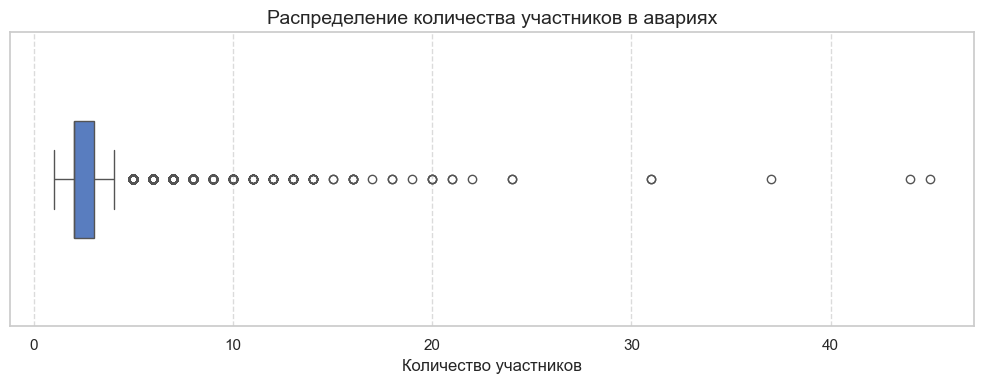

In [132]:
plt.figure(figsize=(10, 4))  # Установим размер графика
sns.boxplot(data=accidents, x='participants_count', width=0.4)
plt.title('Распределение количества участников в авариях', fontsize=14)
plt.xlabel('Количество участников')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)  # Сетка для читаемости
plt.tight_layout()  # Оптимизирует отступы
plt.show()

- Основная масса (между Q1 и Q3) аварий - при участии 2-3 человек.
- Среднее количество участников - 2.45.

Посмотрим, что собой представляют ДТП с большим количество участников (0.1% аварий)

In [133]:
data = accidents.loc[accidents['participants_count']>accidents['participants_count'].quantile(.999)]

# Создаём отчёт по DataFrame
profile = ProfileReport(data, title="Отчёт по данным", explorative=True)

# Показываем в Jupyter
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 998.22it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

- Большинство крупных аварий происходит в светлое время суток (38/49).
- 36% со смертельными случаями - выше, чем в среднем (9%).
- есть средняя корреляция между количеством участников и пострадавших.

Посмотрим на количество участников ДТП по категориям.

In [134]:
summary = (
    accidents.pivot_table(
        index='category',
        values=['participants_count', 'injured_count', 'dead_count'],
        aggfunc='sum'
    )
    # сортируем по числу участников
    .sort_values('participants_count', ascending=False)
    # добавляем новые столбцы
    .assign(
        fatal=lambda x: x['dead_count'] / x['participants_count'],  # доля погибших
        affected=lambda x: (x['injured_count'] + x['dead_count']) / x['participants_count']  # доля пострадавших
    )
)#
summary.head(10).sort_values('affected', ascending=False)

,dead_count,injured_count,participants_count,fatal,affected
category,,,,,
Опрокидывание,123,1973,2551,0.05,0.82
Съезд с дороги,893,7190,10539,0.08,0.77
Наезд на препятствие,331,3245,4715,0.07,0.76
Наезд на животное,42,338,541,0.08,0.70
Иной вид ДТП,17,254,472,0.04,0.57
Наезд на стоящее ТС,215,2068,4297,0.05,0.53
Столкновение,2459,32927,68236,0.04,0.52
Наезд на пешехода,1166,12384,26962,0.04,0.50
Наезд на велосипедиста,97,1867,3936,0.02,0.50


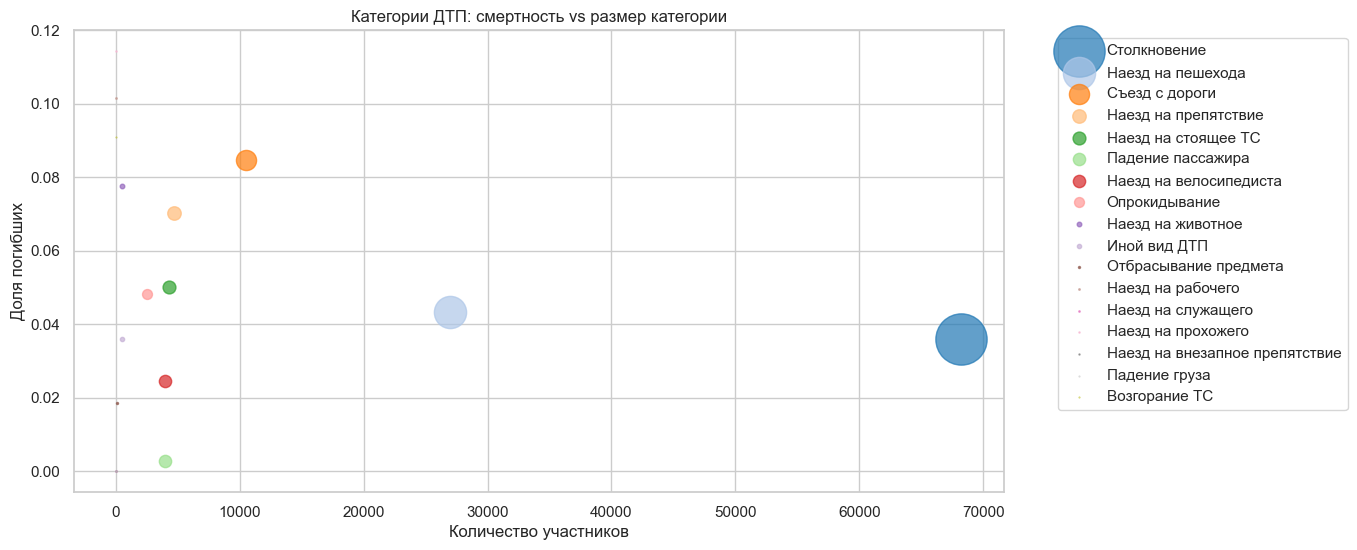

In [135]:
# Сортируем, чтобы цвета были стабильными
summary = summary.sort_values('participants_count', ascending=False)

plt.figure(figsize=(12, 6))

# Палитра для категорий
palette = sns.color_palette("tab20", n_colors=len(summary))

for i, (cat, row) in enumerate(summary.iterrows()):
    plt.scatter(
        row['participants_count'],  # X = количество участников
        row['fatal'],               # Y = доля погибших
        s=row['participants_count'] / 50,  # размер пузыря
        color=palette[i],
        alpha=0.7,
        label=cat
    )

plt.xlabel("Количество участников")
plt.ylabel("Доля погибших")
plt.title("Категории ДТП: смертность vs размер категории")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

- Падение пассажира наиболее безопасно.
- В съезде с дороги один из самых больших шансов умереть.
- В столкновения больше всего участников и средняя среди всех опасность.

### Погода при ДТП

Посмотрим, когда чаще происходят аварии.

In [136]:
accidents['weather_str'].value_counts().reset_index()

,weather_str,count
0,Ясно,32779
1,Пасмурно,14452
2,Дождь,1798
3,Снегопад,1766
4,"Пасмурно, Снегопад",265
5,"Пасмурно, Дождь",197
6,Туман,131
7,Метель,103
8,"Ясно, Температура выше +30С",52
9,"Ясно, Температура ниже -30С",46


- Лидирует ясная погода. И в 2 раза меньше при пасмурной погоде.
- В дождь и в снегопад ДТП в 20 раз реже, чем при ясной погоде.

In [137]:
# Общее количество аварий по погоде
total_by_weather = accidents['weather_str'].value_counts().reset_index()
total_by_weather.columns = ['weather', 'total_count']

# Количество смертельных аварий по погоде
fatal_by_weather = accidents[accidents['severity'] == 'F']['weather_str'].value_counts().reset_index()
fatal_by_weather.columns = ['weather', 'fatal_count']

# Объединяем и считаем долю
pivot = total_by_weather.merge(fatal_by_weather, on='weather', how='left').fillna(0)
pivot['fatal_share'] = pivot['fatal_count'] / pivot['total_count'] * 100
pivot = pivot.sort_values(by='fatal_share', ascending=False)
treshold = 100
pivot = pivot[pivot['total_count']>treshold]
pivot[['weather', 'total_count', 'fatal_count', 'fatal_share']]

,weather,total_count,fatal_count,fatal_share
6,Туман,131,27.00,20.61
7,Метель,103,18.00,17.48
2,Дождь,1798,213.00,11.85
4,"Пасмурно, Снегопад",265,29.00,10.94
3,Снегопад,1766,182.00,10.31
5,"Пасмурно, Дождь",197,19.00,9.64
0,Ясно,32779,2866.00,8.74
1,Пасмурно,14452,1209.00,8.37


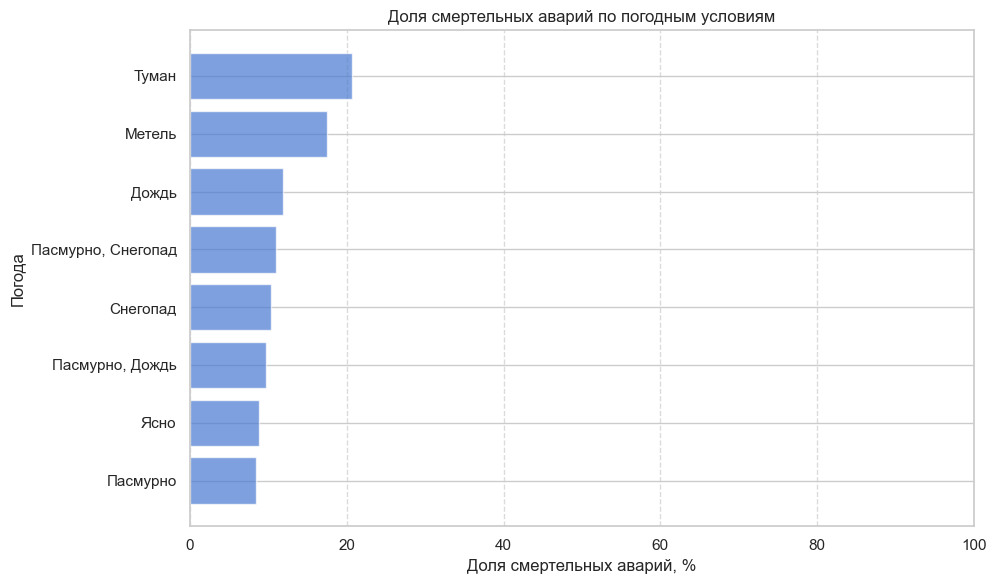

In [138]:
pivot = pivot.sort_values(by='fatal_share', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(pivot['weather'], pivot['fatal_share'], alpha=0.7)
plt.xlabel('Доля смертельных аварий, %')
plt.ylabel('Погода')
plt.title('Доля смертельных аварий по погодным условиям')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xlim(0, 100)
plt.show()

- Хоть при ясной погоде и часты ДТП, но доля смертельных случаев одна из самых низких.
- Самые опасные - ДТП в **тумане**, 20% со смертельным исходом.
- Далее идут **метель** (17%) и **дождь** (12%).

### Категории участников ДТП

In [139]:
accidents['participant_categories_str'].value_counts().reset_index().assign(
    proportion = lambda x: x['count']/x['count'].sum()*100
)

,participant_categories_str,count,proportion
0,B,30640,59.24
1,BP,12765,24.68
2,BM,5247,10.14
3,BV,2003,3.87
4,BPM,411,0.79
5,BO,351,0.68
6,BPV,139,0.27
7,BVM,87,0.17
8,BPO,71,0.14
9,BMO,4,0.01


- 25% ДТП происходит с участием **пешеходов**.
- 10% - с **мотоциклистами**.
- **Велосипедисты** участвуют в менее чем 4% ДТП.

### Транспортные средства

In [140]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82873 entries, 0 to 82895
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   year         79889 non-null  Int64         
 1   brand        79739 non-null  object        
 2   color        80609 non-null  object        
 3   model        79739 non-null  object        
 4   category     82873 non-null  object        
 5   accident_id  82873 non-null  int64         
 6   vehicle_id   82873 non-null  int64         
 7   datetime     82873 non-null  datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), int64(2), object(4)
memory usage: 5.8+ MB


Рассмотрим датасет с транспортными средствами.

### Год выпуска ТС

Посмотрим на год выпуска

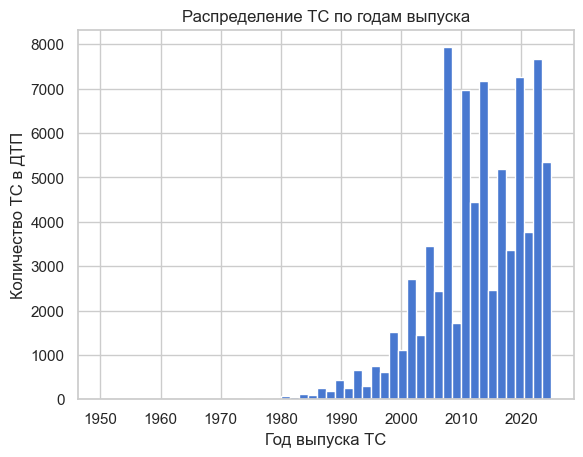

In [141]:
vehicles['year'].hist(bins=50)
plt.xlabel('Год выпуска ТС')
plt.ylabel('Количество ТС в ДТП')
plt.title('Распределение ТС по годам выпуска');

In [142]:
vehicles['year'].describe()

count   79889.00
mean     2012.63
std         8.43
min      1950.00
25%      2007.00
50%      2013.00
75%      2020.00
max      2025.00
Name: year, dtype: Float64

- Минимум - 1950 год выпуска.
- Основная масса ТС, участвующих в ДТП - 2007-2020 годов выпуска.
- Новые авто текущего года тоже попадают в аварии.

В целях нашего исследования и возможности сравнивать данные разных годов, лучше будет добавить срок службы автомобиля.

In [143]:
vehicles['service_life'] = (vehicles['datetime'].dt.year - pd.to_numeric(vehicles['year'], errors='coerce')).astype('Int64')

In [144]:
display(vehicles['service_life'].describe())
print(f"Пропусков в сроке службы: {vehicles[vehicles['service_life'].isna()]['year'].isna().sum()}")  # Пропуски в service_life из-за year

count   79889.00
mean       12.37
std         8.43
min         0.00
25%         5.00
50%        12.00
75%        18.00
max        75.00
Name: service_life, dtype: Float64

Пропусков в сроке службы: 2984


### Бренд (марка) ТС

In [145]:
vehicles.pivot_table(
    index='brand',
    values=['vehicle_id', 'year'],
    aggfunc= {'vehicle_id':'count', 'year': 'mean'}
).rename(columns={'vehicle_id':'count', 'year':'mean_year'}).sort_values(by='count', ascending=False).reset_index().head(15)

,brand,count,mean_year
0,ВАЗ,15270,2011.63
1,TOYOTA,6735,2006.24
2,Прочие марки ТС,4361,2019.84
3,HYUNDAI,4096,2014.06
4,KIA,3966,2015.09
5,RENAULT,2834,2013.44
6,NISSAN,2802,2008.86
7,VOLKSWAGEN,2598,2012.40
8,ГАЗ,2307,2013.43
9,HONDA,2171,2006.09


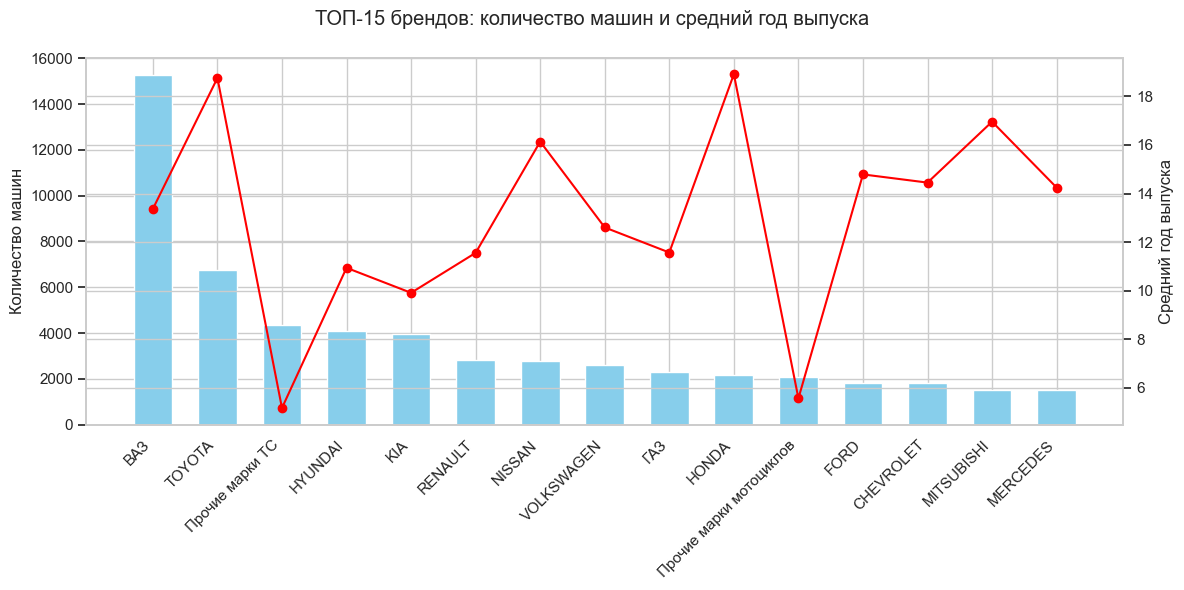

In [146]:
brand_stats = (
    vehicles.pivot_table(
        index='brand',
        values=['vehicle_id', 'service_life'],
        aggfunc={'vehicle_id':'count', 'service_life': 'mean'}
    )
    .rename(columns={'vehicle_id':'count', 'service_life':'mean_year'})
    .sort_values(by='count', ascending=False)
    .reset_index()
    .head(15)
)

fig, ax1 = plt.subplots(figsize=(12, 6))

x = np.arange(len(brand_stats))
width = 0.6

# Бар — количество машин
ax1.bar(x, brand_stats['count'], width, color='skyblue', label='Количество машин')
ax1.set_ylabel('Количество машин')
ax1.set_xticks(x)
ax1.set_xticklabels(brand_stats['brand'], rotation=45, ha='right')

# Линия — средний год выпуска на второй оси
ax2 = ax1.twinx()
ax2.plot(x, brand_stats['mean_year'], color='red', marker='o', label='Средний год выпуска')
ax2.set_ylabel('Средний год выпуска')

fig.suptitle('ТОП-15 брендов: количество машин и средний год выпуска')
fig.tight_layout()
plt.show()


- Много старых ВАЗов (2012), еще более старые Тойоты и Хонды (2006).
- среди новых (2020) - неизвестные марки ТС и мотоциклов.

Сравним, как часто они попадают в авто в зависимости от имеющихся на руках.\
Данные взяты из отчета ["Автостат Инфо"](<https://t.me/AvtostatInfo/3031>)

In [147]:
try:
    dotenv.load_dotenv()
    google_link = os.getenv('google_link')
except Exception as e:
    print(f"Ошибка при получении ссылки из переменных окружения: {e}")
    google_link = 'https://docs.google.com/spreadsheets/d/1O3psQcKSAjQdUMZCFFWc8pXy1KneMbfY/edit?usp=sharing&ouid=109184268841423500889&rtpof=true&sd=true'
# Преобразуем ссылку для прямой загрузки
file_id = google_link.split('/')[-2]
path_2 = f'https://drive.google.com/uc?id={file_id}'

stat_data = pd.read_excel(path_2)
stat_data.sample(3)

,brand,count
26,SUBARU,332371
24,LEXUS,359443
0,ВАЗ,12399550


In [148]:
stat_data = (
    vehicles.pivot_table(
        index='brand',
        values=['vehicle_id', 'service_life'],
        aggfunc= {'vehicle_id':'count', 'service_life': 'mean'}
    )
    .rename(columns={'vehicle_id':'count', 'service_life':'mean_year'})
    .sort_values(by='count', ascending=False)
    .reset_index()
).merge(stat_data, on='brand', how='inner')
stat_data = stat_data.rename(columns={
    'count_x': 'vehicle_count',       # количество машин в нашем датафрейме - в ДТП
    'mean_year': 'mean_year',         # средний год выпуска
    'count_y': 'total_count'          # суммарное количество (на руках у населения)
})
stat_data

,brand,mean_year,vehicle_count,total_count
0,ВАЗ,13.37,15270,12399550
1,TOYOTA,18.76,6735,3991279
2,HYUNDAI,10.94,4096,2359078
3,KIA,9.91,3966,2677890
4,RENAULT,11.56,2834,2177412
5,NISSAN,16.14,2802,2165461
6,VOLKSWAGEN,12.60,2598,1838252
7,ГАЗ,11.57,2307,460728
8,HONDA,18.91,2171,955921
9,FORD,14.79,1837,1347290


In [149]:
stat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          27 non-null     object 
 1   mean_year      27 non-null     Float64
 2   vehicle_count  27 non-null     int64  
 3   total_count    27 non-null     int64  
dtypes: Float64(1), int64(2), object(1)
memory usage: 1023.0+ bytes


Посчитаем долю ДТП на общее количество автомобилей на руках.

In [150]:
stat_data['share(%)'] = stat_data['vehicle_count']/stat_data['total_count']*100
stat_data.sort_values(by='share(%)', ascending=False)

,brand,mean_year,vehicle_count,total_count,share(%)
7,ГАЗ,11.57,2307,460728,0.50
8,HONDA,18.91,2171,955921,0.23
12,MERCEDES,14.24,1495,771733,0.19
2,HYUNDAI,10.94,4096,2359078,0.17
1,TOYOTA,18.76,6735,3991279,0.17
18,GEELY,3.99,777,467031,0.17
20,SUZUKI,17.35,738,450339,0.16
26,PEUGEOT,15.05,423,277603,0.15
3,KIA,9.91,3966,2677890,0.15
21,УАЗ,11.08,728,503279,0.14


Посмотрим на долю ДТП среди самых популярных марок.

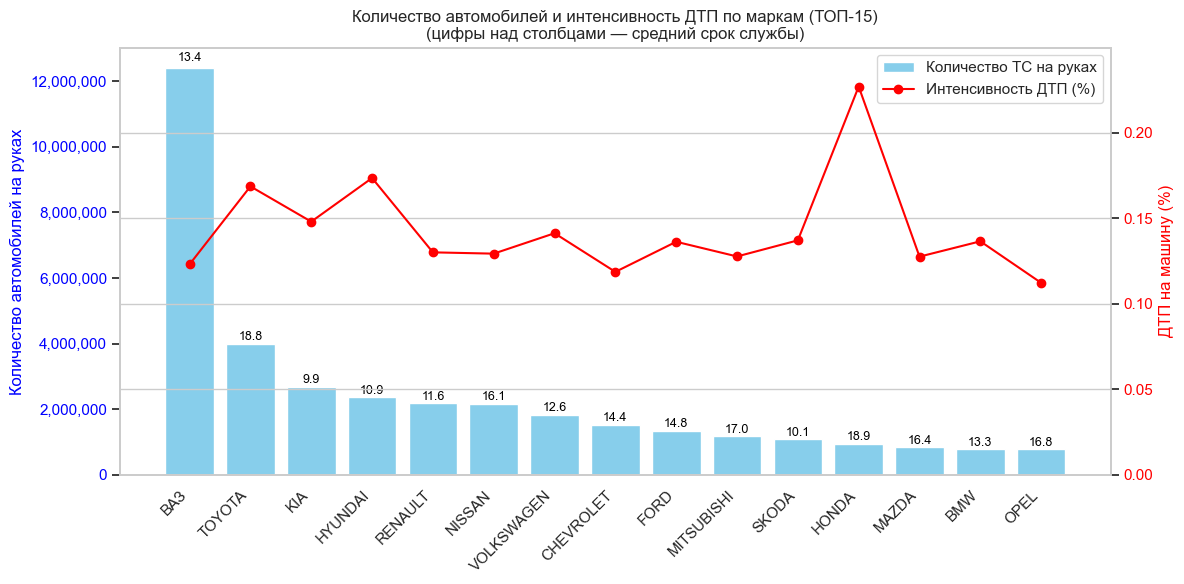

In [151]:
fig, ax1 = plt.subplots(figsize=(12,6))

stat_data_sorted = stat_data.sort_values('total_count', ascending=False).head(15)

# Столбцы — количество ДТП
ax1.bar(stat_data_sorted['brand'], stat_data_sorted['total_count'], color='skyblue', label='Количество ТС на руках')
ax1.set_ylabel('Количество автомобилей на руках', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.grid(False)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')); # Формат без экспоненты
# Линия — интенсивность ДТП
ax2 = ax1.twinx()
ax2.plot(stat_data_sorted['brand'], stat_data_sorted['share(%)'], color='red', marker='o', label='Интенсивность ДТП (%)')
ax2.set_ylabel('ДТП на машину (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, stat_data_sorted['share(%)'].max() * 1.1)

# Ось X
ax1.set_xticks(range(len(stat_data_sorted['brand'])))
ax1.set_xticklabels(stat_data_sorted['brand'], rotation=45, ha='right')

# Легенда
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper right')

plt.title('Количество автомобилей и интенсивность ДТП по маркам (ТОП-15)\n(цифры над столбцами — средний срок службы)', fontsize=12)
fig.tight_layout()
for i, year in enumerate(stat_data_sorted['mean_year']):
    ax1.text(i, stat_data_sorted['total_count'].iloc[i] * 1.01, f'{(year):.1f}', 
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()

Среди популярных брендов:
- чаще всего ДТП у HONDA. При этом в основном это старые автомобили - средний год выпуска - 2006-й. Далее идут Toyota того же года выпуска. Это примерно 2 ДТП на 1000 автомобилей.
- HYUNDAI в тройке по доле ДТП. Это уже более новые автомобили - 2014 года в среднем.
- Судя по данному графику - в ДТП участвуют в основном старые автомобили.


Теперь отсортируем по количеству ДТП. Посмотрим на те бренды, которые чаще всего оказываются в ДТП и сравним доли.

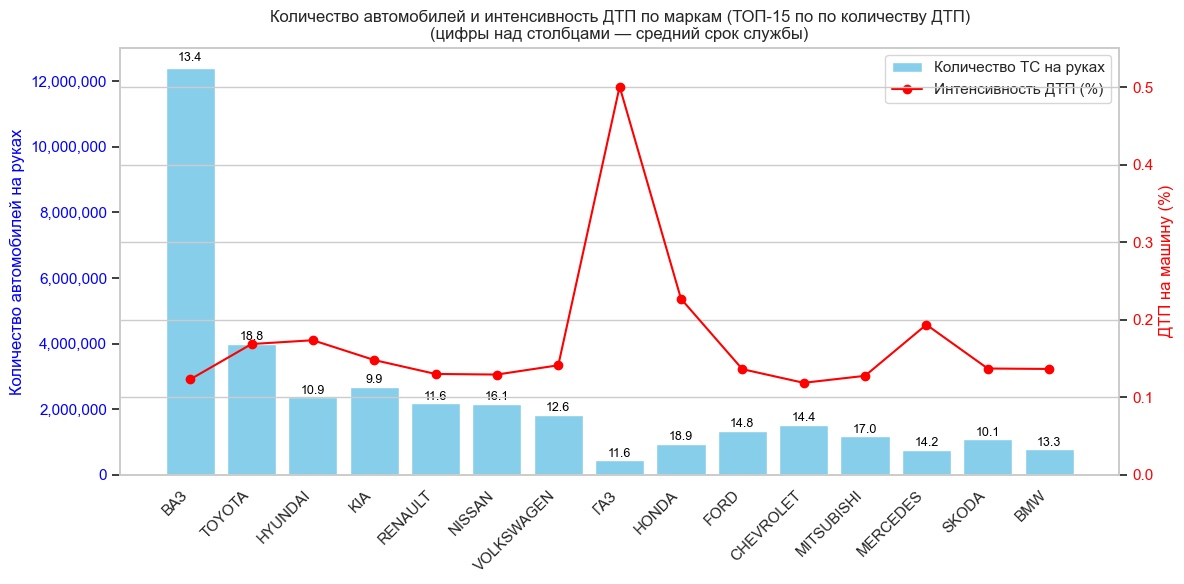

In [152]:
fig, ax1 = plt.subplots(figsize=(12,6))

stat_data_sorted = stat_data.sort_values('vehicle_count', ascending=False).head(15)

# Столбцы — количество ДТП
ax1.bar(stat_data_sorted['brand'], stat_data_sorted['total_count'], color='skyblue', label='Количество ТС на руках')
ax1.set_ylabel('Количество автомобилей на руках', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.grid(False)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')); # Формат без экспоненты
# Линия — интенсивность ДТП
ax2 = ax1.twinx()
ax2.plot(stat_data_sorted['brand'], stat_data_sorted['share(%)'], color='red', marker='o', label='Интенсивность ДТП (%)')
ax2.set_ylabel('ДТП на машину (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, stat_data_sorted['share(%)'].max() * 1.1)

# Ось X
ax1.set_xticks(range(len(stat_data_sorted['brand'])))
ax1.set_xticklabels(stat_data_sorted['brand'], rotation=45, ha='right')

# Легенда
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper right')

plt.title('Количество автомобилей и интенсивность ДТП по маркам (ТОП-15 по по количеству ДТП)\n(цифры над столбцами — средний срок службы)', fontsize=12)
fig.tight_layout()
for i, year in enumerate(stat_data_sorted['mean_year']):
    ax1.text(i, stat_data_sorted['total_count'].iloc[i] * 1.01, f'{(year):.1f}', 
             ha='center', va='bottom', fontsize=9, rotation=0, color='black')

plt.show()

- В тройке тех, где чаще всего ДТП - ГАЗ, HONDA и MERCEDES. C ГАЗ - интересно, это аномалия, искажение этого года или объективная информация. Первая же статья [Эти машины чаще всего разбивали в «тотал» в 2025 году. Черный список - Autonews](<https://www.autonews.ru/news/68821b9a9a794769ae723974>) говорит, что страховые компании считают также - ГАЗ в списке риска.

Мы поняли, каковы наши шансы на ДТП в зависимости от автомобиля.\
Нам интересно, какова вероятность выжить (погибнуть?) в автомобилях разных марок.\
Объединим данные и посчитаем шансы.

In [153]:
# посмотрим, что с чем объединяем
vehicles.sample()

,year,brand,color,model,category,accident_id,vehicle_id,datetime,service_life
47390,2016,DAF,Зеленый,Прочие модели DAF,C,1515245,47390,2025-06-21 17:08:00,9


In [154]:
participants.head()

,role,gender,violations,health_status,years_of_driving_experience,accident_id,vehicle_id
0,Водитель,М,"[Выезд на встречку, Нарушение правил обгона, Отсутствие необходимых документов]",N,20,188743,0
1,Водитель,М,[],N,10,188743,1
2,Водитель,М,"[Водитель пьян, Нет прав]",F,<NA>,188743,2
3,Водитель,М,[Нарушение условий движения задним ходом],N,25,883957,3
4,Водитель,М,[Нарушение расположения ТС],N,17,1505787,4


In [155]:
participants['health_status'].value_counts()

health_status
N    56902
M    43501
S    20809
F     5370
Name: count, dtype: int64

In [156]:
# 1. Объединение
df = participants.merge(vehicles[['vehicle_id', 'brand']], on='vehicle_id', how='left')

# 2. Флаги
df['is_driver'] = df['role'] == 'Водитель'
df['is_dead'] = df['health_status'] == 'F'
df['is_serious'] = df['health_status'] == 'S'

# 3. Группировка на уровне машины
agg_vehicle = df.groupby(['vehicle_id', 'brand']).agg(
    total_people=('health_status', 'count'),
    dead_any=('is_dead', 'max'),      # 1 если есть хотя бы один F
    serious_any=('is_serious', 'max'),
    dead_count=('is_dead', 'sum'),
    serious_count=('is_serious', 'sum'),
    driver_dead=('is_dead', lambda x: int((df.loc[x.index, 'is_driver'] & x).any()))
).reset_index()

# 4. Группировка по бренду
agg_brand = agg_vehicle.groupby('brand').agg(
    vehicles=('vehicle_id', 'nunique'),
    people_total=('total_people', 'sum'),
    deaths_total=('dead_count', 'sum'),
    serious_total=('serious_count', 'sum'),
    vehicles_with_death=('dead_any', 'sum'),
    vehicles_with_serious=('serious_any', 'sum'),
    driver_deaths=('driver_dead', 'sum')
)

# 5. Вероятности
agg_brand['p_death_any'] = agg_brand['vehicles_with_death'] / agg_brand['vehicles']
agg_brand['p_driver_death'] = agg_brand['driver_deaths'] / agg_brand['vehicles']


In [157]:
agg_brand['F+S'] = agg_brand['vehicles_with_death'] + agg_brand['vehicles_with_serious']
agg_brand['p_F_or_S'] = agg_brand['F+S'] / agg_brand['vehicles']
agg_brand.sort_values(by='vehicles', ascending=False).head(20)

,vehicles,people_total,deaths_total,serious_total,vehicles_with_death,vehicles_with_serious,driver_deaths,p_death_any,p_driver_death,F+S,p_F_or_S
brand,,,,,,,,,,,
ВАЗ,15270,22480,1272,4131,1032,3254,787,0.07,0.05,4286,0.28
TOYOTA,6735,9542,321,1194,270,950,188,0.04,0.03,1220,0.18
Прочие марки ТС,4361,5154,157,1102,147,1032,115,0.03,0.03,1179,0.27
HYUNDAI,4096,5663,191,682,149,531,115,0.04,0.03,680,0.17
KIA,3966,5484,156,602,129,485,94,0.03,0.02,614,0.15
RENAULT,2834,3900,169,502,136,417,104,0.05,0.04,553,0.20
NISSAN,2802,3757,126,475,105,386,73,0.04,0.03,491,0.18
VOLKSWAGEN,2598,3552,117,418,100,346,82,0.04,0.03,446,0.17
ГАЗ,2307,3084,78,292,73,225,57,0.03,0.02,298,0.13


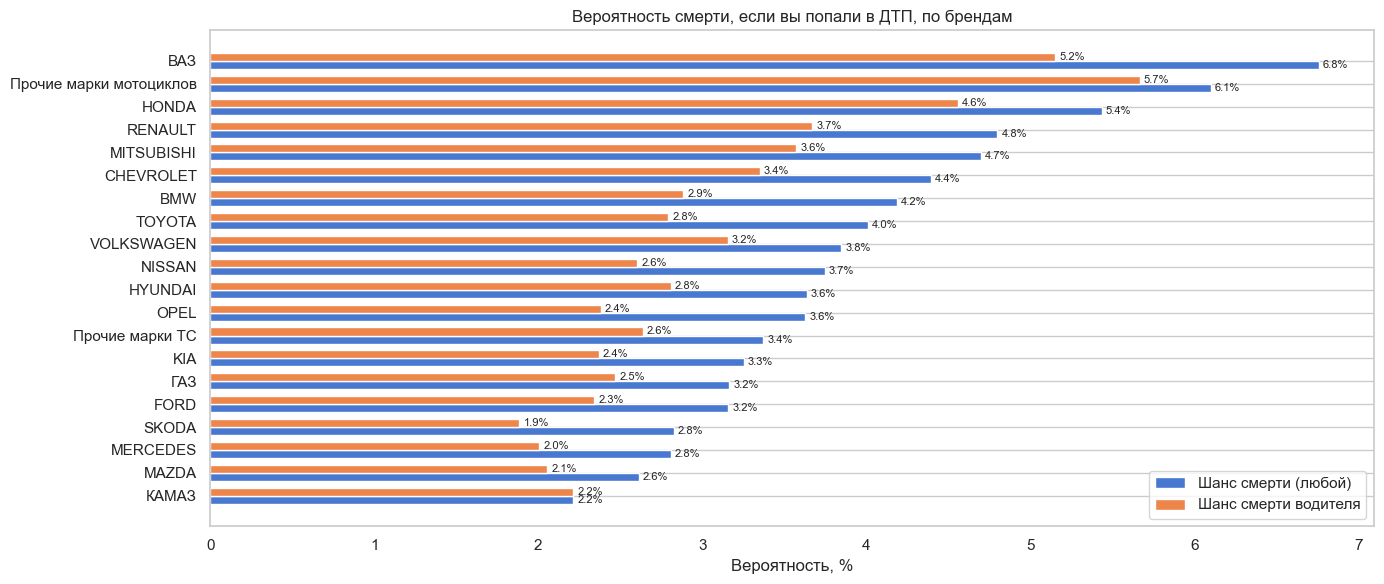

In [158]:
# Топ-20 брендов по количеству машин
top_brands = agg_brand[agg_brand.index.isin(agg_brand.sort_values(by='vehicles', ascending=False).head(20).index)].sort_values(by='p_death_any', ascending=True).head(20)

# Позиции и ширина столбцов
x = np.arange(len(top_brands))  # позиции для брендов
width = 0.35  # ширина столбца

# Настройка графика
fig, ax = plt.subplots(figsize=(14, 6))

# Горизонтальные столбцы
rects1 = ax.barh(x - width/2, top_brands['p_death_any']*100, width, label='Шанс смерти (любой)')
rects2 = ax.barh(x + width/2, top_brands['p_driver_death']*100, width, label='Шанс смерти водителя')

# Применение подписей
autolabel(rects1)
autolabel(rects2)

# Настройки осей и заголовка
ax.set_xlabel('Вероятность, %')
ax.set_title('Вероятность смерти, если вы попали в ДТП, по брендам')
ax.set_yticks(x)
ax.set_yticklabels(top_brands.index)
ax.legend()

# Сетка
plt.grid(axis='x')
fig.tight_layout()
plt.show()

- Опаснее всего быть мотоциклистом - 5.7% шанс погибнуть в ДТП.
- Страшнее всего - ездить на продукции АвтоВАЗа.
- Далее идут Honda, Renault и Mitsubishi.
- На продукции ГАЗ легче попасть в ДТП, но при этом выше шансы выжить.

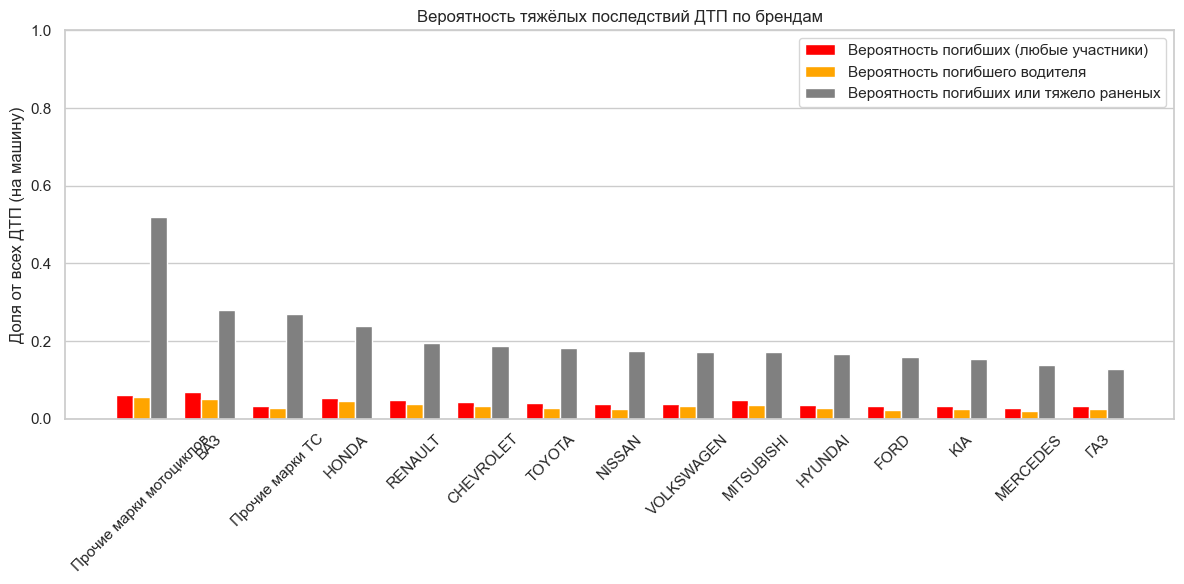

In [159]:
# Берём топ-15 брендов по количеству машин
plot_data = agg_brand.sort_values(by="vehicles", ascending=False).head(15).reset_index()

# отсортируем для построения графика
plot_data = plot_data.sort_values(by='p_F_or_S', ascending=False)

x = np.arange(len(plot_data))  # позиции брендов
width = 0.25  # ширина столбца

fig, ax = plt.subplots(figsize=(12,6))

# Столбцы для каждой метрики
ax.bar(x - width, plot_data["p_death_any"], width, label="Вероятность погибших (любые участники)", color="red")
ax.bar(x, plot_data["p_driver_death"], width, label="Вероятность погибшего водителя", color="orange")
ax.bar(x + width, plot_data["p_F_or_S"], width, label="Вероятность погибших или тяжело раненых", color="gray")

# Настройка оси X
ax.set_xticks(x)
ax.set_xticklabels(plot_data["brand"], rotation=45, ha="center")

# Подписи
ax.set_ylabel("Доля от всех ДТП (на машину)")
ax.set_title("Вероятность тяжёлых последствий ДТП по брендам")
ax.legend()
plt.ylim(0, 1)
plt.grid(axis='x')

plt.tight_layout()
plt.show()

- В очередной раз мы убедились, что попадать в ДТП на мотоцикле - не к добру. Почти в половине случаев это приводит к смерти или лечению в стационаре.
- Предел в 20% серьезных последствий для здоровья пробили также HONDA и ВАЗ. И Прочие марки ТС [удалить]# P.S. берите надежное, а не то, для чего нет марки))

### Цвет ТС

Посмотрим, автомобили какого цвета чаще попадали в ДТП.

In [160]:
vehicles['color'].value_counts().reset_index()

,color,count
0,Белый,21262
1,Серый,15312
2,Черный,13433
3,Иные цвета,8081
4,Синий,7051
5,Красный,4719
6,Зеленый,3127
7,Коричневый,2034
8,Желтый,1961
9,Многоцветный,1586


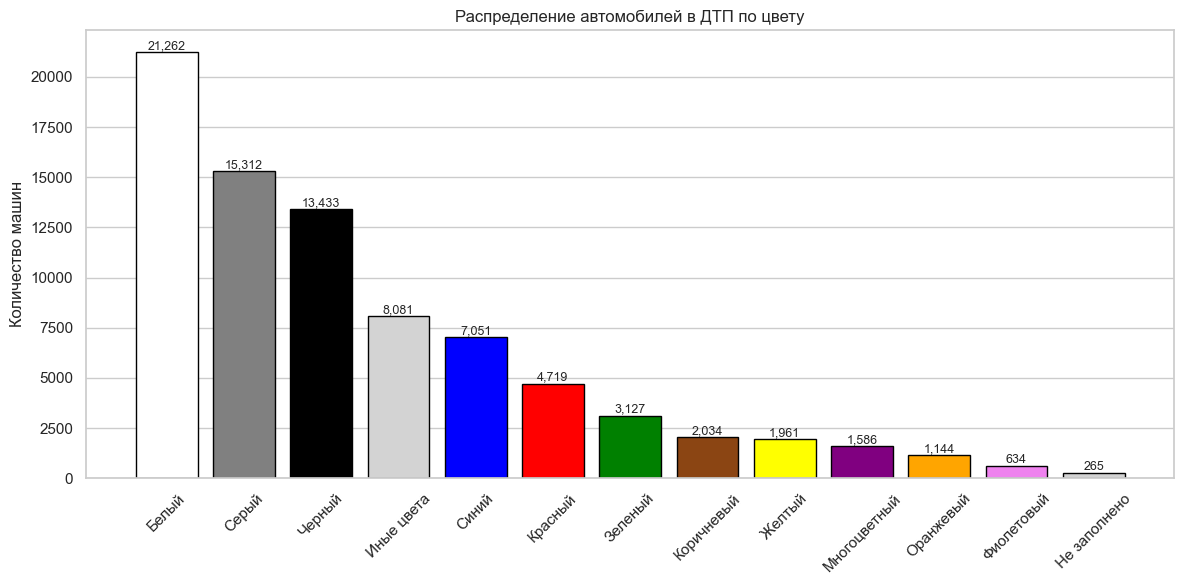

In [161]:
# Данные
color_counts = vehicles['color'].value_counts().reset_index()

# Словарь: название → цвет
color_map = {
    "Белый": "#FFFFFF",
    "Серый": "gray",
    "Черный": "black",
    "Иные цвета": "lightgrey",
    "Синий": "blue",
    "Красный": "red",
    "Зеленый": "green",
    "Коричневый": "saddlebrown",
    "Желтый": "yellow",
    "Многоцветный": "purple",   # или можно rainbow-style
    "Оранжевый": "orange",
    "Фиолетовый": "violet",
    "Не заполнено": "lightgrey"
}

# Подбираем цвета для графика
bar_colors = [color_map.get(c, "lightgrey") for c in color_counts['color']]

# Строим график
plt.figure(figsize=(12,6))
bars = plt.bar(color_counts['color'], color_counts['count'], 
               color=bar_colors, edgecolor="black")

plt.xticks(rotation=45, ha="center")
plt.ylabel("Количество машин")
plt.title("Распределение автомобилей в ДТП по цвету")

# подписи
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:,}", 
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.grid(axis='x')
plt.show()

По этому графику мы только можем сказать, что белые, серые и черные автомобили самые популярные среди населения.

### Модели ТС

Посмотрим на распределение автомобилей по моделям.

In [162]:
vehicles['model'].value_counts().reset_index().head(20)

,model,count
0,Прочие марки и модели ТС,4361
1,Granta (Гранта),3584
2,Прочие марки мотоциклов,2082
3,Solaris,1758
4,Rio,1671
5,Priora,1558
6,Kalina,1319
7,Polo,1255
8,Vesta (Веста),1244
9,Corolla,1181


Мы уже видели распределение на шанс смерти в ДТП по брендам, посмотрим по моделям ТС.

In [163]:
# Объединение
df = participants.merge(vehicles[['vehicle_id', 'model']], on='vehicle_id', how='left')

# Флаги
df['is_driver'] = df['role'] == 'Водитель'
df['is_dead'] = df['health_status'] == 'F'
df['is_serious'] = df['health_status'] == 'S'

# Группировка на уровне машины
agg_vehicle = df.groupby(['vehicle_id', 'model']).agg(
    total_people=('health_status', 'count'),
    dead_any=('is_dead', 'max'),      # 1 если есть хотя бы один F
    serious_any=('is_serious', 'max'),
    dead_count=('is_dead', 'sum'),
    serious_count=('is_serious', 'sum'),
    driver_dead=('is_dead', lambda x: int((df.loc[x.index, 'is_driver'] & x).any()))
).reset_index()

# Группировка по моделям
agg_model = agg_vehicle.groupby('model').agg(
    vehicles=('vehicle_id', 'nunique'),
    people_total=('total_people', 'sum'),
    deaths_total=('dead_count', 'sum'),
    serious_total=('serious_count', 'sum'),
    vehicles_with_death=('dead_any', 'sum'),
    vehicles_with_serious=('serious_any', 'sum'),
    driver_deaths=('driver_dead', 'sum')
)

# Вероятности
agg_model['p_death_any'] = agg_model['vehicles_with_death'] / agg_model['vehicles']
agg_model['p_driver_death'] = agg_model['driver_deaths'] / agg_model['vehicles']

In [164]:
# F+S и вероятность хотя бы тяжёлого исхода
agg_model['F+S'] = agg_model['vehicles_with_death'] + agg_model['vehicles_with_serious']
agg_model['p_F_or_S'] = agg_model['F+S'] / agg_model['vehicles']
agg_brand.sort_values(by='vehicles', ascending=False).head(20)

,vehicles,people_total,deaths_total,serious_total,vehicles_with_death,vehicles_with_serious,driver_deaths,p_death_any,p_driver_death,F+S,p_F_or_S
brand,,,,,,,,,,,
ВАЗ,15270,22480,1272,4131,1032,3254,787,0.07,0.05,4286,0.28
TOYOTA,6735,9542,321,1194,270,950,188,0.04,0.03,1220,0.18
Прочие марки ТС,4361,5154,157,1102,147,1032,115,0.03,0.03,1179,0.27
HYUNDAI,4096,5663,191,682,149,531,115,0.04,0.03,680,0.17
KIA,3966,5484,156,602,129,485,94,0.03,0.02,614,0.15
RENAULT,2834,3900,169,502,136,417,104,0.05,0.04,553,0.20
NISSAN,2802,3757,126,475,105,386,73,0.04,0.03,491,0.18
VOLKSWAGEN,2598,3552,117,418,100,346,82,0.04,0.03,446,0.17
ГАЗ,2307,3084,78,292,73,225,57,0.03,0.02,298,0.13


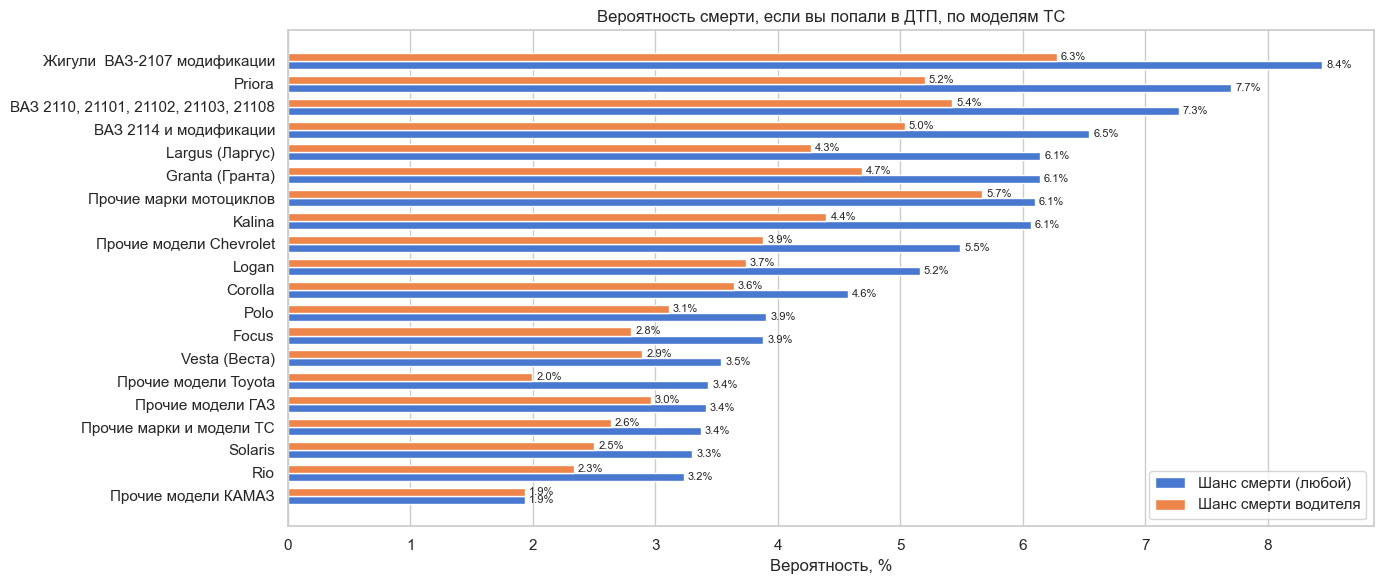

In [165]:
# Топ-20 моделей по количеству машин
top_models = (
    agg_model[agg_model.index.isin(
        agg_model.sort_values(by='vehicles', ascending=False).head(20).index
    )]
    .sort_values(by='p_death_any', ascending=True)
    .head(20)
)

x = np.arange(len(top_models))  # позиции для моделей
width = 0.35  # ширина столбца

fig, ax = plt.subplots(figsize=(14, 6))

# Горизонтальные столбцы
rects1 = ax.barh(x - width/2, top_models['p_death_any']*100, width, label='Шанс смерти (любой)')
rects2 = ax.barh(x + width/2, top_models['p_driver_death']*100, width, label='Шанс смерти водителя')

# Настройки
ax.set_xlabel('Вероятность, %')
ax.set_title('Вероятность смерти, если вы попали в ДТП, по моделям ТС')
ax.set_yticks(x)
ax.set_yticklabels(top_models.index)
ax.legend()

# Подписи
autolabel(rects1)
autolabel(rects2)

# plt.xlim(0, 100)
plt.grid(axis='y')
fig.tight_layout()
plt.show()


Уже не так страшно выглядит ВАЗ - в целом. Главное - быть аккуратными в старых моделях.\
Vesta на уровне остальных популярных моделей (Solaris, Rio, Focus), ездить можно.

In [166]:
agg_brand['F+S'] = agg_brand['vehicles_with_death'] + agg_brand['vehicles_with_serious']
agg_brand['p_F_or_S'] = agg_brand['F+S'] / agg_brand['vehicles']

In [167]:
threshold = 300
agg_brand[agg_brand['vehicles']>threshold].sort_values(by='p_F_or_S', ascending=False).head(40)

,vehicles,people_total,deaths_total,serious_total,vehicles_with_death,vehicles_with_serious,driver_deaths,p_death_any,p_driver_death,F+S,p_F_or_S
brand,,,,,,,,,,,
Прочие марки мотоциклов,2082,2533,129,1049,127,955,118,0.06,0.06,1082,0.52
YAMAHA,426,478,41,166,39,159,37,0.09,0.09,198,0.46
ВАЗ,15270,22480,1272,4131,1032,3254,787,0.07,0.05,4286,0.28
SUZUKI,738,924,47,169,44,157,34,0.06,0.05,201,0.27
Прочие марки ТС,4361,5154,157,1102,147,1032,115,0.03,0.03,1179,0.27
DAEWOO,742,1051,62,175,53,141,46,0.07,0.06,194,0.26
УАЗ,728,1101,42,205,39,151,27,0.05,0.04,190,0.26
HONDA,2171,2930,131,479,118,399,99,0.05,0.05,517,0.24
RENAULT,2834,3900,169,502,136,417,104,0.05,0.04,553,0.20


Стоит обратить внимание на модели, у которых шанс на смерть или тяжелую травму (травму, связанную с лечение в стационаре) выше 20%:
- большинство ВАЗ, кроме Весты.
- мотоциклы, в том числе и Yamaha.
- Nexia - 29%, Accent - 24%, Sandero, Almera - 23%, Corolla - 20%.


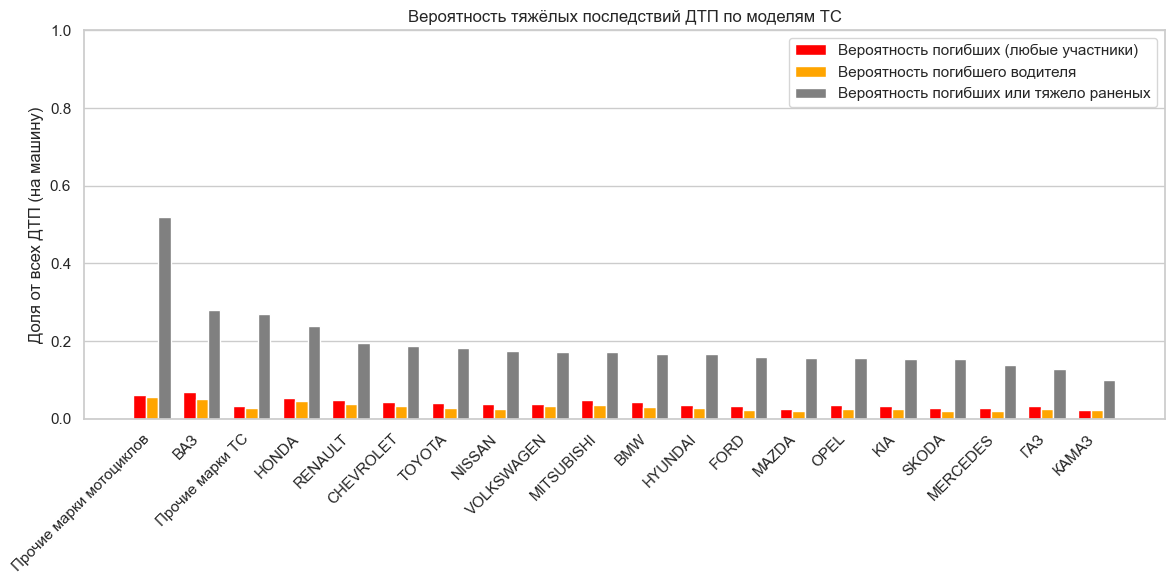

In [168]:
# Берём топ-15 брендов по количеству машин
plot_data = agg_brand[agg_brand['vehicles']>threshold].sort_values(by="vehicles", ascending=False).head(20).reset_index()

# отсортируем для построения графика
plot_data = plot_data.sort_values(by='p_F_or_S', ascending=False)

x = np.arange(len(plot_data))  # позиции брендов
width = 0.25  # ширина столбца

fig, ax = plt.subplots(figsize=(12,6))

# Столбцы для каждой метрики
ax.bar(x - width, plot_data["p_death_any"], width, label="Вероятность погибших (любые участники)", color="red")
ax.bar(x, plot_data["p_driver_death"], width, label="Вероятность погибшего водителя", color="orange")
ax.bar(x + width, plot_data["p_F_or_S"], width, label="Вероятность погибших или тяжело раненых", color="gray")

# Настройка оси X
ax.set_xticks(x)
ax.set_xticklabels(plot_data["brand"], rotation=45, ha="right")

# Подписи
ax.set_ylabel("Доля от всех ДТП (на машину)")
ax.set_title("Вероятность тяжёлых последствий ДТП по моделям ТС")
ax.legend()
plt.ylim(0, 1)
plt.grid(axis='x')

plt.tight_layout()
plt.show()

- Мотоциклы - в половине случаев тяжелые последствия.
- ВАЗ-2107, 2110 и 2114 различных модификаций, Priora, Logan и Kalina - шанс 20-35%.

### Категория ТС

Посмотрим, какие категории ТС чаще всего попадают в ДТП.
У нас категории:
- B  = легковые автомобили
- A  = мотоциклы, мопеды, квадроциклы
- M  = мопеды до 50 куб.см
- V  = велосипеды, персональные электрические средства
- C  = грузовые автомобили
- D  = автобусы, троллейбусы
- Tm = трамваи
- S  = спецтехника, трактора
- X  = спецслужбы - 101-104
- R  = ж/д
- Z = военная техника
- U  = неизвестно, в т.ч. "Иные ТС"

In [169]:
vehicles.category.value_counts().reset_index().assign(share = lambda x: x['count']/x['count'].sum()*100)

,category,count,share
0,B,60425,72.91
1,C,7297,8.81
2,A,4633,5.59
3,D,3408,4.11
4,V,2261,2.73
5,M,1644,1.98
6,U,1626,1.96
7,S,1219,1.47
8,Tm,164,0.20
9,X,152,0.18


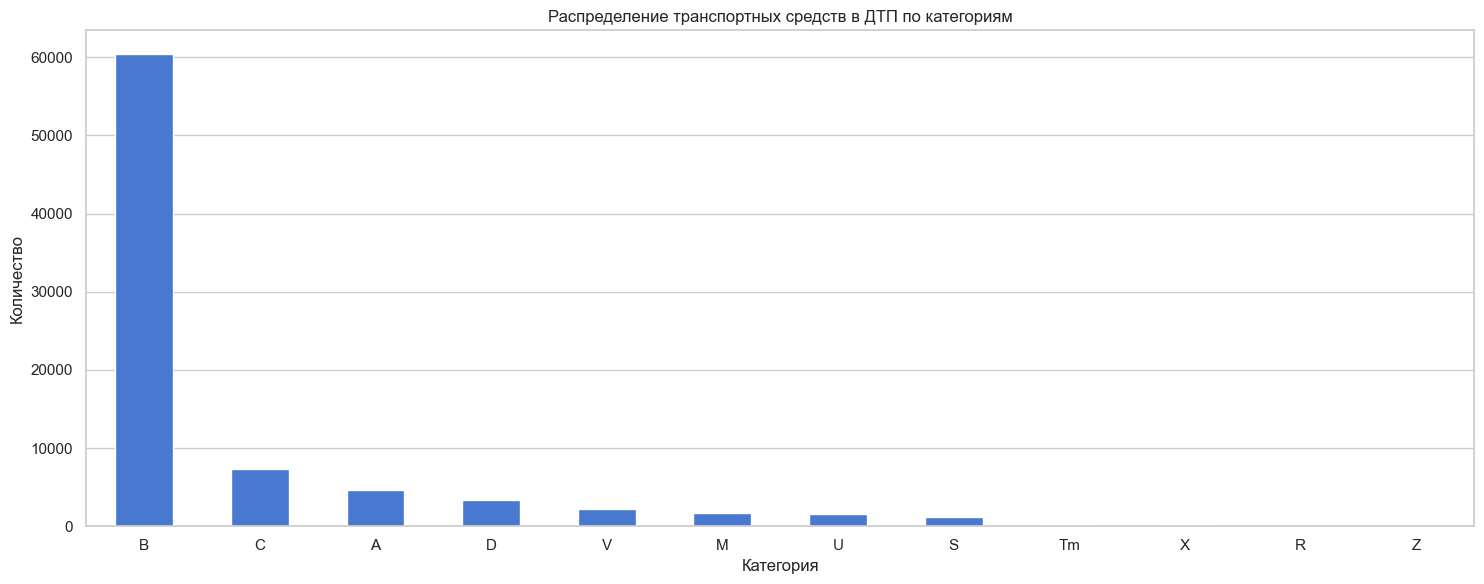

In [170]:
# сгруппируем данные и построим график
vehicles.category.value_counts().reset_index().plot(
    x='category',
    y='count',
    kind='bar',
    title='Распределение транспортных средств в ДТП по категориям',
    xlabel='Категория',
    ylabel='Количество',
    legend=False,  # Легенда не нужна, так как одна переменная
    rot=0,  # Поворот подписей на оси X для читаемости
    figsize=(15, 6),  # Размер графика
)
plt.grid(axis='x')
plt.tight_layout()  # Автоматическая подгонка элементов


Чаще всего в ДТП попадают легковые автомобили.

### Участники ДТП

Рассмотрим подробнее участников

In [171]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126582 entries, 0 to 164882
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   role                         126582 non-null  object
 1   gender                       126582 non-null  object
 2   violations                   126582 non-null  object
 3   health_status                126582 non-null  object
 4   years_of_driving_experience  68981 non-null   Int64 
 5   accident_id                  126582 non-null  int64 
 6   vehicle_id                   112351 non-null  object
dtypes: Int64(1), int64(1), object(5)
memory usage: 7.8+ MB


### Роли участников

Посмотрим, кто основные участники ДТП

In [172]:
participants['role'].value_counts().reset_index().assign(
    share = lambda x: x['count']/x['count'].sum()
)

,role,count,share
0,Водитель,80818,0.64
1,Пассажир,29551,0.23
2,Пешеход,13832,0.11
3,Велосипедист,1883,0.01
4,Пешеход c (из) ТС,266,0.00
5,Иной участник,143,0.00
6,Работник дорожных служб,33,0.00
7,Сотрудник ДПС,27,0.00
8,Работник коммунальных служб,8,0.00
9,Сотрудник силовых структур,8,0.00


В основном в ДТП попадают водители. Реже пассажиры (в 3 раза) и пешеходы (в 6 раз).\
За полгода было 3 всадника и 6 погонщиков скота.

Посмотрим, как на их здоровье повлияло ДТП.

In [173]:
# посчитаем количество пострадавших по ролям, доли погибших и тяжело раненых
pivot = participants.pivot_table(
    index='role',
    columns='health_status',
    aggfunc='size',
    fill_value=0
).reset_index().assign(
    count = lambda x: (x['F']+x['M']+x['N']+x['S']),
    f_share = lambda x: x['F']/x['count']*100,
    f_s_share = lambda x: (x['F']+x['S'])/x['count']*100
).sort_values(by='count', ascending=True) # чтобы роли шли снизу вверх

pivot.sort_values(by='count', ascending=False)


health_status,role,F,M,N,S,count,f_share,f_s_share
1,Водитель,2652,17575,51542,9049,80818,3.28,14.48
4,Пассажир,1405,16205,5065,6876,29551,4.75,28.02
5,Пешеход,1155,8250,208,4219,13832,8.35,38.85
0,Велосипедист,93,1251,27,512,1883,4.94,32.13
6,Пешеход c (из) ТС,45,123,15,83,266,16.92,48.12
3,Иной участник,8,53,36,46,143,5.59,37.76
8,Работник дорожных служб,8,14,0,11,33,24.24,57.58
10,Сотрудник ДПС,2,16,1,8,27,7.41,37.04
11,Сотрудник силовых структур,1,6,1,0,8,12.50,12.50
9,Работник коммунальных служб,1,3,1,3,8,12.50,50.00


Всадники и погонщики живы, всё хорошо. Пешеходам лучше в ДТП не попадать. Каждый девятый участник ДТП - пешеход, из них погибло или попало на больничную койку - 39%.\
28% пассажиров, попавших в зарегистрированное ДТП, серьезно пострадали.

In [174]:
fig = go.Figure()

# горизонтальные stacked bar
for col in ["F","S","M","N"]:
    fig.add_trace(go.Bar(
        y=pivot["role"],
        x=pivot[col],
        name=col,
        orientation="h",
        customdata=[col] * len(pivot),  # передаём категорию
        hovertemplate="<b>%{y}</b><br>%{customdata}: %{x}<extra></extra>"
    ))

# настройка осей
fig.update_layout(
    barmode="stack",
    xaxis=dict(title="Количество участников"),
    xaxis2=dict(title="Доля F+S, %", overlaying="x", side="top"),
    yaxis=dict(title="Роль"),
    # legend=dict(title="Статус здоровья", orientation="v"),
    title=dict(
        text="Распределение участников по ролям и статусу здоровья",
        x=0.5,              # выравнивание по центру
        xanchor="center",
        yanchor="top"
    )
)

fig.show()

Этот график не дает нам много информации, так как в основном в ДТП попадают водители.\
У пассажиров и пешеходов сильно меньше шансов остаться без последствий для здоровья (N)

### Пол участников

Посмотрим, кто чаще оказывается в ДТП, какое у них распределение по ролям, на каких марках они ездят.

In [175]:
participants['gender'].value_counts(normalize=True).reset_index()

,gender,proportion
0,М,0.68
1,Ж,0.31
2,-,0.01


69% участников ДТП - мужчины.\
И 31% женщин.

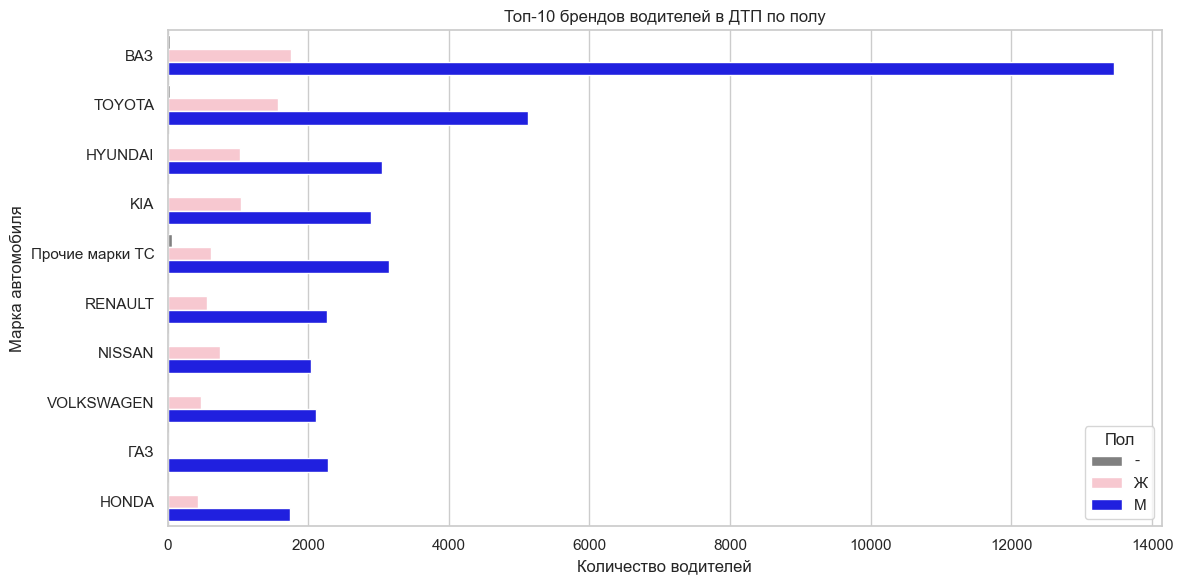

In [176]:
# Ограничимся только водителями с известным полом
drivers = participants[(participants['role'] == 'Водитель') & participants['gender'].notna()]

# Топ-10 брендов по количеству водителей
driver_vehicles = drivers.merge(vehicles, on='vehicle_id', how='left')
top_brands = driver_vehicles['brand'].value_counts().head(10).index

brand_gender = driver_vehicles[driver_vehicles['brand'].isin(top_brands)]
brand_gender_count = (
    brand_gender.groupby(['brand', 'gender'])
    .size()
    .reset_index(name='count')
)

# Сортировка брендов по общему количеству водителей (по убыванию)
brand_order = brand_gender_count.groupby('brand')['count'].sum().sort_values(ascending=False).index
brand_gender_count['brand'] = pd.Categorical(brand_gender_count['brand'], categories=brand_order, ordered=True)

# Сравнение ролей по полу
role_gender = participants[participants['gender'].notna()]
role_gender_count = role_gender.groupby(['role', 'gender']).size().reset_index(name='count')

# Сортировка ролей по общему количеству участников (по убыванию)
role_order = role_gender_count.groupby('role')['count'].sum().sort_values(ascending=False).index
role_gender_count['role'] = pd.Categorical(role_gender_count['role'], categories=role_order, ordered=True)

# График: бренды водителей по полу
plt.figure(figsize=(12,6))
sns.barplot(
    data=brand_gender_count,
    y='brand',
    x='count',
    hue='gender',
    palette={'М':'blue','Ж':'pink', '-':'grey'}
)
plt.title('Топ-10 брендов водителей в ДТП по полу')
plt.xlabel('Количество водителей')
plt.ylabel('Марка автомобиля')
plt.legend(title='Пол')
plt.tight_layout()
plt.show()

Среди водителей большинство мужчины. Женщины чаще всего попадают в ДТП на ВАЗ, TOYOTA, HYANDAY, KIA, NISSAN.

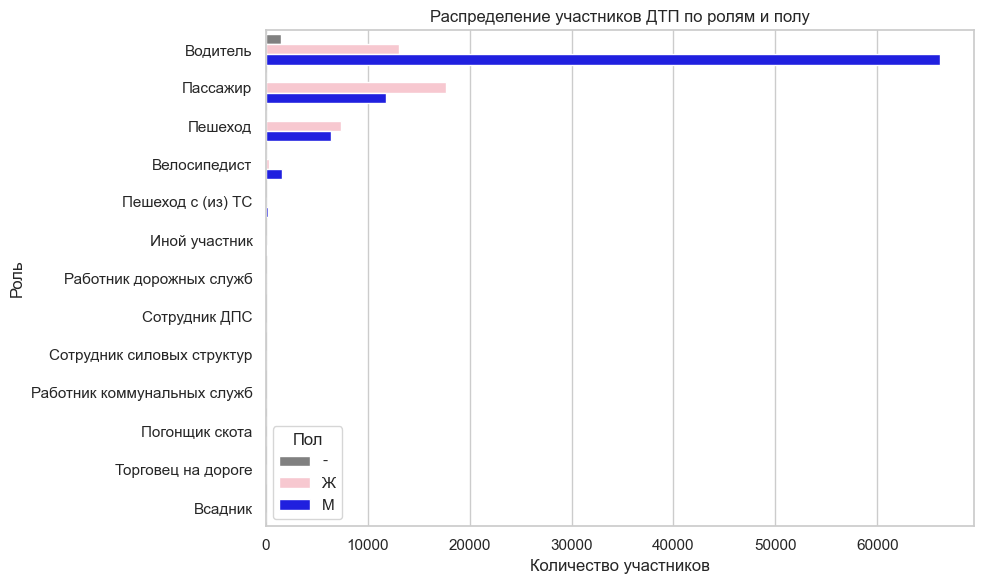

In [177]:
# График: роли участников по полу
plt.figure(figsize=(10,6))
sns.barplot(
    data=role_gender_count,
    y='role',
    x='count',
    hue='gender',
    palette={'М':'blue','Ж':'pink', '-': 'grey'}
)
plt.title('Распределение участников ДТП по ролям и полу')
plt.xlabel('Количество участников')
plt.ylabel('Роль')
plt.legend(title='Пол')
plt.tight_layout()
plt.show()


- Среди водителей и велосипедистов - большинство мужчины. Разница в 5 раз.
- Пассажиры и пешеходы в ДТП - чаще женщины. Разница в 10-30%.

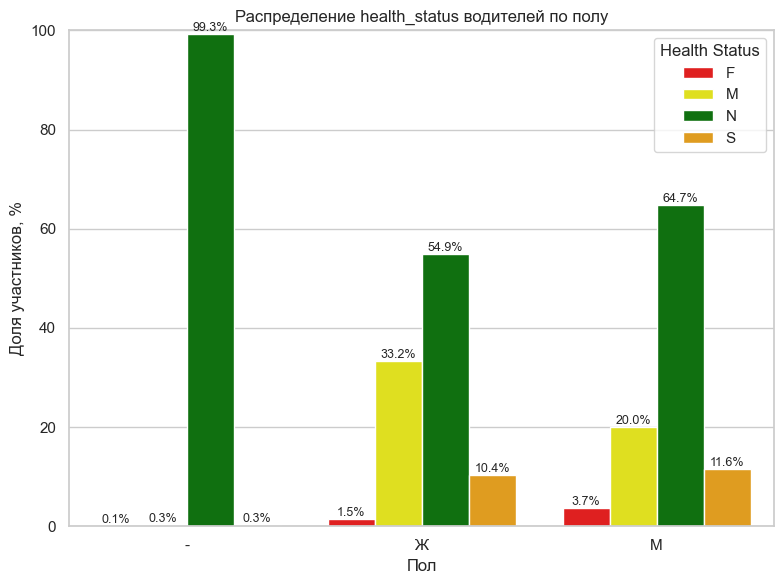

In [178]:
# Ограничимся водителями с известным полом
drivers = participants[(participants['role'] == 'Водитель') & participants['gender'].notna()]

# Группировка по полу и health_status
health_gender = (
    drivers.groupby(['gender', 'health_status'])
    .size()
    .reset_index(name='count')
)

# Общие количества по полу
total_gender = drivers.groupby('gender').size().reset_index(name='total')

# Объединяем, чтобы получить доли
health_gender = health_gender.merge(total_gender, on='gender')
health_gender['share'] = health_gender['count'] / health_gender['total'] * 100

# --- График ---
plt.figure(figsize=(8,6))
ax = sns.barplot(
    data=health_gender,
    x='gender',
    y='share',
    hue='health_status',
    palette={'F':'red','S':'orange','M':'yellow','N':'green', 'U': 'grey'}
)
plt.title('Распределение health_status водителей по полу')
plt.ylabel('Доля участников, %')
plt.xlabel('Пол')
plt.legend(title='Health Status')
plt.ylim(0, 100)

# Добавляем подписи на столбцах
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # чтобы не писать нули
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

- Женщины-водители в 2 раза реже погибают в результате ДТП - 1.5% против 3.7%.
- Если авария несерьезная, то мужчины чаще обходятся вообще без последствий -65% против 55%. Женщины на 10% больше получают легкие травмы, не требующие лежать в больнице. Возможно, мужчины просто отказываются от лечения или говорят, что с ними всё хорошо.
- Доля серьёзных травм почти одинаковая, около 10-11%.
- Если ДТП без пострадавших, то могут не указывать пол участников.

### Нарушения участников

Посмотрим, какие бывают нарушения.

In [179]:
participants.violations.value_counts()

violations
[]                                                                                                             61491
[Очередность проезда]                                                                                           6155
[Несоответствие скорости]                                                                                       4110
[Нарушение ОСАГО]                                                                                               2921
[Выбор дистанции]                                                                                               2725
                                                                                                               ...  
[На проезжей части без цели перехода, Неожиданный выход из-за стоящего ТС, Нет световозвращающих элементов]        1
[Неподчинение сигналам регулировщика, Неожиданный выход из-за стоящего ТС]                                         1
[Переход перед спецтранспортом]                      

Большое число участников без нарушений. Примем, что если пустой список, то человек невиновен. 

In [180]:
# participants.loc[participants['violations'].map(len) > 0, 'role'].value_counts()
# participants.loc[participants['violations'].map(len) == 0, 'role'].value_counts()
participants.loc[participants['violations'].map(len) > 0]

,role,gender,violations,health_status,years_of_driving_experience,accident_id,vehicle_id
0,Водитель,М,"[Выезд на встречку, Нарушение правил обгона, Отсутствие необходимых документов]",N,20,188743,0
2,Водитель,М,"[Водитель пьян, Нет прав]",F,<NA>,188743,2
3,Водитель,М,[Нарушение условий движения задним ходом],N,25,883957,3
4,Водитель,М,[Нарушение расположения ТС],N,17,1505787,4
5,Водитель,М,"[Очередность проезда, Нет прав]",M,<NA>,1505806,5
...,...,...,...,...,...,...,...
164819,Пешеход,М,[Движение вдоль проезжей части (вне НП)],S,<NA>,991321,None
164841,Пешеход,М,[Переход вне ПП при его наличии],S,<NA>,1508850,None
164858,Пешеход,М,[Передвижение на скейтборде по проезжей части],M,<NA>,1508867,None
164864,Пешеход,М,[Переход вне ПП при его наличии],M,<NA>,1508873,None


In [181]:
participants['violations_count'] = participants['violations'].apply(len)
participants['violations_count'].value_counts().reset_index().assign(
    proportion = lambda x: x['count']/x['count'].sum()*100
)

,violations_count,count,proportion
0,0,61491,48.58
1,1,38563,30.46
2,2,16555,13.08
3,3,5777,4.56
4,4,2559,2.02
5,5,1599,1.26
6,6,37,0.03
7,7,1,0.00


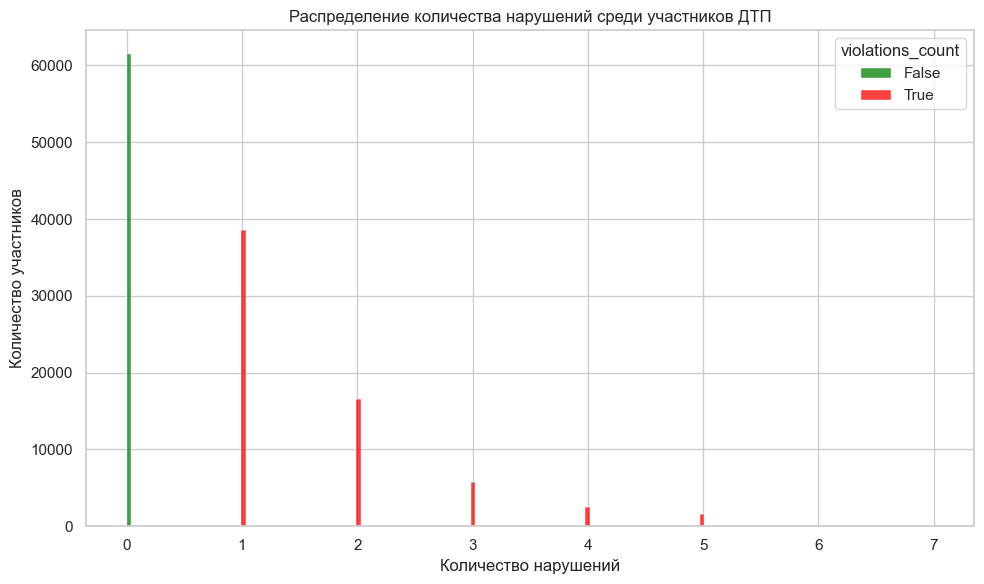

In [182]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=participants,
    x='violations_count',
    bins="auto",  # можно расширить, если есть больше нарушений
    hue=participants['violations_count']>0,
    palette={True:'red', False:'green'},
    multiple='stack'
)
plt.title('Распределение количества нарушений среди участников ДТП')
plt.xlabel('Количество нарушений')
plt.ylabel('Количество участников')
plt.tight_layout()
plt.show()


Половина участников ДТП - попали туда не совершив никакого нарушения.

Посмотрим не среди всех участников, а только среди погибших.

In [183]:
participants['violation_flag'] = participants['violations_count'].apply(lambda x: 'Есть нарушение' if x > 0 else 'Нарушений нет')
health_F = (
    participants.groupby(['role', 'violation_flag'])
    .agg(F_count=('health_status', lambda x: (x=='F').sum()))
    .reset_index()
)


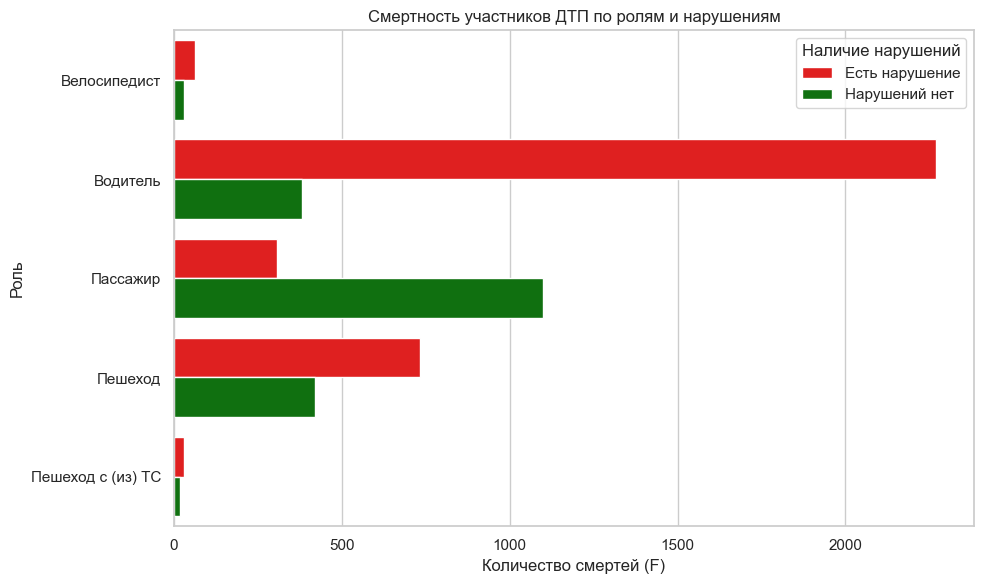

In [184]:
plt.figure(figsize=(10,6))
threshold = 10
sns.barplot(
    data=health_F[health_F['F_count']>threshold],
    y='role',
    x='F_count',
    hue='violation_flag',
    palette={'Есть нарушение':'red', 'Нарушений нет':'green'}
)
plt.title('Смертность участников ДТП по ролям и нарушениям')
plt.xlabel('Количество смертей (F)')
plt.ylabel('Роль')
plt.legend(title='Наличие нарушений')
plt.tight_layout()
plt.show()


Среди категорий, в которых больше 10 смертей:
- только пассажиры чаще погибают даже не совершив никаких нарушений. Больше 1000 случаев за 6 месяцев.
- Водители в разы чаще имеют какие-то нарушения, которые привели их к этому состоянию.
- Погибшие пешеходы в результате нарушения - ~750 человек. Что всего в 3 раза меньше, чем водителей, которые нарушили правила и погибли.

Посмотрим, какие нарушения встречаются чаще всего

In [185]:
# Разворачиваем списки нарушений в строки
violations_exploded = participants.explode('violations')

# Убираем пустые (где [])
violations_exploded = violations_exploded[violations_exploded['violations'].notna()]

# Считаем количество каждого нарушения
violation_counts = (
    violations_exploded['violations']
    .value_counts()
    .reset_index()
    .rename(columns={'violations':'violation'})
)

# Смотрим топ-20 нарушений
violation_counts.head(50)


,violation,count
0,Нарушение ОСАГО,13383
1,Несоответствие скорости,10192
2,Очередность проезда,9554
3,Нарушение расположения ТС,6299
4,Нет прав,5878
5,Другие нарушения,5619
6,Выбор дистанции,4706
7,Скрытие с места ДТП,4379
8,Нарушение проезда пешеходного перехода,4116
9,Водитель пьян,3299


Нарушения мы нашли, но неясно, приводят ли они к фатальным последствиям:
- посчитаем, сколько человек с данными нарушениями погибло;
- на основании id аварии найдем, сколько человек в ней погибло (из таблицы accidents)

In [186]:
# Оставляем только нарушения, встречающиеся >= 100 раз
threshold = 100
valid_violations = violation_counts.loc[violation_counts['count'] >= threshold, 'violation']

# Участники с этими нарушениями
violations_filtered = violations_exploded[
    violations_exploded['violations'].isin(valid_violations)
]

# Сколько участников погибло (health_status = F) по каждому нарушению
fatal_by_violation = (
    violations_filtered
    .groupby('violations')
    .apply(lambda g: (g['health_status'] == 'F').sum())
    .reset_index(name='fatal_participants')
)

# Привязываем к авариям и считаем суммарное число погибших в этих авариях
violation_accidents = violations_filtered[['violations','accident_id']].drop_duplicates()
violation_accidents = violation_accidents.merge(
    accidents[['accident_id','dead_count']],
    on='accident_id',
    how='left'
)

dead_by_violation = (
    violation_accidents.groupby('violations')['dead_count']
    .sum()
    .reset_index()
)

# Итоговая таблица
violation_summary = (
    violation_counts
    .merge(fatal_by_violation, left_on='violation', right_on='violations')
    .merge(dead_by_violation, left_on='violation', right_on='violations')
    [['violation','count','fatal_participants','dead_count']]
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

violation_summary.sort_values(by='dead_count', ascending=False).head(20)

C:\Users\fedim\AppData\Local\Temp\ipykernel_18928\875306289.py:14: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,violation,count,fatal_participants,dead_count
1,Несоответствие скорости,10192,691,1406
0,Нарушение ОСАГО,13383,567,1377
11,Выезд на встречку,2983,491,1089
3,Нарушение расположения ТС,6299,431,767
13,Без ремня (водитель),2169,446,731
9,Водитель пьян,3299,363,696
4,Нет прав,5878,361,647
10,Без ремня (пассажир),3217,427,532
5,Другие нарушения,5619,54,457
2,Очередность проезда,9554,175,418


Несоблюдение требований ОСАГО и скоростной режим всё равно в лидерах по количеству смертей. И выезд на встречку.

Посчитаем долю - количество смертей на аварии с данным нарушением.

In [187]:
violation_summary['fatal_rate'] = (
    violation_summary['fatal_participants'] / violation_summary['count']
).round(3)
violation_summary

,violation,count,fatal_participants,dead_count,fatal_rate
0,Нарушение ОСАГО,13383,567,1377,0.04
1,Несоответствие скорости,10192,691,1406,0.07
2,Очередность проезда,9554,175,418,0.02
3,Нарушение расположения ТС,6299,431,767,0.07
4,Нет прав,5878,361,647,0.06
5,Другие нарушения,5619,54,457,0.01
6,Выбор дистанции,4706,108,282,0.02
7,Скрытие с места ДТП,4379,0,218,0.00
8,Нарушение проезда пешеходного перехода,4116,1,192,0.00
9,Водитель пьян,3299,363,696,0.11


Посчитаем количество смертей на уникальную аварию.

In [188]:
accidents_per_violation = (
    violation_accidents.groupby('violations')['accident_id']
    .nunique()
    .reset_index(name='accident_count')
)

violation_summary = violation_summary.merge(
    accidents_per_violation,
    left_on='violation', right_on='violations'
)

violation_summary['avg_dead_per_accident'] = (
    violation_summary['dead_count'] / violation_summary['accident_count']
).round(2)

У нас появился лишний столбец `violations`, удаляем.

In [189]:
violation_summary.drop(columns=['violations'], inplace=True)

In [190]:
violation_summary

,violation,count,fatal_participants,dead_count,fatal_rate,accident_count,avg_dead_per_accident
0,Нарушение ОСАГО,13383,567,1377,0.04,12287,0.11
1,Несоответствие скорости,10192,691,1406,0.07,10152,0.14
2,Очередность проезда,9554,175,418,0.02,9500,0.04
3,Нарушение расположения ТС,6299,431,767,0.07,6230,0.12
4,Нет прав,5878,361,647,0.06,5734,0.11
5,Другие нарушения,5619,54,457,0.01,5319,0.09
6,Выбор дистанции,4706,108,282,0.02,4672,0.06
7,Скрытие с места ДТП,4379,0,218,0.00,4290,0.05
8,Нарушение проезда пешеходного перехода,4116,1,192,0.00,4096,0.05
9,Водитель пьян,3299,363,696,0.11,3283,0.21


Очень много информации. Отсеем те, в которых `dead_count` меньше 100

In [191]:
threshold = 100
violation_summary.loc[violation_summary['dead_count']>threshold].sort_values(by='avg_dead_per_accident', ascending=False)

,violation,count,fatal_participants,dead_count,fatal_rate,accident_count,avg_dead_per_accident
40,Нет световозвращающих элементов,438,222,223,0.51,425,0.52
44,Пешеход пьян,268,117,117,0.44,267,0.44
33,На проезжей части без цели перехода,579,217,218,0.38,564,0.39
11,Выезд на встречку,2983,491,1089,0.17,2961,0.37
37,Нарушение режима труда/отдыха,491,6,173,0.01,468,0.37
10,Без ремня (пассажир),3217,427,532,0.13,1490,0.36
13,Без ремня (водитель),2169,446,731,0.21,2082,0.35
21,Выезд на встречку (запрещено),1083,165,350,0.15,1075,0.33
31,Нарушение правил обгона,625,45,142,0.07,622,0.23
9,Водитель пьян,3299,363,696,0.11,3283,0.21


И построим визуализацию, где рассмотрим, какие нарушения чаще всего приводят к смертельным ДТП. По данным за первую половину 2025 года.

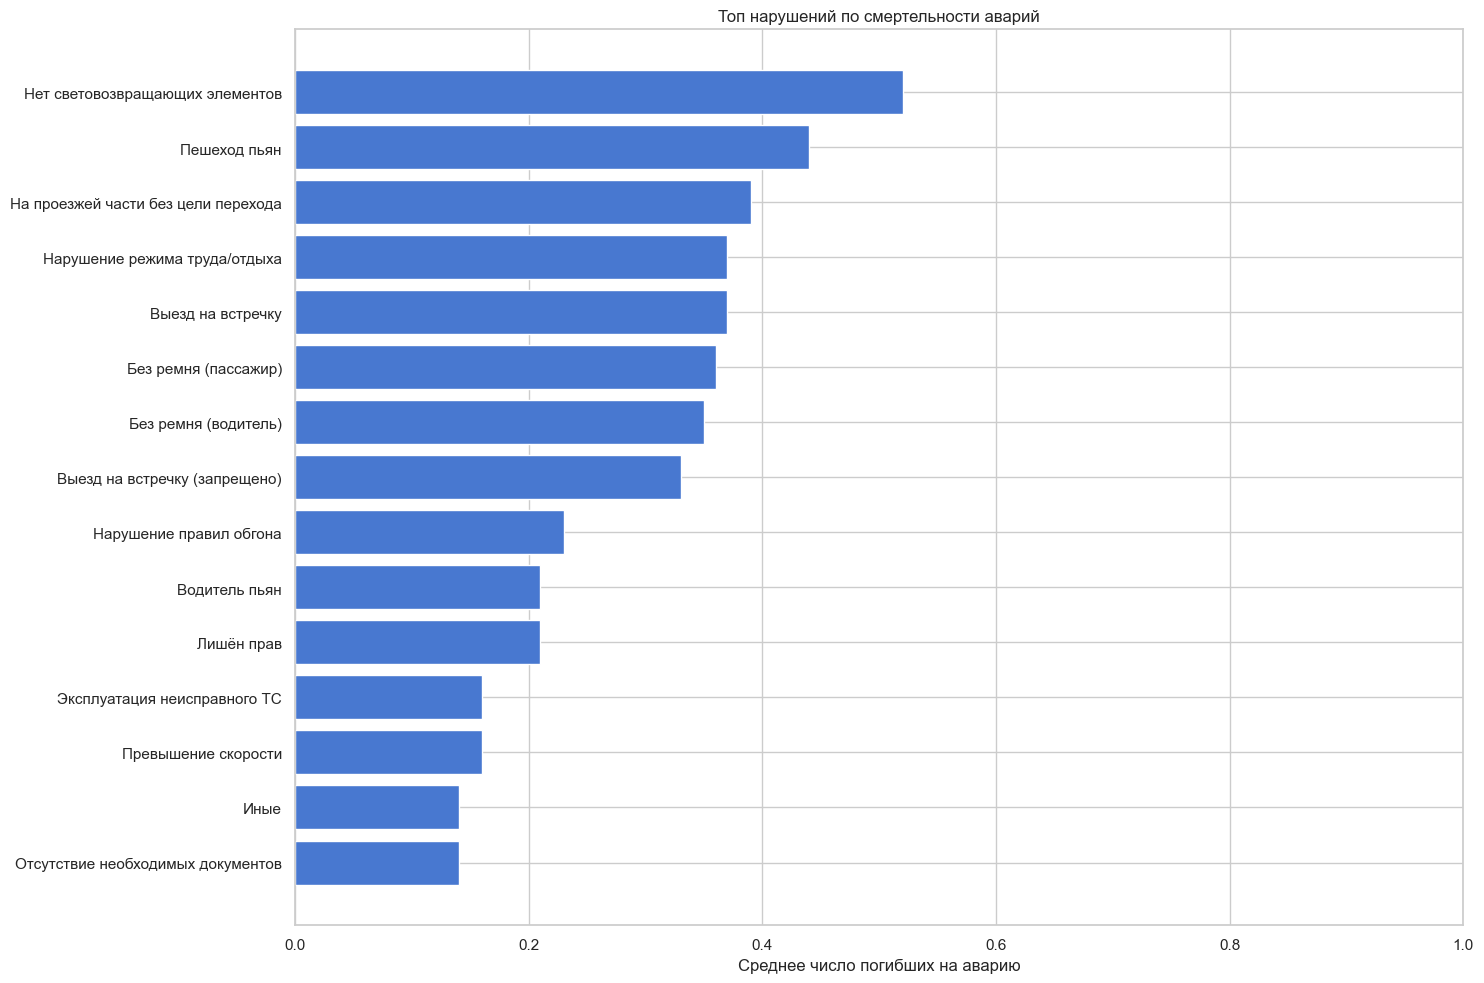

In [192]:
# Берём топ-15 по среднему числу погибших в аварии
plot_data = (
    violation_summary[violation_summary['dead_count'] > threshold]
    .sort_values('avg_dead_per_accident', ascending=True)
    .tail(15)
)

# переносим длинные подписи
plot_data['violation_wrapped'] = plot_data['violation'].apply(
    lambda x: '\n'.join(textwrap.wrap(x, width=60))  # width подбираем под размер
)

plt.figure(figsize=(15, 10))
plt.barh(plot_data['violation_wrapped'], plot_data['avg_dead_per_accident'])
plt.xlabel('Среднее число погибших на аварию')
plt.title('Топ нарушений по смертельности аварий')

xmax = violation_summary['avg_dead_per_accident'].max()*1.1 if violation_summary['avg_dead_per_accident'].max() > 1 else 1
plt.xlim(0, xmax)
plt.tight_layout()
plt.show()

- Отсутствие световозвращающих элементов - в половине случаев ДТП с таким нарушением приведет к смертельному исходу для кого-то.
- **Пьяный пешеход в 2 раза опаснее пьяного водителя**. Вернее, в ДТП с пьяным пешеходом смертельные случаи чаще, чем в ДТП с пьяным водителем.
- Не стоит просто находиться на проезжей части без цели её перехода. ДТП с таким нарушением так же часто кончаются смертью, как ДТП из-за выезда на встречную полосу и пьяные пешеходы.
- Пассажиры, не использующие ремни безопасности - частая причина смерти.
- ДТП с водителем в состоянии алькогольного опьяния и с водителем без прав одинаково опасны.


### Статус здоровья участников ДТП

In [193]:
participants['health_status'].value_counts().reset_index()

,health_status,count
0,N,56902
1,M,43501
2,S,20809
3,F,5370


In [194]:
(participants['health_status'].value_counts(normalize=True)*100).reset_index()

,health_status,proportion
0,N,44.95
1,M,34.37
2,S,16.44
3,F,4.24


- 45% участников ДТП никак не пострадали, еще 35% - получили легкие травмы, не требующие лечения на стационаре.
- 16% - потребовалось лежать в больнице.
- 4% - скончались.

### Водительский стаж

Посмотрим на стаж вождения, чтобы посмотреть, влияет ли он на шанс попадания в ДТП.

In [195]:
participants.loc[participants['role']=='Водитель', 'years_of_driving_experience'].value_counts().reset_index().sort_values(by='years_of_driving_experience', ascending=True).reset_index(drop=True).head(30)

,years_of_driving_experience,count
0,1,2931
1,2,2242
2,3,2281
3,4,2360
4,5,2073
5,6,2037
6,7,1861
7,8,1753
8,9,1940
9,10,2175


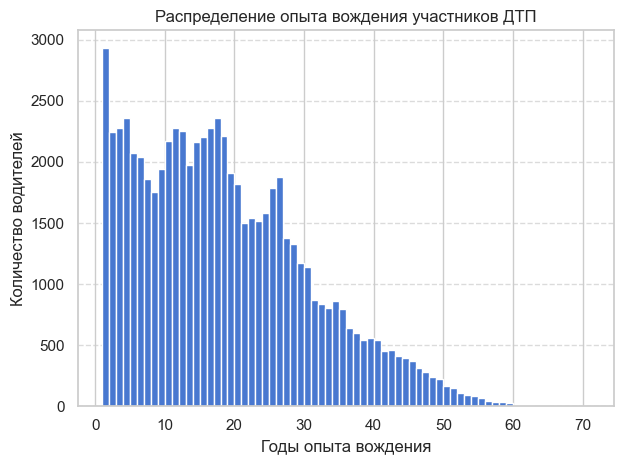

In [196]:
participants.loc[participants['role']=='Водитель', 'years_of_driving_experience'].hist(bins='auto')
plt.xlabel('Годы опыта вождения')
plt.ylabel('Количество водителей')
plt.title('Распределение опыта вождения участников ДТП')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

- Значительно выше количество ДТП у водителей на первом году вождения.
- Количество аварий падает на 7-9 ниже 2000 человек. Это может быть связано с общим снижением количества ДТП с 4-го года. Либо какими-то бюрократическими изменениями в получении прав в 2016-2018 годах.
- Водители со стажем 2 года и 18 лет одинаково часто попадают в ДТП.
- Снижение начинается с 20 лет, есть пик на 25-26 годах и дальнейшее снижение. Это может быть связано с фактически малым числом водителей с таким стажем.

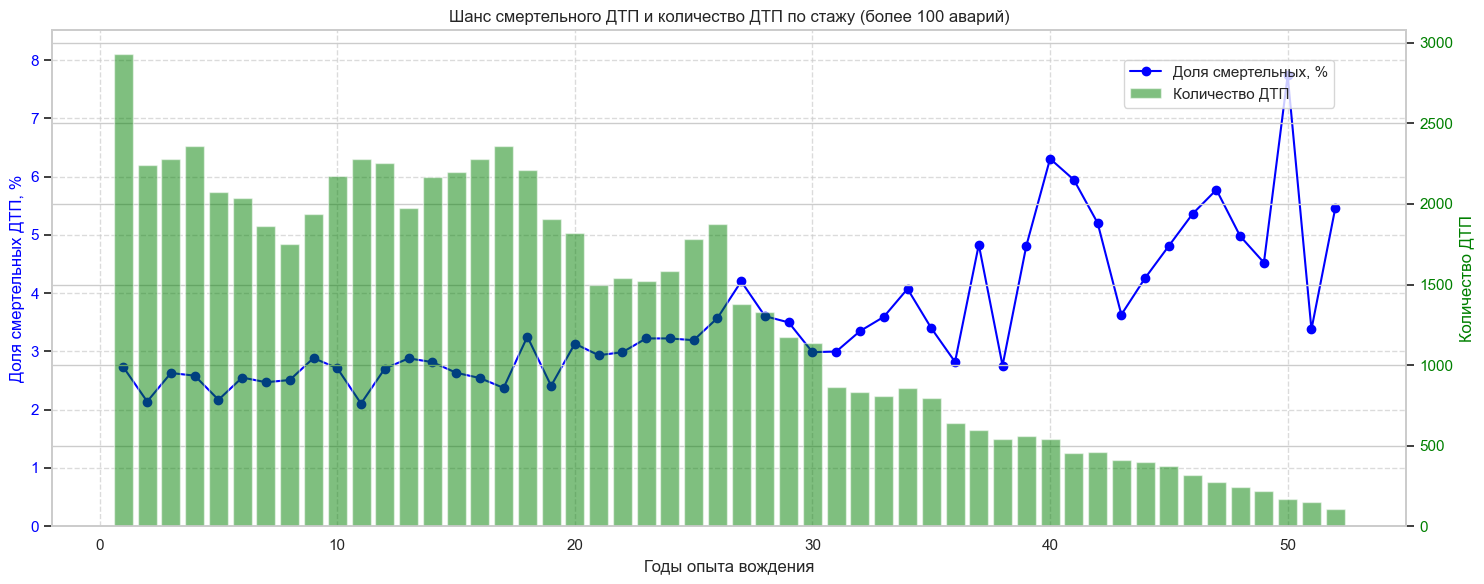

Корреляция стажа с количеством ДТП: -0.96
Корреляция стажа с долей смертельных: 0.78
Количество ДТП уменьшается со стажем (отрицательная корреляция).
Доля смертельных растёт со стажем (положительная корреляция).
Водители реже попадают в аварии, но чаще гибнут с увеличением стажа.


In [197]:
# Исходные данные
pivot = participants.pivot_table(
    index='years_of_driving_experience',
    columns='health_status',
    aggfunc='size',
    fill_value=0
).reset_index()
pivot.drop(columns=['S', 'M', 'N'], inplace=True)
pivot = (
    participants.loc[participants['role']=='Водитель', 'years_of_driving_experience']
    .value_counts().reset_index().sort_values(by='years_of_driving_experience', ascending=True)
    .reset_index(drop=True)
    .merge(pivot, on='years_of_driving_experience'))
pivot['p_F'] = pivot['F']/pivot['count']*100
threshold=100
filtered_pivot = pivot[pivot['count'] > threshold]

# Сортировка по стажу для анализа тенденций
filtered_pivot = filtered_pivot.sort_values(by='years_of_driving_experience')

# График с двумя осями: p_F (линия) и count (столбцы)
fig, ax1 = plt.subplots(figsize=(15, 6))

# Левая ось: доля смертельных (p_F, линия с маркерами)
ax1.plot(filtered_pivot['years_of_driving_experience'], filtered_pivot['p_F'], marker='o', color='blue', label='Доля смертельных, %')
ax1.set_xlabel('Годы опыта вождения')
ax1.set_ylabel('Доля смертельных ДТП, %', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_ylim(0, filtered_pivot['p_F'].max() * 1.1)

# Правая ось: количество ДТП (count, столбцы)
ax2 = ax1.twinx()
ax2.bar(filtered_pivot['years_of_driving_experience'], filtered_pivot['count'], alpha=0.5, color='green', label='Количество ДТП')
ax2.set_ylabel('Количество ДТП', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Заголовок и легенда
plt.title('Шанс смертельного ДТП и количество ДТП по стажу (более 100 аварий)')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.tight_layout()
plt.show()

# Анализ тенденций
# Корреляция стажа с количеством ДТП
count_corr = filtered_pivot['years_of_driving_experience'].corr(filtered_pivot['count'])
print(f"Корреляция стажа с количеством ДТП: {count_corr:.2f}")
# Корреляция стажа с долей смертельных
p_f_corr = filtered_pivot['years_of_driving_experience'].corr(filtered_pivot['p_F'])
print(f"Корреляция стажа с долей смертельных: {p_f_corr:.2f}")

# Выводы
print("Количество ДТП уменьшается со стажем (отрицательная корреляция).")
print("Доля смертельных растёт со стажем (положительная корреляция).")
print("Водители реже попадают в аварии, но чаще гибнут с увеличением стажа.")

Судя по графику, примерно с 20-30 лет стажа доля смертельных ДТП для водителей растёт. К 20-ти годам доля начинает превышать 3%.

Корреляция стажа с количеством ДТП = -0.96. Очень сильная отрицательная связь: чем больше стаж, тем меньше аварий на водителя. Возможные причины:
- Опытные водители лучше предвидят риски, реже нарушают ПДД.
- С возрастом люди ездят меньше (пенсия, здоровье), что снижает количество ДТП.
- Молодые водители (малый стаж) чаще рискуют (скорость, алкоголь).

Корреляция стажа с долей смертельных = 0.78. Сильная положительная связь: в авариях с опытными водителями чаще гибнут. Возможные причины:
- Возрастной фактор: старшие водители (большой стаж) физически уязвимее (хрупкие кости, хронические болезни).
- Тип аварий: опытные водители могут попадать в более серьёзные ДТП (трассы, высокие скорости).
- Статистический артефакт: аварий мало, доля смертельных может быть нестабильной (хотя threshold=100 фильтрует это).


### Окружение

In [198]:
nearby.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101256 entries, 1 to 51733
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   accident_id  101256 non-null  int64 
 1   nearby       101256 non-null  object
dtypes: int64(1), object(1)
memory usage: 2.3+ MB


In [199]:
nearby['nearby'].value_counts().reset_index()

,nearby,count
0,Многоквартирные дома,16677
1,Нерег. перекресток (неравн.),9326
2,Остановка общественного транспорта,8990
3,Частные дома,8501
4,Нерегулируемый пешеходный переход,8168
5,Регулируемый перекресток,7635
6,Адм. здания,6865
7,Регулируемый пешеходный переход,6734
8,Крупный ТЦ,4002
9,Выезд с прилегающей территории,3006


Доля смертельных исходов по местам аварий (не менее 100 случаев):


,nearby,total_cases,fatal_cases,fatal_share
29,Подход к мосту/эстакаде,370,32,8.65
30,Регулируемый ж/д переезд без дежурного,308,25,8.12
21,Нерегулируемый ж/д переезд,158,10,6.33
15,Мост,1258,71,5.64
39,Торговля/кафе вне НП,798,44,5.51
45,"Эстакада, путепровод",1299,66,5.08
9,Иной объект,1457,73,5.01
22,Нерегулируемый перекрёсток,5923,275,4.64
37,Стройка,434,20,4.61
16,"Мост, эстакада, путепровод",1934,81,4.19



Доля смертельных исходов для роли Водитель (не менее 100 случаев):


,nearby,total_cases,fatal_cases,fatal_share
28,Регулируемый ж/д переезд без дежурного,201,19,9.45
27,Подход к мосту/эстакаде,243,17,7.00
14,Мост,824,39,4.73
37,Торговля/кафе вне НП,536,22,4.10
8,Иной объект,943,35,3.71
43,"Эстакада, путепровод",903,33,3.65
29,Регулируемый ж/д переезд с дежурным,115,4,3.48
21,Нерегулируемый перекрёсток,3640,122,3.35
20,Нерегулируемый ж/д переезд,102,3,2.94
15,"Мост, эстакада, путепровод",1274,37,2.90



Доля смертельных исходов для роли Пассажир (не менее 100 случаев):


,nearby,total_cases,fatal_cases,fatal_share
23,Подход к мосту/эстакаде,105,8,7.62
33,"Эстакада, путепровод",311,19,6.11
11,Мост,347,21,6.05
7,Иной объект,384,23,5.99
28,Торговля/кафе вне НП,182,10,5.49
14,Нерег. круговое,189,10,5.29
17,Нерегулируемый перекрёсток,1283,52,4.05
0,АЗС,1570,60,3.82
12,"Мост, эстакада, путепровод",583,21,3.60
5,Завод,594,21,3.54



Доля смертельных исходов для роли Пешеход (не менее 100 случаев):


,nearby,total_cases,fatal_cases,fatal_share
0,АЗС,388,62,15.98
5,Завод,251,32,12.75
24,Частные дома,2226,270,12.13
13,Нерегулируемый перекрёсток,874,88,10.07
7,Иной объект,110,11,10.00
9,Магазин,456,33,7.24
15,Остановка общественного транспорта,3344,240,7.18
11,Нерег. перекресток (неравн.),2022,143,7.07
2,Больница,380,24,6.32
14,Нерегулируемый пешеходный переход,4731,284,6.00


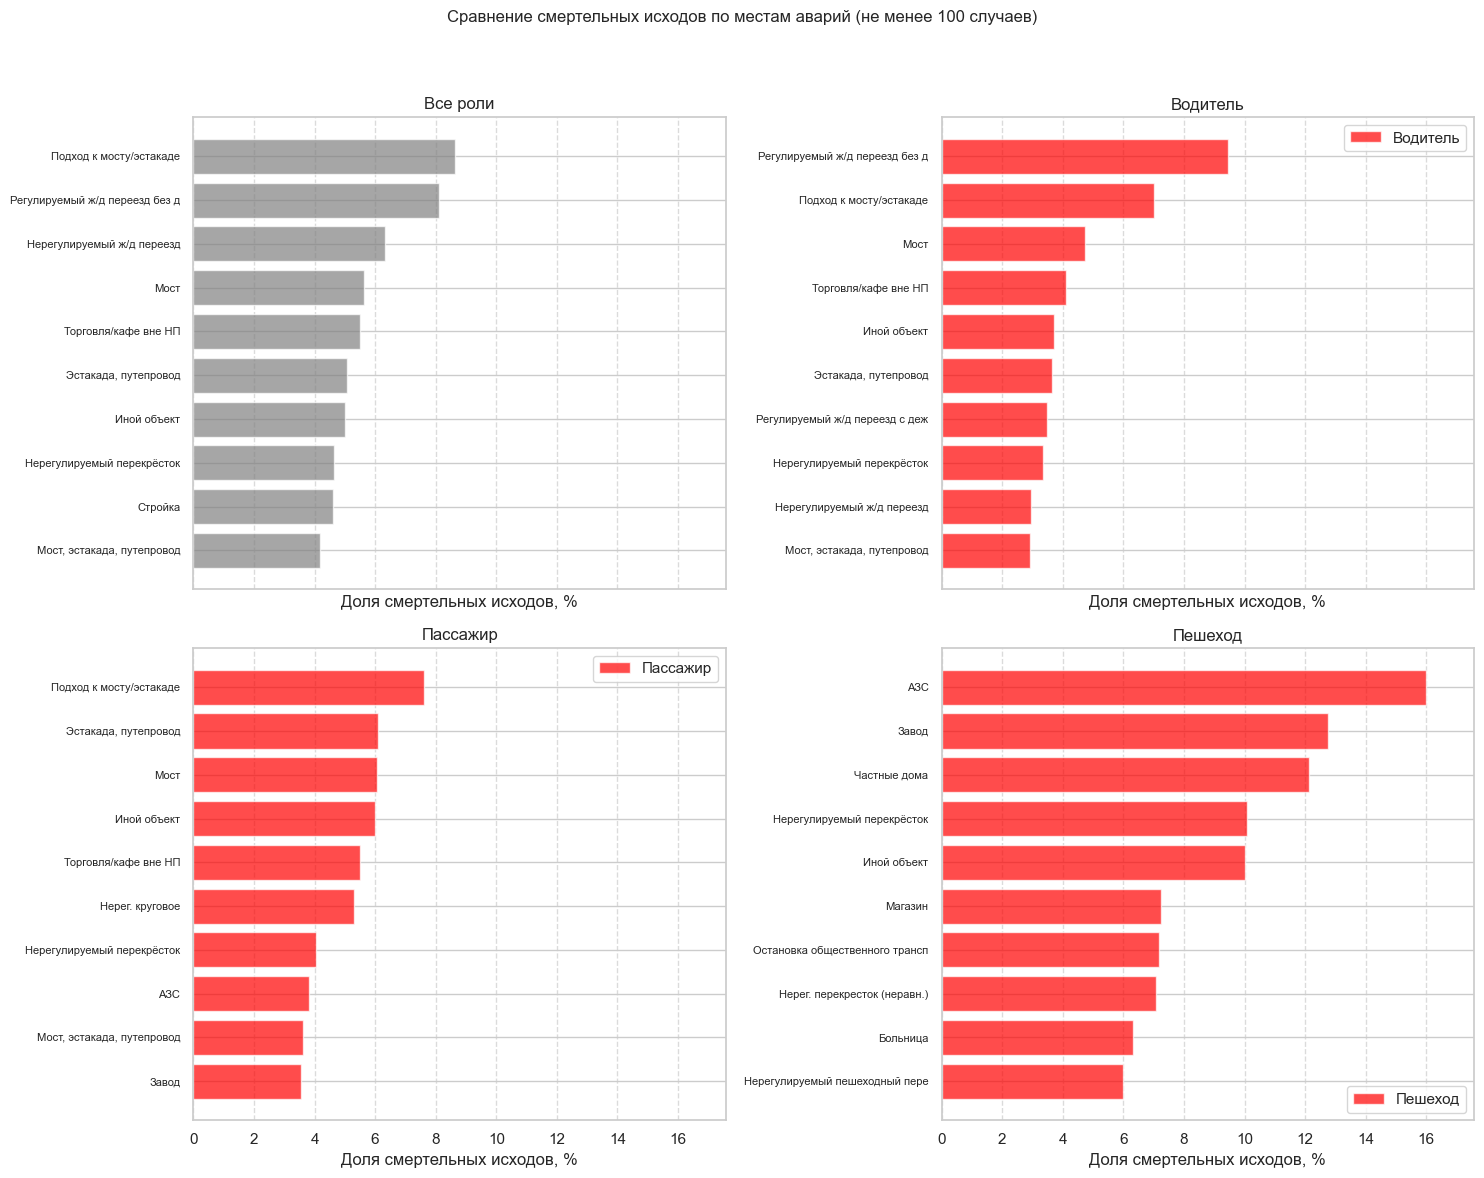

In [200]:
# Объединяем nearby с participants по accident_id
merged = participants.merge(nearby[['accident_id', 'nearby']], on='accident_id', how='left')

# Флаг для смертельных исходов
merged['is_fatal'] = merged['health_status'] == 'F'

# Фильтр по threshold >= 100 случаев для общей выборки
threshold = 100
nearby_counts = merged['nearby'].value_counts()
valid_nearby = nearby_counts[nearby_counts >= threshold].index
filtered_merged = merged[merged['nearby'].isin(valid_nearby)]

# Общая доля смертельных исходов по nearby
fatal_share = (filtered_merged.groupby('nearby')
               .agg(total_cases=('is_fatal', 'size'), fatal_cases=('is_fatal', 'sum'))
               .reset_index())
fatal_share['fatal_share'] = fatal_share['fatal_cases'] / fatal_share['total_cases'] * 100
fatal_share = fatal_share.sort_values(by='fatal_share', ascending=False)
print("Доля смертельных исходов по местам аварий (не менее 100 случаев):")
display(fatal_share)

# Доля смертельных исходов по ролям и местам с учётом threshold для каждой роли
roles = ['Водитель', 'Пассажир', 'Пешеход']
role_fatal_shares = {}
for role in roles:
    role_data = filtered_merged[filtered_merged['role'] == role]
    # Фильтр по threshold >= 100 для данной роли
    role_nearby_counts = role_data['nearby'].value_counts()
    valid_role_nearby = role_nearby_counts[role_nearby_counts >= threshold].index
    role_data = role_data[role_data['nearby'].isin(valid_role_nearby)]
    
    role_fatal_share = (role_data.groupby('nearby')
                        .agg(total_cases=('is_fatal', 'size'), fatal_cases=('is_fatal', 'sum'))
                        .reset_index())
    role_fatal_share['fatal_share'] = role_fatal_share['fatal_cases'] / role_fatal_share['total_cases'] * 100
    role_fatal_share = role_fatal_share.sort_values(by='fatal_share', ascending=False)
    role_fatal_shares[role] = role_fatal_share
    print(f"\nДоля смертельных исходов для роли {role} (не менее 100 случаев):")
    display(role_fatal_share)

# Создаём сетку 2x2 для графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True)

# Общий график (все роли) на axes[0, 0]
ax = axes[0, 0]
general_share = fatal_share.head(10)  # Топ-10 мест по общей смертности
labels = [idx[:30] for idx in general_share['nearby']]  # Укорачиваем подписи
ax.barh(labels[::-1], general_share['fatal_share'][::-1], alpha=0.7, color='gray')
ax.set_title('Все роли')
ax.set_xlabel('Доля смертельных исходов, %')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.tick_params(axis='y', labelsize=8)  # Уменьшенный шрифт подписей
ax.set_xlim(0, max(general_share['fatal_share'].max(), 10))  # Устанавливаем лимит по X

# Графики для каждой роли
for idx, role in enumerate(roles):
    # Правильная индексация: idx=0 -> axes[0, 1], idx=1 -> axes[1, 0], idx=2 -> axes[1, 1]
    ax = axes[0, 1] if idx == 0 else axes[1, idx-1]
    role_data = filtered_merged[filtered_merged['role'] == role]
    # Применяем threshold для графика
    role_nearby_counts = role_data['nearby'].value_counts()
    valid_role_nearby = role_nearby_counts[role_nearby_counts >= threshold].index
    role_data = role_data[role_data['nearby'].isin(valid_role_nearby)]
    
    role_fatal_share = role_data.groupby('nearby')['is_fatal'].mean() * 100
    role_fatal_share = role_fatal_share.sort_values(ascending=False).head(10)  # Топ-10 по убыванию
    labels = [idx[:30] for idx in role_fatal_share.index]  # Укорачиваем подписи
    ax.barh(labels[::-1], role_fatal_share.values[::-1], alpha=0.7, label=role, color='red')
    ax.set_title(f'{role}')
    ax.set_xlabel('Доля смертельных исходов, %')
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.tick_params(axis='y', labelsize=8)  # Уменьшенный шрифт подписей
    ax.set_xlim(0, max(role_fatal_share.max(), 10)*1.1)  # Устанавливаем лимит по X
    ax.legend()

# Настраиваем общий layout
plt.suptitle('Сравнение смертельных исходов по местам аварий (не менее 100 случаев)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Оставляем место для заголовка
plt.show()

- Водителям нужно быть аккуратнее на мостах, эстакадах, на ж/д переездах.
- Пассажиры также, видимо, потому что они не контролируют движение ТС, поэтому идут вслед за водителем.
- Пешеходы умирают в ДТП на АЗС, внутри производственных предприятий, во дворах и неконтролируемых перекрестках. Видимо, из-за того, что нет строгого контроля за этими зонами, светофора на переходе, камер внутри застройки и т.д.

Мы не можем прямо в лоб использовать эти данные, так как nearby указывается в совокупности нескольких объектов. Но понимать общую ситуацию это не мешает.

### Состояние дороги

In [201]:
# просмотрим информацию о датасете
road_conditions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74667 entries, 0 to 51733
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   accident_id      74667 non-null  int64 
 1   road_conditions  74667 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.7+ MB


In [202]:
# посмотрим, какие есть значения
road_conditions['road_conditions'].value_counts()

road_conditions
Сухое                                  34546
Плохая горизонтальная разметка         11142
Мокрое                                  9320
Обработано антигололедом                4060
Нет дорожных знаков                     2235
Заснеженное                             2085
Плохое зимнее содержание                1901
Плохая видимость знаков                 1279
Иные недостатки                         1208
Нет тротуаров                            978
Снежный накат                            953
Нет освещения                            728
Дефекты покрытия                         609
Плохие обочины                           512
Нет пешеходных ограждений                481
Гололедица                               437
Неровное покрытие                        387
Неисправное освещение                    298
Плохая вертикальная разметка             252
Недостаточное освещение                  159
Загрязненное                             141
Нет обустройства остановок             

Доля смертельных исходов по дорожным условиям (не менее 100 случаев):


,road_conditions,total_cases,fatal_cases,fatal_share
15,Нет направляющих устройств,137,26,18.98
12,Нет временных ТСОД,187,24,12.83
7,Недостаточное освещение,365,37,10.14
25,Плохие обочины,1272,127,9.98
17,Нет освещения,1658,165,9.95
14,Нет дорожных ограждений,296,29,9.80
8,Неисправное освещение,731,65,8.89
11,Несоответствие ограждений,208,17,8.17
19,Нет тротуаров,2203,147,6.67
10,Неровное покрытие,1016,67,6.59



Доля смертельных исходов для роли Водитель (не менее 100 случаев):


,road_conditions,total_cases,fatal_cases,fatal_share
11,Нет временных ТСОД,116,11,9.48
13,Нет дорожных ограждений,181,17,9.39
10,Несоответствие ограждений,122,10,8.20
22,Плохие обочины,793,64,8.07
15,Нет освещения,1008,47,4.66
6,Недостаточное освещение,202,9,4.46
1,Дефекты покрытия,927,34,3.67
9,Неровное покрытие,658,24,3.65
26,Сухое,53712,1876,3.49
4,Иные недостатки,1780,62,3.48



Доля смертельных исходов для роли Пассажир (не менее 100 случаев):


,road_conditions,total_cases,fatal_cases,fatal_share
15,Плохие обочины,388,46,11.86
6,Неровное покрытие,242,24,9.92
8,Нет освещения,323,22,6.81
1,Дефекты покрытия,315,20,6.35
0,Гололедица,384,22,5.73
3,Иные недостатки,523,29,5.54
5,Неисправное освещение,163,8,4.91
18,Сухое,18488,901,4.87
4,Мокрое,5345,259,4.85
11,Обработано антигололедом,3115,146,4.69



Доля смертельных исходов для роли Пешеход (не менее 100 случаев):


,road_conditions,total_cases,fatal_cases,fatal_share
4,Неисправное освещение,134,42,31.34
7,Нет освещения,291,86,29.55
9,Нет тротуаров,425,87,20.47
5,Неровное покрытие,111,18,16.22
0,Дефекты покрытия,158,17,10.76
10,Обработано антигололедом,986,101,10.24
8,Нет пешеходных ограждений,210,21,10.00
13,Плохое зимнее содержание,676,58,8.58
15,Сухое,8621,723,8.39
3,Мокрое,3054,256,8.38


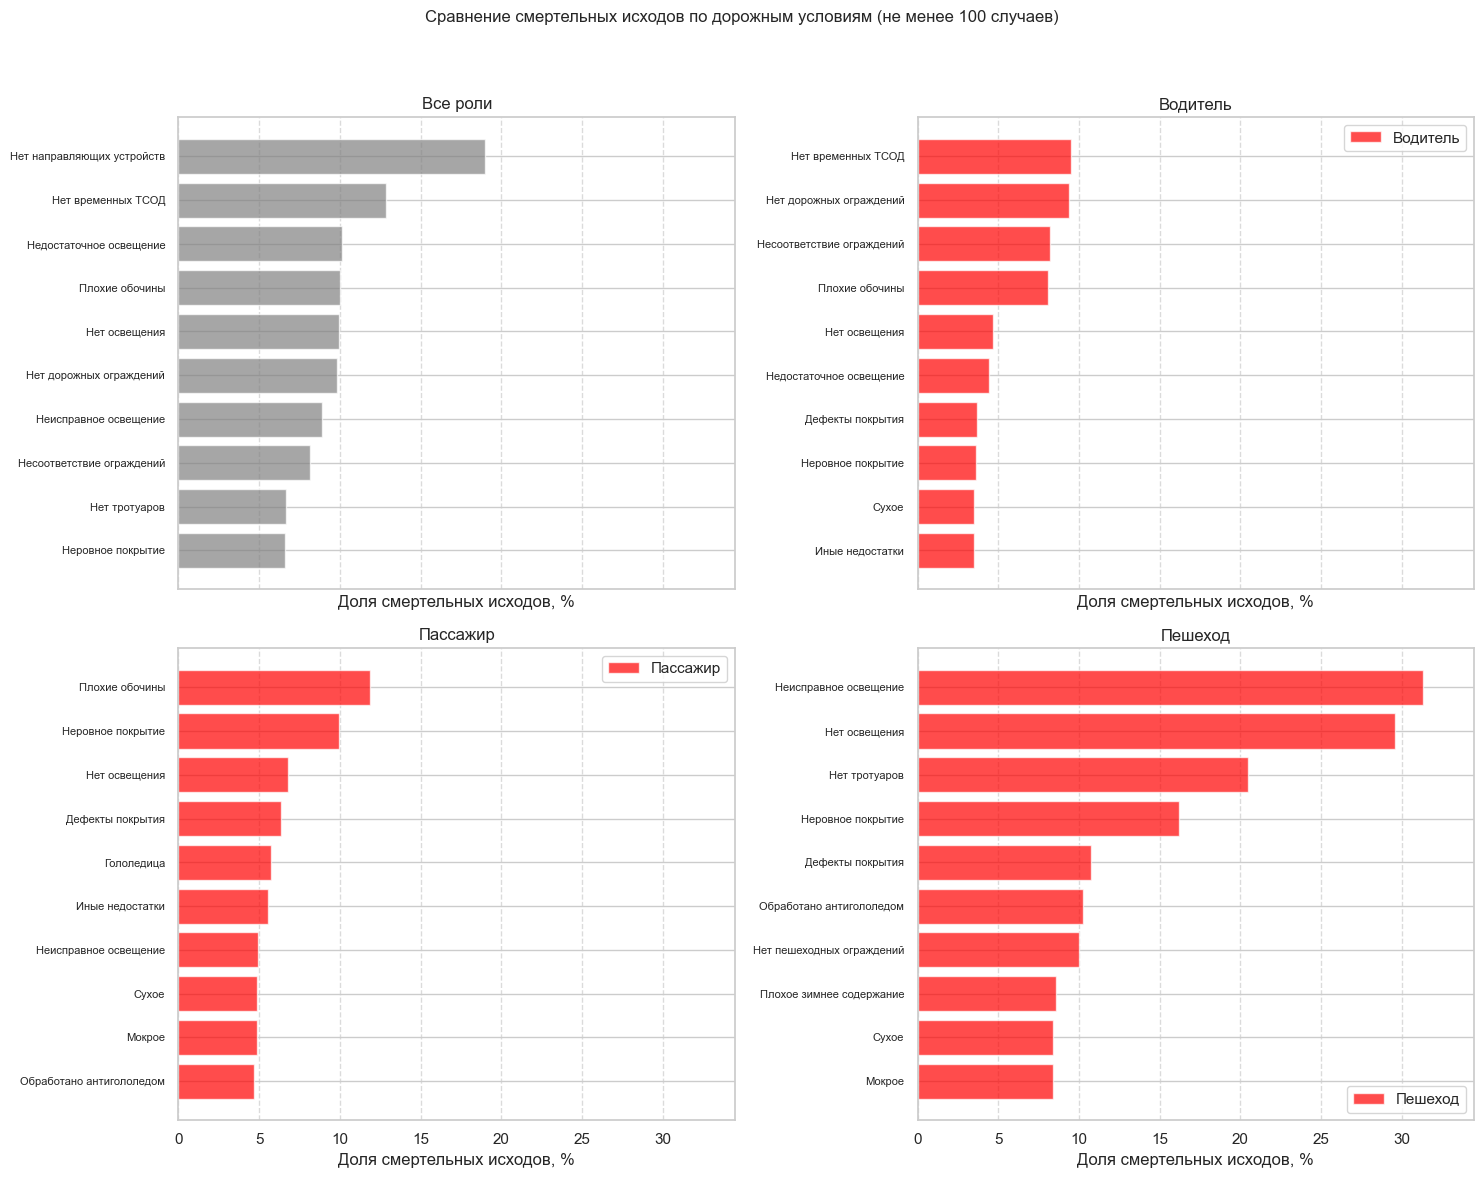

In [203]:
# Объединяем participants с road_conditions по accident_id
merged = participants.merge(road_conditions[['accident_id', 'road_conditions']], on='accident_id', how='left')

# Флаг для смертельных исходов
merged['is_fatal'] = merged['health_status'] == 'F'

# Фильтр по threshold >= 100 случаев для общей выборки
threshold = 100
conditions_counts = merged['road_conditions'].value_counts()
valid_conditions = conditions_counts[conditions_counts >= threshold].index
filtered_merged = merged[merged['road_conditions'].isin(valid_conditions)]

# Общая доля смертельных исходов по road_conditions
fatal_share = (filtered_merged.groupby('road_conditions')
               .agg(total_cases=('is_fatal', 'size'), fatal_cases=('is_fatal', 'sum'))
               .reset_index())
fatal_share['fatal_share'] = fatal_share['fatal_cases'] / fatal_share['total_cases'] * 100
fatal_share = fatal_share.sort_values(by='fatal_share', ascending=False)
print("Доля смертельных исходов по дорожным условиям (не менее 100 случаев):")
display(fatal_share)

# Доля смертельных исходов по ролям и условиям с учётом threshold
roles = ['Водитель', 'Пассажир', 'Пешеход']
role_fatal_shares = {}
for role in roles:
    role_data = filtered_merged[filtered_merged['role'] == role]
    # Фильтр по threshold >= 100 для данной роли
    role_conditions_counts = role_data['road_conditions'].value_counts()
    valid_role_conditions = role_conditions_counts[role_conditions_counts >= threshold].index
    role_data = role_data[role_data['road_conditions'].isin(valid_role_conditions)]
    
    role_fatal_share = (role_data.groupby('road_conditions')
                        .agg(total_cases=('is_fatal', 'size'), fatal_cases=('is_fatal', 'sum'))
                        .reset_index())
    role_fatal_share['fatal_share'] = role_fatal_share['fatal_cases'] / role_fatal_share['total_cases'] * 100
    role_fatal_share = role_fatal_share.sort_values(by='fatal_share', ascending=False)
    role_fatal_shares[role] = role_fatal_share
    print(f"\nДоля смертельных исходов для роли {role} (не менее 100 случаев):")
    display(role_fatal_share)

# Создаём сетку 2x2 для графиков
fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True)

# Общий график (все роли) на axes[0, 0]
ax = axes[0, 0]
general_share = fatal_share.head(10)  # Топ-10 условий по общей смертности
labels = [idx[:30] for idx in general_share['road_conditions']]  # Укорачиваем подписи
ax.barh(labels[::-1], general_share['fatal_share'][::-1], alpha=0.7, color='gray')
ax.set_title('Все роли')
ax.set_xlabel('Доля смертельных исходов, %')
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.tick_params(axis='y', labelsize=8)  # Уменьшенный шрифт подписей
ax.set_xlim(0, max(general_share['fatal_share'].max(), 10))  # Устанавливаем лимит по X

# Графики для каждой роли
for idx, role in enumerate(roles):
    # Индексация: idx=0 -> axes[0, 1], idx=1 -> axes[1, 0], idx=2 -> axes[1, 1]
    ax = axes[0, 1] if idx == 0 else axes[1, idx-1]
    role_data = filtered_merged[filtered_merged['role'] == role]
    # Применяем threshold для графика
    role_conditions_counts = role_data['road_conditions'].value_counts()
    valid_role_conditions = role_conditions_counts[role_conditions_counts >= threshold].index
    role_data = role_data[role_data['road_conditions'].isin(valid_role_conditions)]
    
    role_fatal_share = role_data.groupby('road_conditions')['is_fatal'].mean() * 100
    role_fatal_share = role_fatal_share.sort_values(ascending=False).head(10)  # Топ-10 по убыванию
    labels = [idx[:30] for idx in role_fatal_share.index]  # Укорачиваем подписи
    ax.barh(labels[::-1], role_fatal_share.values[::-1], alpha=0.7, label=role, color='red')
    ax.set_title(f'{role}')
    ax.set_xlabel('Доля смертельных исходов, %')
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.tick_params(axis='y', labelsize=8)  # Уменьшенный шрифт подписей
    ax.set_xlim(0, max(role_fatal_share.max(), 10)*1.1)  # Устанавливаем лимит по X
    ax.legend()

# Настраиваем общий layout
plt.suptitle('Сравнение смертельных исходов по дорожным условиям (не менее 100 случаев)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Оставляем место для заголовка
plt.show()

- Пассажир и водитель едут в одном автомобиле, но почему-то неровное покрытие и плохие обочины намного опаснее для пассажиров.
- Водителям следует быть аккуратнее на дорогах без ограждений и с плохими обочинами. Машина не воробей, вылетит - не поймаешь, как говорится.
- Езда без освещения - опаснее для пешеходов, чем для водителей и пассажиров. Пешеходы в таких ДТП гибнут в 30% случаев.
- Если нет освещения, тротуаров, плохая обочина, сама дорога с дефектами - пешеходам лучше там ночью не ходить.

### Выводы по разделу:

- **Время суток и освещение**  
  - Большинство ДТП происходит в светлое время суток или ночью при освещении.  
  - В темное время без освещения смертельные случаи происходят в 3 раза чаще, чем ночью со светом (11–12% против 3.79%).  
  - Ночные ДТП при освещении и дневные имеют одинаковую долю смертельных случаев.  

- **Регионы и города**  
  - Лидеры по числу ДТП: Москва и Краснодарский край, затем Челябинская, Московская и Самарская области.  
  - В городах: Омск, Новосибирск и Челябинск в топе.  
  - Меньше всего ДТП — Чукотский и Ненецкий АО (мало дорог и авто).  
  - В пересчете на 100 км дорог лидируют Москва и Санкт-Петербург (>20 ДТП).  

- **Типы происшествий**  
  - 44% ДТП — столкновения между авто.  
  - Каждое 4-е — наезд на пешехода.  
  - Каждое 9-е — съезд с дороги.  
  - Наезд на посторонних лиц и возгорания — наиболее опасные категории по смертности.  

- **Сезонность и время недели**  
  - Зимой и весной ДТП меньше, минимум в феврале.  
  - С мая по июнь рост аварий на 25%.  
  - Понедельник и пятница самые аварийные дни, воскресенье — самый спокойный.  

- **Время суток**  
  - Минимум аварий с 23:00 до 06:00.  
  - Пик в 07–08 утра.  
  - Серьезные ДТП чаще ночью: 55% тяжелых и смертельных против 35–40% в среднем.  

- **Тяжесть последствий**  
  - Каждая 11-я авария заканчивается смертью.  
  - 60% ДТП без тяжкого вреда здоровью.  
  - Наезд на пешехода и столкновения дают 68% всех смертей.  

- **Количество участников**  
  - В среднем 2–3 человека.  
  - Крупные аварии (0.1%) чаще днем, 36% со смертельными исходами.  

- **Погода**  
  - Больше всего ДТП при ясной погоде, но она же наименее смертельная.  
  - Самые опасные условия — туман (20% смертельных), метель (17%), дождь (12%).  

- **Транспортные средства**  
  - Основная масса — автомобили 2007–2020 годов выпуска.  
  - Чаще всего в ДТП попадают старые Honda и Toyota (~2006 г.в.).  
  - В тройке по доле ДТП: Honda, Toyota, Hyundai.  
  - По количеству ДТП: ГАЗ, Honda, Mercedes.  

- **Риски по маркам и моделям**  
  - Наиболее опасные: мотоциклы (почти 50% с тяжелыми последствиями), ВАЗ, Honda, Renault, Mitsubishi.  
  - Модели с высоким риском (20–35%): ВАЗ-2107, 2110, 2114, Priora, Logan, Kalina, Nexia (29%), Accent (24%), Sandero, Almera, Corolla.  
  - Более безопасные: Vesta, Solaris, Rio, Focus.  

- **Участники ДТП**  
  - В основном водители; пассажиры в 3 раза реже, пешеходы — в 6 раз реже.  
  - 69% участников — мужчины. Женщины чаще как пешеходы и пассажиры.  
  - Мужчины чаще выходят из легких ДТП без последствий, женщины чаще получают мелкие травмы.  

- **Нарушения**  
  - Половина участников ДТП не нарушала правила.  
  - Среди погибших пассажиры чаще не имели нарушений.  
  - Опасные нарушения: пьяные пешеходы, нахождение на проезжей части без цели перехода, отсутствие светоотражающих элементов, выезд на встречку, пьянство и отсутствие прав у водителей.  

- **Стаж вождения**  
  - Максимум аварий у водителей в первый год после получения прав. Чем больше стаж, тем меньше аварий на водителя
  - Стаж 20+ лет связан с ростом смертности в ДТП (замедленные реакции, сложное восстановление организма).  

- **Места повышенного риска**  
  - Водители — мосты, эстакады, ж/д переезды.  
  - Пешеходы — дворы, АЗС, производственные территории, неконтролируемые перекрестки.  


## Проверка гипотез

### Гипотеза 1. Пьяные водители имеют больше шансов выжить в ДТП

Я в своей жизни не раз сталкивался с утверждением ***"А был бы трезвый, погиб бы..."*** про ДТП.

Проверим гипотезу для водителей, попавших в ДТП из-за нарушения:
- H0: различий между пьяными и трезвыми водителями нет;
- H1: пьяные водители реже умирают в ДТП.

Соберем два датасета:
- водители с нарушениями, у которых есть пьяное вождение.
- водители с нарушениями, у которых нет нарушения за алкоголь.

Уберем людей, пересекающихся по ДТП.
Сравним их health_status.

Таблица сопряжённости:


,Смертельное,Несмертельное
Пьяные,310,2531
Трезвые,1894,50501


Хи-квадрат: 372.64, p-значение: 0.0000, степени свободы: 1
Ожидаемые значения:


,Смертельное,Несмертельное
Пьяные,113.36,2727.64
Трезвые,2090.64,50304.36


H0 отвергается: есть значимые различия в доле смертельных исходов.
Доля смертельных ДТП (пьяные): 10.91%
Доля смертельных ДТП (трезвые): 3.61%
H1 не подтверждается: пьяные водители не реже умирают в ДТП.


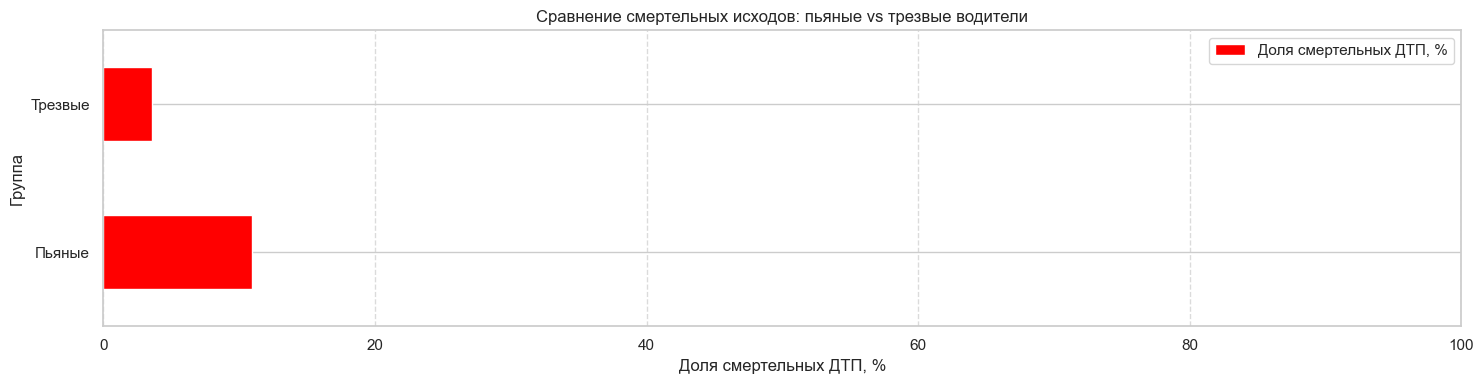

In [204]:
# Фильтр водителей с нарушениями
mask = (participants['role'] == 'Водитель') & (participants['violation_flag'] == 'Есть нарушение')
gilty_drivers = participants[mask].copy()

# Флаг для пьяных водителей
gilty_drivers['is_drunk'] = gilty_drivers['violations'].apply(
    lambda x: 'Водитель пьян' in x if isinstance(x, list) else False
)

# Разделяем на пьяных и трезвых
drunk_drivers = gilty_drivers[gilty_drivers['is_drunk']]
sober_drivers = gilty_drivers[~gilty_drivers['is_drunk']]

# Исключаем пересечения по accident_id
common_accidents = set(drunk_drivers['accident_id']).intersection(set(sober_drivers['accident_id']))
drunk_drivers = drunk_drivers[~drunk_drivers['accident_id'].isin(common_accidents)]
sober_drivers = sober_drivers[~sober_drivers['accident_id'].isin(common_accidents)]

# Флаг для смертельного исхода
drunk_drivers['is_fatal'] = drunk_drivers['health_status'] == 'F'
sober_drivers['is_fatal'] = sober_drivers['health_status'] == 'F'

alpha = 0.05

# Таблица сопряжённости
contingency_table = pd.DataFrame({
    'Смертельное': [
        drunk_drivers['is_fatal'].sum(),
        sober_drivers['is_fatal'].sum()
    ],
    'Несмертельное': [
        (~drunk_drivers['is_fatal']).sum(),
        (~sober_drivers['is_fatal']).sum()
    ]
}, index=['Пьяные', 'Трезвые'])
print("Таблица сопряжённости:")
display(contingency_table)

# Тест хи-квадрат
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Хи-квадрат: {chi2:.2f}, p-значение: {p:.4f}, степени свободы: {dof}")
print("Ожидаемые значения:")
display(pd.DataFrame(expected, index=['Пьяные', 'Трезвые'], columns=['Смертельное', 'Несмертельное']))

# Интерпретация
if p < alpha:
    print("H0 отвергается: есть значимые различия в доле смертельных исходов.")
    drunk_fatal_share = drunk_drivers['is_fatal'].mean() * 100
    sober_fatal_share = sober_drivers['is_fatal'].mean() * 100
    print(f"Доля смертельных ДТП (пьяные): {drunk_fatal_share:.2f}%")
    print(f"Доля смертельных ДТП (трезвые): {sober_fatal_share:.2f}%")
    if drunk_fatal_share < sober_fatal_share:
        print("H1 подтверждается: пьяные водители реже умирают в ДТП.")
    else:
        print("H1 не подтверждается: пьяные водители не реже умирают в ДТП.")
else:
    print("H0 не отвергается: нет значимых различий в доле смертельных исходов.")

# График
pivot = pd.DataFrame({
    'Группа': ['Пьяные', 'Трезвые'],
    'Доля смертельных ДТП, %': [drunk_drivers['is_fatal'].mean() * 100, sober_drivers['is_fatal'].mean() * 100]
})
pivot.plot(kind='barh', x='Группа', y='Доля смертельных ДТП, %', figsize=(15, 4), xlim=(0, 100), color='red')
plt.xlabel('Доля смертельных ДТП, %')
plt.title('Сравнение смертельных исходов: пьяные vs трезвые водители')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Моя гипотеза не подтвердилась. Алкоголь не поможет выжить в ДТП.

### Гипотеза 2. Безопаснее быть пассажиром автобуса, чем легкового автомобиля

Сформулируем гипотезы:
- H0: Нет различий в доле смертельных или серьёзных травм (F или S) между пассажирами легковых автомобилей и автобусов.
- H1: Пассажиры автобусов реже получают травмы (F или S) по сравнению с пассажирами легковых автомобилей.

Таблица сопряжённости:


Травма,False,True
Тип транспорта,,
B,16495,6799
D,3233,588


Хи-квадрат: 314.65, p-значение: 0.0000, степени свободы: 1
Ожидаемые значения:


,Нет травм,Травма
B,16947.96,6346.04
D,2780.04,1040.96


H0 отвергается: есть значимые различия в доле травм.
Доля травм (легковые, B): 29.19%
Доля травм (автобусы, D): 15.39%
H1 подтверждается: пассажиры автобусов реже получают травмы.


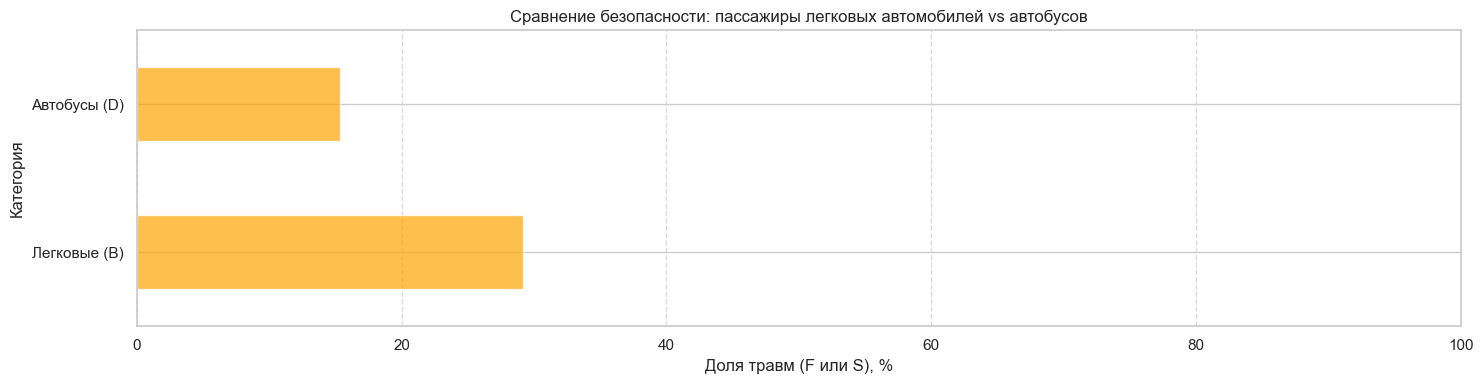

In [205]:
# Фильтруем пассажиров (только role == 'Пассажир')
passengers = participants[participants['role'] == 'Пассажир'].copy()

# Объединяем с vehicles для получения категории транспорта
passenger_vehicles = passengers.merge(vehicles[['vehicle_id', 'category']], on='vehicle_id', how='left')

# Фильтруем только легковые (B) и автобусы (D)
passenger_vehicles = passenger_vehicles[passenger_vehicles['category'].isin(['B', 'D'])]

# Флаг для травм (F или S)
passenger_vehicles['is_injured'] = passenger_vehicles['health_status'].isin(['F', 'S'])

# Таблица сопряжённости: тип транспорта vs травмы
contingency_table = pd.crosstab(passenger_vehicles['category'], passenger_vehicles['is_injured'], 
                                rownames=['Тип транспорта'], colnames=['Травма'])
print("Таблица сопряжённости:")
display(contingency_table)

# Тест хи-квадрат
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Хи-квадрат: {chi2:.2f}, p-значение: {p:.4f}, степени свободы: {dof}")
print("Ожидаемые значения:")
display(pd.DataFrame(expected, index=['B', 'D'], columns=['Нет травм', 'Травма']))

# Интерпретация
if p < alpha:
    print("H0 отвергается: есть значимые различия в доле травм.")
    car_injured_share = passenger_vehicles[passenger_vehicles['category'] == 'B']['is_injured'].mean() * 100
    bus_injured_share = passenger_vehicles[passenger_vehicles['category'] == 'D']['is_injured'].mean() * 100
    print(f"Доля травм (легковые, B): {car_injured_share:.2f}%")
    print(f"Доля травм (автобусы, D): {bus_injured_share:.2f}%")
    if bus_injured_share < car_injured_share:
        print("H1 подтверждается: пассажиры автобусов реже получают травмы.")
    else:
        print("H1 не подтверждается: пассажиры легковых автомобилей не в большей опасности.")
else:
    print("H0 не отвергается: нет значимых различий в доле травм.")

# График
pivot = passenger_vehicles.groupby('category')['is_injured'].mean() * 100
pivot = pivot.rename(index={'B': 'Легковые (B)', 'D': 'Автобусы (D)'})
pivot.plot(kind='barh', figsize=(15, 4), alpha=0.7, xlim=(0, 100), color='orange')
plt.xlabel('Доля травм (F или S), %')
plt.ylabel('Категория')
plt.title('Сравнение безопасности: пассажиры легковых автомобилей vs автобусов')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Мы подтвердили гипотезу - безопаснее ездить на автобусе.

### Гипотеза 3. Безопаснее быть водителем личного авто чем пассажиром автобуса.

Проверим гипотезу, что водители легковых автомобилей (category='B') реже получают смертельные (F) или серьёзные (S) травмы, чем пассажиры автобусов (category='D'). Используем тест хи-квадрат, данные из participants и vehicles, сравним health_status (F/S vs M/N).

Гипотезы:
- H0: Нет различий в доле смертельных или серьёзных травм (F или S) между водителями легковых автомобилей и пассажирами автобусов.
- H1: Водители легковых автомобилей реже получают травмы (F или S), чем пассажиры автобусов.

Таблица сопряжённости:


Травма,False,True
Группа,,
Водители легковых (B),52662,7728
Пассажиры автобусов (D),3233,588


Хи-квадрат: 21.18, p-значение: 0.0000, степени свободы: 1
Ожидаемые значения:



,Нет травм,Травма
Водители легковых (B),52568.86,7821.14
Пассажиры автобусов (D),3326.14,494.86


H0 отвергается: есть значимые различия в доле травм.
Доля травм (водители легковых, B): 12.80%
Доля травм (пассажиры автобусов, D): 15.39%
H1 подтверждается: водители легковых автомобилей реже получают травмы.


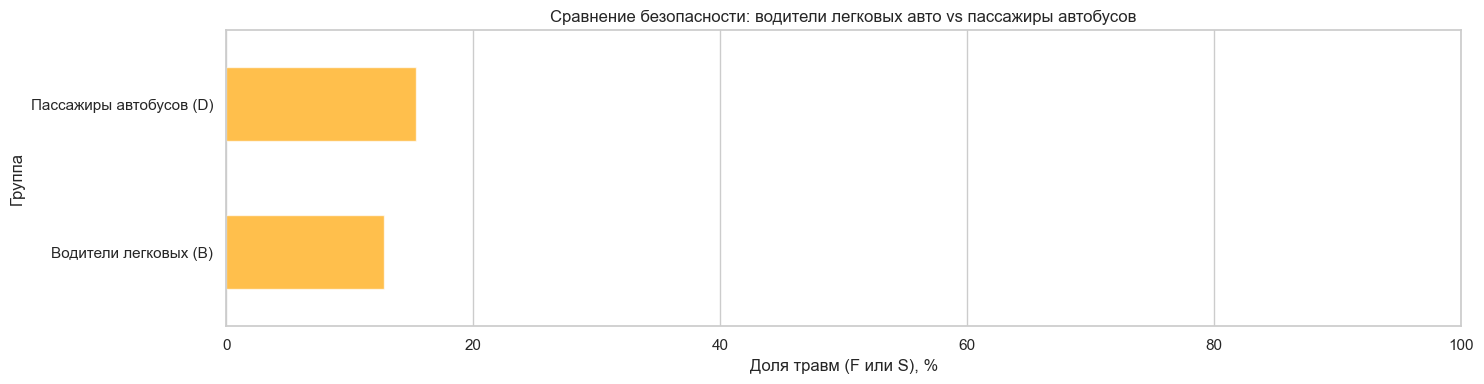

In [206]:
# Фильтруем водителей легковых автомобилей (B) и пассажиров автобусов (D)
drivers = participants[participants['role'] == 'Водитель'].copy()
passengers = participants[participants['role'] == 'Пассажир'].copy()

# Объединяем с vehicles для получения категории транспорта
drivers_vehicles = drivers.merge(vehicles[['vehicle_id', 'category']], on='vehicle_id', how='left')
passengers_vehicles = passengers.merge(vehicles[['vehicle_id', 'category']], on='vehicle_id', how='left')

# Фильтруем: водители только B, пассажиры только D
drivers_b = drivers_vehicles[drivers_vehicles['category'] == 'B'].copy()
passengers_d = passengers_vehicles[passengers_vehicles['category'] == 'D'].copy()

# Создаём флаг для травм (F или S)
drivers_b['is_injured'] = drivers_b['health_status'].isin(['F', 'S'])
passengers_d['is_injured'] = passengers_d['health_status'].isin(['F', 'S'])

# Объединяем данные для анализа
drivers_b['group'] = 'Водители легковых (B)'
passengers_d['group'] = 'Пассажиры автобусов (D)'
combined = pd.concat([drivers_b[['group', 'is_injured']], passengers_d[['group', 'is_injured']]])

# Таблица сопряжённости
contingency_table = pd.crosstab(combined['group'], combined['is_injured'], 
                                rownames=['Группа'], colnames=['Травма'])
print("Таблица сопряжённости:")
display(contingency_table)

# Тест хи-квадрат
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Хи-квадрат: {chi2:.2f}, p-значение: {p:.4f}, степени свободы: {dof}")
print("Ожидаемые значения:\n")
display(pd.DataFrame(expected, index=['Водители легковых (B)', 'Пассажиры автобусов (D)'], columns=['Нет травм', 'Травма']))

# Интерпретация
if p < alpha:
    print("H0 отвергается: есть значимые различия в доле травм.")
    driver_injured_share = drivers_b['is_injured'].mean() * 100
    passenger_injured_share = passengers_d['is_injured'].mean() * 100
    print(f"Доля травм (водители легковых, B): {driver_injured_share:.2f}%")
    print(f"Доля травм (пассажиры автобусов, D): {passenger_injured_share:.2f}%")
    if driver_injured_share < passenger_injured_share:
        print("H1 подтверждается: водители легковых автомобилей реже получают травмы.")
    else:
        print("H1 не подтверждается: пассажиры автобусов не опаснее.")
else:
    print("H0 не отвергается: нет значимых различий в доле травм.")

# График
pivot = combined.groupby('group')['is_injured'].mean() * 100
pivot.plot(kind='barh', figsize=(15, 4), color='orange', alpha=0.7, xlim=(0, 100))
plt.xlabel('Доля травм (F или S), %')
plt.ylabel('Группа')
plt.title('Сравнение безопасности: водители легковых авто vs пассажиры автобусов')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Безопаснее оказалось быть водителем собственного авто, если мы боимся умереть или попасть после ДТП в больницу.

Так как это неожиданный для меня исход, сравним только смертельные случаи.

### Гипотеза 4. Водители легковых автомобилей чаще погибают по сравнению с пассажирами автобусов.

Адаптируем код для проверки гипотезы, что водители легковых автомобилей (category='B') чаще погибают (health_status='F') по сравнению с пассажирами автобусов (category='D'). Используем тест хи-квадрат, данные из participants и vehicles, и сравниваем только смертельные исходы (F vs не-F).

Гипотезы:
- H0: Нет различий в доле смертельных исходов между водителями легковых автомобилей и пассажирами автобусов.
- H1: Водители легковых автомобилей чаще погибают по сравнению с пассажирами автобусов.

Таблица сопряжённости:


Смертельный исход,False,True
Группа,,
Водители легковых (B),58428,1962
Пассажиры автобусов (D),3777,44


Хи-квадрат: 51.54, p-значение: 0.0000, степени свободы: 1
Ожидаемые значения:


,Несмертельный,Смертельный
Водители легковых (B),58503.37,1886.63
Пассажиры автобусов (D),3701.63,119.37


H0 отвергается: есть значимые различия в доле смертельных исходов.
Доля смертельных исходов (водители легковых, B): 3.25%
Доля смертельных исходов (пассажиры автобусов, D): 1.15%
H1 подтверждается: водители легковых автомобилей чаще погибают.


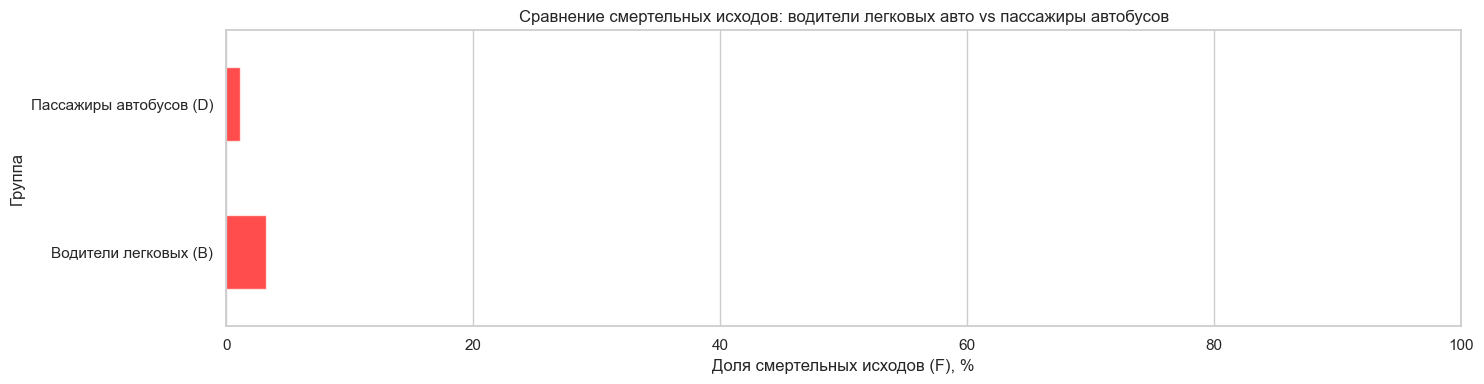

In [207]:
# Фильтруем водителей легковых автомобилей (B) и пассажиров автобусов (D)
drivers = participants[participants['role'] == 'Водитель'].copy()
passengers = participants[participants['role'] == 'Пассажир'].copy()

# Объединяем с vehicles для получения категории транспорта
drivers_vehicles = drivers.merge(vehicles[['vehicle_id', 'category']], on='vehicle_id', how='left')
passengers_vehicles = passengers.merge(vehicles[['vehicle_id', 'category']], on='vehicle_id', how='left')

# Фильтруем: водители только B, пассажиры только D
drivers_b = drivers_vehicles[drivers_vehicles['category'] == 'B'].copy()
passengers_d = passengers_vehicles[passengers_vehicles['category'] == 'D'].copy()

# Создаём флаг для смертельных исходов (только F)
drivers_b['is_fatal'] = drivers_b['health_status'] == 'F'
passengers_d['is_fatal'] = passengers_d['health_status'] == 'F'

# Объединяем данные для анализа
drivers_b['group'] = 'Водители легковых (B)'
passengers_d['group'] = 'Пассажиры автобусов (D)'
combined = pd.concat([drivers_b[['group', 'is_fatal']], passengers_d[['group', 'is_fatal']]])

# Таблица сопряжённости
contingency_table = pd.crosstab(combined['group'], combined['is_fatal'], 
                                rownames=['Группа'], colnames=['Смертельный исход'])
print("Таблица сопряжённости:")
display(contingency_table)

# Тест хи-квадрат
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Хи-квадрат: {chi2:.2f}, p-значение: {p:.4f}, степени свободы: {dof}")
print("Ожидаемые значения:")
display(pd.DataFrame(expected, index=['Водители легковых (B)', 'Пассажиры автобусов (D)'], columns=['Несмертельный', 'Смертельный']))

# Интерпретация
if p < alpha:
    print("H0 отвергается: есть значимые различия в доле смертельных исходов.")
    driver_fatal_share = drivers_b['is_fatal'].mean() * 100
    passenger_fatal_share = passengers_d['is_fatal'].mean() * 100
    print(f"Доля смертельных исходов (водители легковых, B): {driver_fatal_share:.2f}%")
    print(f"Доля смертельных исходов (пассажиры автобусов, D): {passenger_fatal_share:.2f}%")
    if driver_fatal_share > passenger_fatal_share:
        print("H1 подтверждается: водители легковых автомобилей чаще погибают.")
    else:
        print("H1 не подтверждается: пассажиры автобусов опаснее.")
else:
    print("H0 не отвергается: нет значимых различий в доле смертельных исходов.")

# График
pivot = combined.groupby('group')['is_fatal'].mean() * 100
pivot.plot(kind='barh', figsize=(15, 4), color='red', alpha=0.7, xlim=(0, 100))
plt.xlabel('Доля смертельных исходов (F), %')
plt.ylabel('Группа')
plt.title('Сравнение смертельных исходов: водители легковых авто vs пассажиры автобусов')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Теперь оказалось, что водители легковых автомобилей погибают в ДТП чаще, чем пассажиры автобусов.\
Хотя прошлая гипотеза говорила, что безопаснее на личном автомобиле.

Проверим доверительные интервалы, можно ли считать наши расчеты статистически достоверными.

In [208]:
# Доверительные интервалы
driver_fatal_count = drivers_b['is_fatal'].sum()
driver_total = len(drivers_b)
passenger_fatal_count = passengers_d['is_fatal'].sum()
passenger_total = len(passengers_d)
print("Размер выборки (водители B):", driver_total)
print("Размер выборки (пассажиры D):", passenger_total)
print("Доверительный интервал (водители B):", proportion_confint(driver_fatal_count, driver_total, alpha=0.05))
print("Доверительный интервал (пассажиры D):", proportion_confint(passenger_fatal_count, passenger_total, alpha=0.05))

# Влияние типа аварии
driver_accidents = drivers_b.merge(accidents[['accident_id', 'category']], on='accident_id', how='left')
passenger_accidents = passengers_d.merge(accidents[['accident_id', 'category']], on='accident_id', how='left')
print("\nДоля смертельных исходов по типу аварии (водители B):")
display(driver_accidents.groupby('category_y')['is_fatal'].mean() * 100)
print("Доля смертельных исходов по типу аварии (пассажиры D):")
display(passenger_accidents.groupby('category_y')['is_fatal'].mean() * 100)

Размер выборки (водители B): 60390
Размер выборки (пассажиры D): 3821
Доверительный интервал (водители B): (0.031074786352872478, 0.03390285895264168)
Доверительный интервал (пассажиры D): (0.00813246305611336, 0.014898157200364002)

Доля смертельных исходов по типу аварии (водители B):


category_y
Возгорание ТС                    12.50
Иной вид ДТП                      2.10
Наезд на велосипедиста            0.00
Наезд на внезапное препятствие    0.00
Наезд на животное                 9.84
Наезд на пешехода                 0.00
Наезд на препятствие              6.96
Наезд на прохожего                0.00
Наезд на рабочего                 0.00
Наезд на служащего                0.00
Наезд на стоящее ТС               3.51
Опрокидывание                    10.39
Отбрасывание предмета             6.06
Падение груза                     0.00
Падение пассажира                 0.00
Столкновение                      3.15
Съезд с дороги                    9.86
Name: is_fatal, dtype: float64

Доля смертельных исходов по типу аварии (пассажиры D):


category_y
Иной вид ДТП             0.00
Наезд на велосипедиста   0.00
Наезд на пешехода        0.00
Наезд на препятствие     0.69
Наезд на стоящее ТС      5.79
Опрокидывание            0.00
Отбрасывание предмета    0.00
Падение пассажира        0.18
Столкновение             1.85
Съезд с дороги           0.72
Name: is_fatal, dtype: float64

Анализ результатов:
1. Размер выборки:
- Водители легковых (B): 60,390 — большая выборка, результаты надёжны.
- Пассажиры автобусов (D): 3,821 — меньше, но достаточно для теста хи-квадрат, если ожидаемые значения > 5 (у нас минимум - 119).

Доверительные интервалы:
- Водители B: 3.11%–3.39% (узкий интервал, высокая точность).
- Пассажиры D: 0.81%–1.49% (шире из-за меньшей выборки, но не пересекается с интервалом B).

Подтверждает значимость различий: пассажиры автобусов реже погибают.

Доля смертельных исходов по типу аварий (category_y):
- Водители B: Высокая смертность в категориях "Возгорание" (12.5%), "Опрокидывание" (10.39%), "Съезд с дороги" (9.86%), "Наезд на животное" (9.84%), "Наезд на препятствие" (6.96%). "Столкновение" — 3.15%, ниже среднего.
- Пассажиры D: Самая высокая смертность в "Наезд на стоящее ТС" (5.79%), "Столкновение" (1.85%), "Съезд с дороги" (0.72%), "Падение пассажира" (0.18%). Многие категории (например, "Опрокидывание", "Иной вид ДТП") имеют 0% смертность.

Вывод: Водители легковых чаще погибают в авариях с опрокидыванием, съездом с дороги и возгоранием, тогда как пассажиры автобусов — в наездах и столкновениях, но с меньшей смертностью. 

Гипотеза подтвердилась.

### Выводы по разделу:

- **Гипотеза 1. Алкоголь снижает риск смерти в ДТП**  
  Не подтвердилась.  
  - Доля смертельных исходов у пьяных водителей: **10.91%**  
  - У трезвых водителей: **3.61%**  
  → Пьяные водители **чаще** погибают.

- **Гипотеза 2. Безопаснее быть пассажиром автобуса, чем легкового автомобиля**  
  Подтвердилась.  
  - Травмы у пассажиров легковых (B): **29.19%**  
  - Травмы у пассажиров автобусов (D): **15.39%**  
  → Езда в автобусе статистически безопаснее.

- **Гипотеза 3. Безопаснее быть водителем легкового автомобиля, чем пассажиром автобуса**  
  Частично подтвердилась.  
  - Тяжёлые и смертельные травмы у водителей (B): **12.80%**  
  - У пассажиров автобусов (D): **15.39%**  
  → Водители реже получают тяжёлые травмы, но…

- **Гипотеза 4. Водители легковых автомобилей чаще погибают, чем пассажиры автобусов**  
  Подтвердилась.  
  - Смертность у водителей (B): **3.25%**  
  - Смертность у пассажиров автобусов (D): **1.15%**  
  → Водители легковых **чаще погибают**, несмотря на меньшую долю тяжёлых травм в целом.  

**Общий вывод:**  
- Алкоголь не спасает, а повышает риск смерти в ДТП.  
- Пассажирам автобусов безопаснее, чем пассажирам легковых.  
- Водители легковых реже получают травмы, но чаще погибают — особенно в ДТП с **опрокидыванием, съездом с дороги и возгоранием**.  

## Выводы и рекомендации

### Выводы

- Пьяные водители погибают чаще трезвых.  
- Пассажирам автобусов безопаснее, чем пассажирам легковых.  
- Водители легковых получают меньше травм, но умирают чаще.  
- Смертность в 3 раза выше ночью без освещения.  
- Москва и Краснодарский край лидируют по авариям, в пересчёте на дороги — Москва и Петербург.  
- Основные типы ДТП — столкновения (44%) и наезды на пешеходов (25%).  
- Лето и май–июнь — пик аварийности, понедельник и пятница опаснее других дней.  
- Ночью аварий меньше, но они тяжелее (55% серьёзных и смертельных).  
- Каждая 11-я авария заканчивается смертью.  
- Самые опасные условия — туман, метель и дождь.  
- В группе риска — мотоциклы и старые модели ВАЗ, Honda, Renault, Mitsubishi.  
- Чаще в авариях мужчины-водители; женщины чаще пострадавшие пассажиры и пешеходы.  
- Опасные нарушения: пьянство, выезд на встречку, отсутствие прав/светоотражателей.  
- Максимум аварий у новичков; высокая смертность у водителей со стажем 20+.  
- Опасные места: мосты, эстакады, ж/д переезды (для водителей); дворы и АЗС (для пешеходов).  

### Рекомендации

- Улучшать освещение трасс, особенно вне городов.
- Снижать аварийность в пиковые периоды: пятницы.
- Повышать оснащение легковых авто средствами пассивной безопасности.
- Особое внимание — начинающим водителям и группе 20+ лет стажа.
- Разрабатывать меры безопасности для мотоциклистов и пешеходов.